In [1]:
# # # Install missing libraries
# !pip install category_encoders
# !pip install plotly
# !pip install prophet
# !pip install pydot
# !pip install graphviz
# !pip install jinja2
# !pip install reportlab
# !pip install fpdf

In [ ]:
# -*- coding: utf-8 -*-
"""Enhanced Time Series Classification Pipeline with Model Evaluation Graphs"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (LSTM, Bidirectional, Dense, Dropout,
                                     Input, BatchNormalization, Attention,
                                     LayerNormalization, GRU, Conv1D,
                                     MaxPooling1D, GlobalAveragePooling1D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import plot_model
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                           r2_score, precision_score, recall_score,
                           f1_score, accuracy_score, confusion_matrix,
                           classification_report, roc_auc_score,
                           precision_recall_curve, roc_curve, auc)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import calibration_curve
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier, XGBRegressor
from prophet import Prophet
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
import category_encoders
import io
import contextlib
import os
import zipfile
import json
import base64
from io import BytesIO
from jinja2 import Template
from reportlab.lib.pagesizes import letter
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, Table, TableStyle
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib import colors
from fpdf import FPDF
import html

# ============================================
# HYPERPARAMETERS - TUNE THESE VALUES
# ============================================

# Data Preprocessing Parameters
ENCODE_CATEGORICAL = True
SCALE_NUMERIC = True
SCALER_TYPE = 'standard'
TARGET_ENCODING_THRESHOLD = 10  # Minimum samples for target encoding

# Feature Engineering Parameters
CREATE_DATE_FEATURES = True
CREATE_INTERACTION_FEATURES = True
CREATE_LAG_FEATURES = True
LAG_WINDOWS = [1, 3, 7]  # Days for lag features

# Deep Learning Hyperparameters
LSTM_UNITS = 128
BILSTM_UNITS = 64
GRU_UNITS = 64
CNN_FILTERS = [64, 128]
CNN_KERNEL_SIZE = 3
DENSE_UNITS = [64, 32, 16]
DROPOUT_RATE = 0.3
RECURRENT_DROPOUT = 0.2
LEARNING_RATE = 0.001
BATCH_SIZE = 32
EPOCHS = 100
PATIENCE = 15
VALIDATION_SPLIT = 0.2
TIME_STEPS = 7
TEST_SIZE = 0.15

# Prophet Hyperparameters - UPDATED FOR BETTER RESULTS
PROPHET_GROWTH = 'linear'
PROPHET_SEASONALITY_MODE = 'additive'  # Changed from 'multiplicative'
PROPHET_YEARLY_SEASONALITY = 'auto'
PROPHET_WEEKLY_SEASONALITY = True
PROPHET_DAILY_SEASONALITY = False
PROPHET_SEASONALITY_PRIOR_SCALE = 10.0  # Added
PROPHET_CHANGE_POINT_PRIOR_SCALE = 0.05  # Added
PROPHET_HOLIDAYS_PRIOR_SCALE = 10.0  # Added
PROPHET_MCMC_SAMPLES = 0  # Added

# Prophet Hyperparameters - SIMPLIFIED FOR STABILITY
PROPHET_GROWTH = 'linear'
PROPHET_SEASONALITY_MODE = 'additive'
PROPHET_YEARLY_SEASONALITY = False  # Simplified
PROPHET_WEEKLY_SEASONALITY = False  # Simplified
PROPHET_DAILY_SEASONALITY = False
PROPHET_SEASONALITY_PRIOR_SCALE = 1.0  # Reduced from 10.0
PROPHET_CHANGE_POINT_PRIOR_SCALE = 0.01  # Reduced from 0.05
PROPHET_HOLIDAYS_PRIOR_SCALE = 1.0  # Reduced from 10.0
PROPHET_MCMC_SAMPLES = 0

# XGBoost Hyperparameters
XGB_LEARNING_RATE = 0.1
XGB_MAX_DEPTH = 6
XGB_N_ESTIMATORS = 100
XGB_SUBSAMPLE = 0.8
XGB_COLSAMPLE_BYTREE = 0.8

2026-02-06 12:22:46.549954: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-06 12:22:46.606374: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-06 12:22:48.883056: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.



============================================
### DATA PREPARATION FOR TIME SERIES
============================================


In [3]:

# ============================================
# DATA PREPARATION FOR TIME SERIES
# ============================================

def prepare_time_series_data(df, target_col='HPI_Reported', time_steps=TIME_STEPS):
    """
    Prepare data for time series analysis
    """
    if 'report_date' in df.columns:
        df = df.sort_values('report_date')

    X_sequences = []
    y_sequences = []
    dates = []

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if target_col in numeric_cols:
        numeric_cols.remove(target_col)

    date_related = ['year', 'month', 'day', 'dayofweek', 'quarter',
                    'is_weekend', 'is_month_start', 'is_month_end']
    numeric_cols = [col for col in numeric_cols
                   if not any(date_term in str(col).lower() for date_term in date_related)]

    print(f"Using {len(numeric_cols)} features for sequences")

    for i in range(len(df) - time_steps):
        X_seq = df[numeric_cols].iloc[i:i+time_steps].values
        y_seq = df[target_col].iloc[i+time_steps]

        if 'report_date' in df.columns:
            date_seq = df['report_date'].iloc[i+time_steps]
        else:
            date_seq = i

        X_sequences.append(X_seq)
        y_sequences.append(y_seq)
        dates.append(date_seq)

    return np.array(X_sequences), np.array(y_sequences), dates, numeric_cols

# ============================================
# DATA CLEANING AND PREPROCESSING
# ============================================

class DataPreprocessor:
    """
    Comprehensive data cleaning, encoding, and preprocessing pipeline
    """

    def __init__(self, encode_categorical=ENCODE_CATEGORICAL,
                 scale_numeric=SCALE_NUMERIC, scaler_type=SCALER_TYPE):
        self.encode_categorical = encode_categorical
        self.scale_numeric = scale_numeric
        self.scaler_type = scaler_type
        self.encoders = {}
        self.scalers = {}
        self.column_stats = {}
        self.target_encoder = None
        self.feature_columns = None
        self.actual_target_col_name = None

    def detect_column_types(self, df):
        """Automatically detect column types"""
        datetime_cols = []
        categorical_cols = []
        numeric_cols = []
        binary_cols = []

        for col in df.columns:
            if df[col].dtype == 'object':
                try:
                    pd.to_datetime(df[col])
                    datetime_cols.append(col)
                    continue
                except:
                    pass

            if df[col].nunique() == 2:
                binary_cols.append(col)
            elif df[col].nunique() < 20 and df[col].dtype == 'object':
                categorical_cols.append(col)
            elif pd.api.types.is_numeric_dtype(df[col]):
                numeric_cols.append(col)
            else:
                categorical_cols.append(col)

        return {
            'datetime': datetime_cols,
            'categorical': categorical_cols,
            'numeric': numeric_cols,
            'binary': binary_cols
        }

    def handle_datetime_columns(self, df, datetime_cols):
        """Process datetime columns"""
        for col in datetime_cols:
            df[col] = pd.to_datetime(df[col])

            if CREATE_DATE_FEATURES:
                df[f'{col}_year'] = df[col].dt.year
                df[f'{col}_month'] = df[col].dt.month
                df[f'{col}_day'] = df[col].dt.day
                df[f'{col}_dayofweek'] = df[col].dt.dayofweek
                df[f'{col}_quarter'] = df[col].dt.quarter
                df[f'{col}_is_weekend'] = df[col].dt.dayofweek >= 5
                df[f'{col}_is_month_start'] = df[col].dt.is_month_start
                df[f'{col}_is_month_end'] = df[col].dt.is_month_end

        return df

    def handle_missing_values(self, df, column_types):
        """Handle missing values based on column type"""
        for col in df.columns:
            if df[col].isnull().sum() > 0:
                if col in column_types['numeric']:
                    df[col] = df[col].fillna(df[col].median())
                elif col in column_types['categorical']:
                    df[col] = df[col].fillna(df[col].mode()[0])
                elif col in column_types['datetime']:
                    df[col] = df[col].fillna(method='ffill')
        return df

    def handle_outliers(self, df, column_types):
        """Handle outliers using IQR method for numeric columns"""
        for col in column_types['numeric']:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
            df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
        return df

    def encode_categorical_variables(self, df, column_types, target_col=None):
        """Encode categorical variables using appropriate encoding"""
        from sklearn.preprocessing import LabelEncoder, OneHotEncoder
        from category_encoders import TargetEncoder

        encoded_df = df.copy()

        for col in column_types['categorical'] + column_types['binary']:
            if col == target_col:
                continue

            if df[col].nunique() <= 2:
                le = LabelEncoder()
                encoded_df[col] = le.fit_transform(df[col])
                self.encoders[col] = le
            elif df[col].nunique() > TARGET_ENCODING_THRESHOLD and target_col is not None:
                te = TargetEncoder()
                encoded_df[col] = te.fit_transform(df[col], df[target_col])
                self.encoders[col] = te
            else:
                dummies = pd.get_dummies(df[col], prefix=col, drop_first=True)
                encoded_df = pd.concat([encoded_df, dummies], axis=1)
                encoded_df.drop(col, axis=1, inplace=True)
                self.encoders[col] = 'onehot'
        return encoded_df

    def scale_numeric_variables(self, df, column_types):
        """Scale numeric variables"""
        from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

        if self.scaler_type == 'standard':
            scaler = StandardScaler()
        elif self.scaler_type == 'minmax':
            scaler = MinMaxScaler()
        elif self.scaler_type == 'robust':
            scaler = RobustScaler()
        else:
            scaler = StandardScaler()

        scaled_df = df.copy()
        numeric_cols_to_scale = [col for col in column_types['numeric']
                                if col not in ['Year', 'Month', 'Day_of_Week', 'Quarter']]

        if numeric_cols_to_scale:
            scaled_df[numeric_cols_to_scale] = scaler.fit_transform(df[numeric_cols_to_scale])
            self.scalers['numeric'] = scaler
        return scaled_df

    def create_interaction_features(self, df):
        """Create interaction features between important variables"""
        if CREATE_INTERACTION_FEATURES:
            if 'Composite_Risk_Score' in df.columns and 'Weather_Risk_Score' in df.columns:
                df['Risk_Weather_Interaction'] = df['Composite_Risk_Score'] * df['Weather_Risk_Score']

            if 'Equipment_Availability_pct' in df.columns and 'Composite_Risk_Score' in df.columns:
                df['Availability_Risk_Interaction'] = df['Equipment_Availability_pct'] * df['Composite_Risk_Score']

            if 'Daily_Production_tons' in df.columns and 'Composite_Risk_Score' in df.columns:
                df['Production_Risk_Interaction'] = df['Daily_Production_tons'] * df['Composite_Risk_Score']
        return df

    def create_lag_features(self, df, date_col='report_date'):
        """Create lag features for time series"""
        if CREATE_LAG_FEATURES and date_col in df.columns:
            df = df.sort_values(date_col)

            lag_columns = ['hpi_reported', 'composite_risk_score',
                          'daily_production_tons', 'equipment_availability_pct']

            for col in lag_columns:
                if col in df.columns:
                    for window in LAG_WINDOWS:
                        df[f'{col}_lag_{window}'] = df[col].shift(window)

            for col in ['hpi_reported', 'composite_risk_score']:
                if col in df.columns:
                    df[f'{col}_rolling_mean_7'] = df[col].rolling(window=7).mean()
                    df[f'{col}_rolling_std_7'] = df[col].rolling(window=7).std()
        return df

    def clean_column_names(self, df):
        """Clean column names for consistency"""
        df.columns = [col.strip().replace(' ', '_').replace('-', '_').lower()
                     for col in df.columns]
        return df

    def preprocess(self, df, target_col='HPI_Reported'):
        """
        Main preprocessing pipeline
        """
        print("Starting Data Preprocessing Pipeline...")
        print(f"Original shape: {df.shape}")

        df = self.clean_column_names(df)
        self.actual_target_col_name = target_col.strip().replace(' ', '_').replace('-', '_').lower()

        if self.actual_target_col_name in df.columns:
            print(f"Checking target column '{self.actual_target_col_name}' dtype: {df[self.actual_target_col_name].dtype}")
            if df[self.actual_target_col_name].nunique() == 2 and not pd.api.types.is_numeric_dtype(df[self.actual_target_col_name]):
                from sklearn.preprocessing import LabelEncoder
                print(f"Converting binary target column '{self.actual_target_col_name}' to numeric (0/1).")
                le = LabelEncoder()
                df[self.actual_target_col_name] = le.fit_transform(df[self.actual_target_col_name])
                print(f"New target column '{self.actual_target_col_name}' dtype: {df[self.actual_target_col_name].dtype}")

        column_types = self.detect_column_types(df)
        print(f"\nDetected column types:")
        for col_type, cols in column_types.items():
            print(f"  {col_type}: {len(cols)} columns")

        if column_types['datetime']:
            df = self.handle_datetime_columns(df, column_types['datetime'])
            column_types = self.detect_column_types(df)

        df = self.handle_missing_values(df, column_types)
        print(f"\nMissing values handled")

        df = self.handle_outliers(df, column_types)
        print(f"Outliers handled")

        if self.encode_categorical:
            df = self.encode_categorical_variables(df, column_types, self.actual_target_col_name)
            print(f"Categorical variables encoded")

        if self.scale_numeric:
            df = self.scale_numeric_variables(df, column_types)
            print(f"Numeric variables scaled ({self.scaler_type})")

        df = self.create_interaction_features(df)
        df = self.create_lag_features(df)
        df = df.bfill()

        self.feature_columns = [col for col in df.columns if col != self.actual_target_col_name]

        print(f"\nFinal shape after preprocessing: {df.shape}")
        print(f"Number of features: {len(self.feature_columns)}")
        return df


### enhnaced data prep

In [4]:
# ============================================
# FEATURE SELECTION PARAMETERS
# ============================================

# Feature Selection Parameters
FEATURE_SELECTION_METHOD = 'mutual_info'  # 'mutual_info', 'chi2', 'rf', 'lasso', 'pca'
TOP_K_FEATURES = 30  # Number of top features to select
SELECT_FEATURES_AFTER_PREPROCESSING = True

# ============================================
# ENHANCED DATA PREPARATION WITH FEATURE SELECTION
# ============================================

from sklearn.feature_selection import (SelectKBest, mutual_info_classif,
                                     chi2, RFE, SelectFromModel)
from sklearn.decomposition import PCA
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestClassifier
import scipy.stats as stats

class FeatureSelector:
    """Feature selection using multiple ML techniques"""

    def __init__(self, method=FEATURE_SELECTION_METHOD, top_k=TOP_K_FEATURES):
        self.method = method
        self.top_k = top_k
        self.selected_features = None
        self.feature_scores = None
        self.selector = None
        self.pca = None
        self.feature_importance = None

    def select_features_mutual_info(self, X, y, feature_names):
        """Select features using Mutual Information"""
        print(f"\nSelecting {self.top_k} features using Mutual Information...")

        # Ensure y is binary for classification
        if len(np.unique(y)) > 2:
            # For regression, use mutual_info_regression
            from sklearn.feature_selection import mutual_info_regression
            mi_scores = mutual_info_regression(X, y)
        else:
            mi_scores = mutual_info_classif(X, y)

        # Create selector
        selector = SelectKBest(score_func=mutual_info_classif, k=min(self.top_k, X.shape[1]))
        selector.fit(X, y)

        # Get selected features
        selected_indices = selector.get_support(indices=True)
        selected_features = [feature_names[i] for i in selected_indices]

        # Store feature scores
        self.feature_scores = dict(zip(feature_names, mi_scores))
        self.selector = selector

        return selected_features

    def select_features_chi2(self, X, y, feature_names):
        """Select features using Chi-squared test"""
        print(f"\nSelecting {self.top_k} features using Chi-squared test...")

        # Ensure all features are non-negative for chi2
        X_non_negative = X - X.min() + 1e-7

        # Calculate chi2 scores
        chi2_scores, _ = chi2(X_non_negative, y)

        # Create selector
        selector = SelectKBest(score_func=chi2, k=min(self.top_k, X.shape[1]))
        selector.fit(X_non_negative, y)

        # Get selected features
        selected_indices = selector.get_support(indices=True)
        selected_features = [feature_names[i] for i in selected_indices]

        # Store feature scores
        self.feature_scores = dict(zip(feature_names, chi2_scores))
        self.selector = selector

        return selected_features

    def select_features_random_forest(self, X, y, feature_names):
        """Select features using Random Forest importance"""
        print(f"\nSelecting {self.top_k} features using Random Forest...")

        # Train Random Forest
        rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(X, y)

        # Get feature importances
        importances = rf.feature_importances_

        # Select top K features
        sorted_indices = np.argsort(importances)[::-1]
        selected_indices = sorted_indices[:min(self.top_k, X.shape[1])]
        selected_features = [feature_names[i] for i in selected_indices]

        # Store feature scores and model
        self.feature_scores = dict(zip(feature_names, importances))
        self.feature_importance = rf
        self.selector = SelectFromModel(rf, max_features=self.top_k, threshold=-np.inf)
        self.selector.fit(X, y)

        return selected_features

    def select_features_lasso(self, X, y, feature_names):
        """Select features using Lasso regularization"""
        print(f"\nSelecting {self.top_k} features using Lasso...")

        # Use LassoCV for automatic lambda selection
        lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
        lasso.fit(X, y)

        # Get coefficients
        coefficients = np.abs(lasso.coef_)

        # Select top K features with non-zero coefficients
        non_zero_indices = np.where(coefficients > 0)[0]
        if len(non_zero_indices) > 0:
            # Sort by absolute coefficient value
            sorted_indices = non_zero_indices[np.argsort(coefficients[non_zero_indices])[::-1]]
            selected_indices = sorted_indices[:min(self.top_k, len(sorted_indices))]
        else:
            # If no non-zero coefficients, select top by magnitude
            sorted_indices = np.argsort(coefficients)[::-1]
            selected_indices = sorted_indices[:min(self.top_k, X.shape[1])]

        selected_features = [feature_names[i] for i in selected_indices]

        # Store feature scores and model
        self.feature_scores = dict(zip(feature_names, coefficients))
        self.selector = lasso

        return selected_features

    def select_features_pca(self, X, y, feature_names):
        """Select features using PCA for dimensionality reduction"""
        print(f"\nApplying PCA for dimensionality reduction...")

        # Apply PCA
        n_components = min(self.top_k, X.shape[1])
        self.pca = PCA(n_components=n_components, random_state=42)
        X_pca = self.pca.fit_transform(X)

        # Create synthetic feature names for PCA components
        selected_features = [f'PCA_Component_{i+1}' for i in range(n_components)]

        # Store explained variance as scores
        self.feature_scores = dict(zip(selected_features, self.pca.explained_variance_ratio_))

        print(f"PCA explained variance ratio: {self.pca.explained_variance_ratio_.sum():.3f}")
        print(f"Top {n_components} PCA components explain {self.pca.explained_variance_ratio_.sum()*100:.1f}% of variance")

        return selected_features, X_pca

    def select_features_correlation(self, X, y, feature_names):
        """Select features based on correlation with target"""
        print(f"\nSelecting {self.top_k} features using correlation analysis...")

        # Calculate correlation with target
        correlations = []
        for i in range(X.shape[1]):
            if len(np.unique(y)) > 2:
                # For continuous target, use Pearson correlation
                corr, _ = stats.pearsonr(X[:, i], y)
            else:
                # For binary target, use point-biserial correlation
                corr, _ = stats.pointbiserialr(X[:, i], y)
            correlations.append(abs(corr) if not np.isnan(corr) else 0)

        # Select top K features
        sorted_indices = np.argsort(correlations)[::-1]
        selected_indices = sorted_indices[:min(self.top_k, X.shape[1])]
        selected_features = [feature_names[i] for i in selected_indices]

        # Store feature scores
        self.feature_scores = dict(zip(feature_names, correlations))

        return selected_features

    def aggregate_feature_selection(self, X, y, feature_names, methods=['mutual_info', 'rf']):
        """Aggregate feature selection from multiple methods"""
        print(f"\nAggregating feature selection from {len(methods)} methods...")

        all_selected_features = []
        feature_votes = {}

        # Run each selection method
        for method in methods:
            print(f"\n  Running {method}...")
            try:
                if method == 'mutual_info':
                    features = self.select_features_mutual_info(X, y, feature_names)
                elif method == 'chi2':
                    features = self.select_features_chi2(X, y, feature_names)
                elif method == 'rf':
                    features = self.select_features_random_forest(X, y, feature_names)
                elif method == 'lasso':
                    features = self.select_features_lasso(X, y, feature_names)
                elif method == 'correlation':
                    features = self.select_features_correlation(X, y, feature_names)
                else:
                    continue

                all_selected_features.append(features)

                # Count votes
                for feature in features:
                    feature_votes[feature] = feature_votes.get(feature, 0) + 1

            except Exception as e:
                print(f"  Error in {method}: {str(e)}")
                continue

        # Select features based on votes
        sorted_features = sorted(feature_votes.items(), key=lambda x: x[1], reverse=True)
        selected_features = [feature for feature, votes in sorted_features[:self.top_k]]

        print(f"\n  Selected {len(selected_features)} features based on consensus")

        # Store aggregated scores (average rank)
        for feature in feature_names:
            ranks = []
            for features_list in all_selected_features:
                if feature in features_list:
                    ranks.append(features_list.index(feature) + 1)
            if ranks:
                self.feature_scores[feature] = np.mean(ranks)
            else:
                self.feature_scores[feature] = len(feature_names) + 1

        return selected_features

    def select(self, X, y, feature_names):
        """Main feature selection method"""
        if self.method == 'aggregate':
            selected_features = self.aggregate_feature_selection(
                X, y, feature_names, methods=['mutual_info', 'rf', 'correlation']
            )
        elif self.method == 'pca':
            selected_features, X_transformed = self.select_features_pca(X, y, feature_names)
            return selected_features, X_transformed
        else:
            # Single method selection
            if self.method == 'mutual_info':
                selected_features = self.select_features_mutual_info(X, y, feature_names)
            elif self.method == 'chi2':
                selected_features = self.select_features_chi2(X, y, feature_names)
            elif self.method == 'rf':
                selected_features = self.select_features_random_forest(X, y, feature_names)
            elif self.method == 'lasso':
                selected_features = self.select_features_lasso(X, y, feature_names)
            elif self.method == 'correlation':
                selected_features = self.select_features_correlation(X, y, feature_names)
            else:
                raise ValueError(f"Unknown feature selection method: {self.method}")

        return selected_features, None

    def visualize_feature_selection(self, feature_names, top_n=20):
        """Visualize feature selection results"""
        if self.feature_scores is None or len(self.feature_scores) == 0:
            print("No feature scores available for visualization")
            return

        # Sort features by score
        sorted_features = sorted(self.feature_scores.items(),
                                key=lambda x: x[1],
                                reverse=True)[:top_n]

        features, scores = zip(*sorted_features)

        # Create visualization
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # Bar plot of top features
        y_pos = np.arange(len(features))
        axes[0].barh(y_pos, scores, align='center', alpha=0.7)
        axes[0].set_yticks(y_pos)
        axes[0].set_yticklabels(features)
        axes[0].set_xlabel('Feature Importance Score')
        axes[0].set_title(f'Top {top_n} Selected Features ({self.method})')
        axes[0].grid(True, alpha=0.3, axis='x')

        # Add value labels
        for i, (feature, score) in enumerate(zip(features, scores)):
            axes[0].text(score + 0.01, i, f'{score:.4f}', va='center', fontsize=9)

        # Cumulative importance plot
        if self.method != 'pca':
            all_scores = list(self.feature_scores.values())
            sorted_scores = np.sort(all_scores)[::-1]
            cumulative_importance = np.cumsum(sorted_scores) / np.sum(sorted_scores)

            axes[1].plot(range(1, len(cumulative_importance) + 1),
                        cumulative_importance,
                        'b-', linewidth=2, marker='o')
            axes[1].axhline(y=0.8, color='r', linestyle='--', alpha=0.7,
                           label='80% variance')
            axes[1].axhline(y=0.9, color='g', linestyle='--', alpha=0.7,
                           label='90% variance')
            axes[1].set_xlabel('Number of Features')
            axes[1].set_ylabel('Cumulative Importance')
            axes[1].set_title('Cumulative Feature Importance')
            axes[1].legend()
            axes[1].grid(True, alpha=0.3)

            # Find number of features needed for 80% and 90% importance
            idx_80 = np.where(cumulative_importance >= 0.8)[0][0] + 1
            idx_90 = np.where(cumulative_importance >= 0.9)[0][0] + 1

            axes[1].axvline(x=idx_80, color='r', linestyle=':', alpha=0.5)
            axes[1].axvline(x=idx_90, color='g', linestyle=':', alpha=0.5)
            axes[1].text(idx_80, 0.1, f'{idx_80} features', rotation=90,
                        va='bottom', ha='right')
            axes[1].text(idx_90, 0.1, f'{idx_90} features', rotation=90,
                        va='bottom', ha='right')

        plt.tight_layout()
        plt.savefig(f'feature_selection_{self.method}.png', dpi=300, bbox_inches='tight')
        plt.show()

# ============================================
# ENHANCED DATA PREPARATION WITH FEATURE SELECTION
# ============================================

def prepare_time_series_data_with_feature_selection(df, target_col='HPI_Reported',
                                                   time_steps=TIME_STEPS,
                                                   feature_selection_method=FEATURE_SELECTION_METHOD,
                                                   top_k_features=TOP_K_FEATURES):
    """
    Prepare data for time series analysis with feature selection
    """
    if 'report_date' in df.columns:
        df = df.sort_values('report_date')

    # Get all numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if target_col in numeric_cols:
        numeric_cols.remove(target_col)

    # Remove date-related columns
    date_related = ['year', 'month', 'day', 'dayofweek', 'quarter',
                    'is_weekend', 'is_month_start', 'is_month_end']
    numeric_cols = [col for col in numeric_cols
                   if not any(date_term in str(col).lower() for date_term in date_related)]

    print(f"Original number of features: {len(numeric_cols)}")

    # Apply feature selection if requested
    if SELECT_FEATURES_AFTER_PREPROCESSING and len(numeric_cols) > top_k_features:
        print(f"\nApplying feature selection to reduce from {len(numeric_cols)} to {top_k_features} features...")

        # Prepare data for feature selection
        X_all = df[numeric_cols].values
        y_all = df[target_col].values

        # Initialize feature selector
        selector = FeatureSelector(method=feature_selection_method,
                                 top_k=top_k_features)

        # Select features
        selected_features, X_transformed = selector.select(X_all, y_all, numeric_cols)

        # Visualize feature selection
        selector.visualize_feature_selection(numeric_cols, top_n=min(30, len(numeric_cols)))

        if feature_selection_method == 'pca':
            # For PCA, we need to transform the entire dataframe
            print("Using PCA transformed features...")
            # We'll use the PCA components directly in sequences
            numeric_cols = selected_features
            # Store PCA transformer for later use if needed
            df_pca_components = pd.DataFrame(X_transformed, columns=numeric_cols)
            # Add back target and date for sequence creation
            df_pca_components[target_col] = df[target_col].values
            if 'report_date' in df.columns:
                df_pca_components['report_date'] = df['report_date'].values
            df = df_pca_components
        else:
            # Use selected features
            print(f"Selected {len(selected_features)} features: {selected_features[:10]}...")
            numeric_cols = selected_features
    else:
        print(f"Using all {len(numeric_cols)} features (no feature selection applied)")

    # Create sequences
    X_sequences = []
    y_sequences = []
    dates = []

    print(f"\nCreating sequences with {len(numeric_cols)} features...")

    for i in range(len(df) - time_steps):
        X_seq = df[numeric_cols].iloc[i:i+time_steps].values
        y_seq = df[target_col].iloc[i+time_steps]

        if 'report_date' in df.columns:
            date_seq = df['report_date'].iloc[i+time_steps]
        else:
            date_seq = i

        X_sequences.append(X_seq)
        y_sequences.append(y_seq)
        dates.append(date_seq)

    X_sequences = np.array(X_sequences)
    y_sequences = np.array(y_sequences)

    print(f"Created {len(X_sequences)} sequences")
    print(f"Sequence shape: {X_sequences.shape}")
    print(f"Target shape: {y_sequences.shape}")

    return X_sequences, y_sequences, dates, numeric_cols

# ============================================
# ENHANCED DATA PREPROCESSOR WITH FEATURE SELECTION
# ============================================

class EnhancedDataPreprocessor(DataPreprocessor):
    """
    Enhanced data preprocessor with feature selection capabilities
    """

    def __init__(self, encode_categorical=ENCODE_CATEGORICAL,
                 scale_numeric=SCALE_NUMERIC, scaler_type=SCALER_TYPE,
                 feature_selection_method=FEATURE_SELECTION_METHOD,
                 top_k_features=TOP_K_FEATURES):
        super().__init__(encode_categorical, scale_numeric, scaler_type)
        self.feature_selection_method = feature_selection_method
        self.top_k_features = top_k_features
        self.feature_selector = None
        self.selected_features = None

    def perform_feature_selection(self, df, target_col):
        """Perform feature selection after preprocessing"""
        print("\n" + "="*60)
        print("PERFORMING FEATURE SELECTION")
        print("="*60)

        # Get feature columns and target
        feature_cols = [col for col in df.columns if col != target_col]

        if len(feature_cols) <= self.top_k_features:
            print(f"Number of features ({len(feature_cols)}) <= top_k ({self.top_k_features}), skipping feature selection")
            self.selected_features = feature_cols
            return df

        X = df[feature_cols].values
        y = df[target_col].values

        # Initialize and perform feature selection
        self.feature_selector = FeatureSelector(method=self.feature_selection_method,
                                              top_k=self.top_k_features)

        selected_features, X_transformed = self.feature_selector.select(X, y, feature_cols)

        # Visualize feature selection
        self.feature_selector.visualize_feature_selection(feature_cols)

        if self.feature_selection_method == 'pca':
            # For PCA, create new dataframe with transformed features
            print("Creating PCA-transformed dataframe...")
            df_pca = pd.DataFrame(X_transformed, columns=selected_features)
            df_pca[target_col] = y
            df = df_pca
        else:
            # Select only the chosen features
            print(f"\nSelected {len(selected_features)} features:")
            for i, feature in enumerate(selected_features[:20], 1):
                print(f"  {i:2d}. {feature}")
            if len(selected_features) > 20:
                print(f"  ... and {len(selected_features) - 20} more")

            # Keep only selected features and target
            df = df[selected_features + [target_col]]

        self.selected_features = selected_features

        return df

    def analyze_feature_importance(self, df, target_col):
        """Analyze feature importance using multiple methods"""
        print("\n" + "="*60)
        print("FEATURE IMPORTANCE ANALYSIS")
        print("="*60)

        feature_cols = [col for col in df.columns if col != target_col]

        if len(feature_cols) == 0:
            print("No features to analyze")
            return

        X = df[feature_cols].values
        y = df[target_col].values

        # Use multiple methods for comprehensive analysis
        methods = ['mutual_info', 'rf', 'correlation']
        all_scores = {}

        for method in methods:
            print(f"\nAnalyzing with {method}...")
            try:
                selector = FeatureSelector(method=method, top_k=min(20, len(feature_cols)))
                if method == 'mutual_info':
                    features, _ = selector.select_features_mutual_info(X, y, feature_cols)
                elif method == 'rf':
                    features, _ = selector.select_features_random_forest(X, y, feature_cols)
                elif method == 'correlation':
                    features, _ = selector.select_features_correlation(X, y, feature_cols)

                # Store normalized scores
                for feature, score in selector.feature_scores.items():
                    if feature in feature_cols:
                        all_scores.setdefault(feature, []).append(score)

            except Exception as e:
                print(f"  Error with {method}: {str(e)}")
                continue

        # Aggregate scores
        if all_scores:
            aggregated_scores = {}
            for feature, scores in all_scores.items():
                aggregated_scores[feature] = np.mean(scores)

            # Sort by aggregated score
            sorted_features = sorted(aggregated_scores.items(),
                                   key=lambda x: x[1],
                                   reverse=True)

            print(f"\nTop 20 features by aggregated importance:")
            for i, (feature, score) in enumerate(sorted_features[:20], 1):
                print(f"  {i:2d}. {feature}: {score:.4f}")

            # Create aggregated importance plot
            fig, ax = plt.subplots(figsize=(12, 8))

            top_n = min(20, len(sorted_features))
            features, scores = zip(*sorted_features[:top_n])
            y_pos = np.arange(len(features))

            bars = ax.barh(y_pos, scores, align='center', alpha=0.7, color='steelblue')
            ax.set_yticks(y_pos)
            ax.set_yticklabels(features)
            ax.set_xlabel('Aggregated Importance Score')
            ax.set_title('Top Features by Aggregated Importance (Mutual Info + RF + Correlation)')
            ax.grid(True, alpha=0.3, axis='x')

            # Add value labels
            for i, (bar, score) in enumerate(zip(bars, scores)):
                ax.text(score + 0.01, bar.get_y() + bar.get_height()/2,
                       f'{score:.4f}', va='center', fontsize=9)

            plt.tight_layout()
            plt.savefig('aggregated_feature_importance.png', dpi=300, bbox_inches='tight')
            plt.show()

    def preprocess_with_feature_selection(self, df, target_col='HPI_Reported'):
        """
        Enhanced preprocessing pipeline with feature selection
        """
        print("="*80)
        print("ENHANCED DATA PREPROCESSING WITH FEATURE SELECTION")
        print("="*80)
        print(f"Original shape: {df.shape}")

        # Clean column names
        df = self.clean_column_names(df)
        self.actual_target_col_name = target_col.strip().replace(' ', '_').replace('-', '_').lower()

        # Convert binary target if needed
        if self.actual_target_col_name in df.columns:
            print(f"Checking target column '{self.actual_target_col_name}' dtype: {df[self.actual_target_col_name].dtype}")
            if df[self.actual_target_col_name].nunique() == 2 and not pd.api.types.is_numeric_dtype(df[self.actual_target_col_name]):
                from sklearn.preprocessing import LabelEncoder
                print(f"Converting binary target column '{self.actual_target_col_name}' to numeric (0/1).")
                le = LabelEncoder()
                df[self.actual_target_col_name] = le.fit_transform(df[self.actual_target_col_name])
                print(f"New target column '{self.actual_target_col_name}' dtype: {df[self.actual_target_col_name].dtype}")

        # Detect column types
        column_types = self.detect_column_types(df)
        print(f"\nDetected column types:")
        for col_type, cols in column_types.items():
            print(f"  {col_type}: {len(cols)} columns")

        # Handle datetime columns
        if column_types['datetime']:
            df = self.handle_datetime_columns(df, column_types['datetime'])
            column_types = self.detect_column_types(df)

        # Handle missing values
        df = self.handle_missing_values(df, column_types)
        print(f"\nMissing values handled")

        # Handle outliers
        df = self.handle_outliers(df, column_types)
        print(f"Outliers handled")

        # Encode categorical variables
        if self.encode_categorical:
            df = self.encode_categorical_variables(df, column_types, self.actual_target_col_name)
            print(f"Categorical variables encoded")

        # Scale numeric variables
        if self.scale_numeric:
            df = self.scale_numeric_variables(df, column_types)
            print(f"Numeric variables scaled ({self.scaler_type})")

        # Create interaction features
        df = self.create_interaction_features(df)

        # Create lag features
        df = self.create_lag_features(df)

        # Fill any remaining NaN values
        df = df.bfill()

        print(f"\nShape after basic preprocessing: {df.shape}")

        # Perform feature selection
        if SELECT_FEATURES_AFTER_PREPROCESSING:
            df = self.perform_feature_selection(df, self.actual_target_col_name)

        # Analyze feature importance
        self.analyze_feature_importance(df, self.actual_target_col_name)

        self.feature_columns = [col for col in df.columns if col != self.actual_target_col_name]

        print(f"\nFinal shape after preprocessing: {df.shape}")
        print(f"Number of features: {len(self.feature_columns)}")

        return df

# ============================================
# UPDATED TIME SERIES PREPARATION FUNCTION
# ============================================

def prepare_time_series_data(df, target_col='HPI_Reported',
                                      time_steps=TIME_STEPS,
                                      use_feature_selection=True):
    """
    Optimized time series data preparation with feature selection
    """
    if 'report_date' in df.columns:
        df = df.sort_values('report_date')

    # Use the enhanced preparation function
    if use_feature_selection:
        X, y, dates, feature_names = prepare_time_series_data_with_feature_selection(
            df, target_col, time_steps
        )
    else:
        # Fall back to original function
        X, y, dates, feature_names = prepare_time_series_data(df, target_col, time_steps)

    # Print sequence statistics
    print(f"\nTime Series Sequence Statistics:")
    print(f"  Total sequences: {len(X)}")
    print(f"  Sequence shape: {X.shape}")
    print(f"  Target shape: {y.shape}")
    print(f"  Number of features: {X.shape[2]}")
    print(f"  Time steps: {X.shape[1]}")

    # Check class balance
    unique, counts = np.unique(y, return_counts=True)
    if len(unique) == 2:
        balance_ratio = counts[1] / counts[0] if counts[0] > 0 else 0
        print(f"\nClass Balance:")
        print(f"  Class 0: {counts[0]} ({counts[0]/len(y)*100:.1f}%)")
        print(f"  Class 1: {counts[1]} ({counts[1]/len(y)*100:.1f}%)")
        print(f"  Balance ratio (1/0): {balance_ratio:.3f}")

    return X, y, dates, feature_names

# ============================================
# UPDATED MAIN PIPELINE WITH OPTIMIZED FEATURES
# ============================================

def run_optimized_pipeline(df, target_col='HPI_Reported'):
    """
    Run the optimized pipeline with feature selection
    """
    print("="*80)
    print("OPTIMIZED PIPELINE WITH FEATURE SELECTION")
    print("="*80)
    print("FEATURE SELECTION METHODS:")
    print("  1. Mutual Information")
    print("  2. Random Forest Importance")
    print("  3. Correlation Analysis")
    print("  4. Aggregated selection from multiple methods")
    print(f"  Top K features: {TOP_K_FEATURES}")
    print("="*80)

    # Initialize enhanced preprocessor
    preprocessor = EnhancedDataPreprocessor(
        encode_categorical=ENCODE_CATEGORICAL,
        scale_numeric=SCALE_NUMERIC,
        scaler_type=SCALER_TYPE,
        feature_selection_method=FEATURE_SELECTION_METHOD,
        top_k_features=TOP_K_FEATURES
    )

    # Preprocess with feature selection
    print("\n1. DATA PREPROCESSING WITH FEATURE SELECTION")
    print("-"*60)
    df_processed = preprocessor.preprocess_with_feature_selection(df, target_col=target_col)

    # Prepare time series data with optimized features
    print("\n\n2. TIME SERIES PREPARATION WITH OPTIMIZED FEATURES")
    print("-"*60)
    X, y, dates, feature_names = prepare_optimized_time_series_data(
        df_processed,
        target_col=preprocessor.actual_target_col_name,
        use_feature_selection=SELECT_FEATURES_AFTER_PREPROCESSING
    )

    # Split data
    split_idx = int(len(X) * (1 - TEST_SIZE))
    X_train_val, X_test = X[:split_idx], X[split_idx:]
    y_train_val, y_test = y[:split_idx], y[split_idx:]
    dates_train_val, dates_test = dates[:split_idx], dates[split_idx:]

    val_split_idx = int(len(X_train_val) * (1 - VALIDATION_SPLIT))
    X_train, X_val = X_train_val[:val_split_idx], X_train_val[val_split_idx:]
    y_train, y_val = y_train_val[:val_split_idx], y_train_val[val_split_idx:]
    dates_train, dates_val = dates_train_val[:val_split_idx], dates_train_val[val_split_idx:]

    print(f"\nData Split with Optimized Features:")
    print(f"  Train: {X_train.shape} ({len(y_train)} samples)")
    print(f"  Validation: {X_val.shape} ({len(y_val)} samples)")
    print(f"  Test: {X_test.shape} ({len(y_test)} samples)")
    print(f"  Features per timestep: {X_train.shape[2]}")
    print(f"  Total parameters per sequence: {X_train.shape[1] * X_train.shape[2]}")

    # Store data
    data_dict = {
        'X_train': X_train, 'y_train': y_train,
        'X_val': X_val, 'y_val': y_val,
        'X_test': X_test, 'y_test': y_test,
        'dates_train': dates_train, 'dates_val': dates_val,
        'dates_test': dates_test,
        'feature_names': feature_names,
        'preprocessor': preprocessor
    }

    return data_dict, preprocessor

# ============================================
# COMPARISON OF FEATURE SELECTION METHODS
# ============================================

def compare_feature_selection_methods(df, target_col='HPI_Reported'):
    """
    Compare different feature selection methods
    """
    print("="*80)
    print("COMPARING FEATURE SELECTION METHODS")
    print("="*80)

    # Preprocess data once
    preprocessor = DataPreprocessor(
        encode_categorical=ENCODE_CATEGORICAL,
        scale_numeric=SCALE_NUMERIC,
        scaler_type=SCALER_TYPE
    )

    df_processed = preprocessor.preprocess(df, target_col=target_col)
    target_col_clean = preprocessor.actual_target_col_name

    # Get feature columns
    feature_cols = [col for col in df_processed.columns if col != target_col_clean]
    X = df_processed[feature_cols].values
    y = df_processed[target_col_clean].values

    print(f"Original number of features: {len(feature_cols)}")
    print(f"Target variable: {target_col_clean}")

    # Test different feature selection methods
    methods = ['mutual_info', 'rf', 'correlation', 'chi2', 'lasso']
    results = {}

    for method in methods:
        print(f"\n{'='*40}")
        print(f"Testing {method.upper()} method")
        print('='*40)

        try:
            selector = FeatureSelector(method=method, top_k=TOP_K_FEATURES)
            selected_features, _ = selector.select(X, y, feature_cols)

            results[method] = {
                'selected_features': selected_features,
                'num_features': len(selected_features),
                'selector': selector
            }

            print(f"Selected {len(selected_features)} features")

            # Show top 10 features
            if selector.feature_scores:
                sorted_scores = sorted(selector.feature_scores.items(),
                                      key=lambda x: x[1],
                                      reverse=True)[:10]
                print("Top 10 features:")
                for i, (feature, score) in enumerate(sorted_scores, 1):
                    print(f"  {i:2d}. {feature}: {score:.4f}")

        except Exception as e:
            print(f"Error with {method}: {str(e)}")
            results[method] = None

    # Compare feature overlap
    print(f"\n{'='*80}")
    print("FEATURE SELECTION METHOD COMPARISON")
    print('='*80)

    successful_methods = [m for m in methods if results.get(m) is not None]

    if len(successful_methods) >= 2:
        # Create comparison matrix
        comparison_data = []
        for i, method1 in enumerate(successful_methods):
            features1 = set(results[method1]['selected_features'])
            row = [method1]
            for method2 in successful_methods:
                features2 = set(results[method2]['selected_features'])
                overlap = len(features1.intersection(features2))
                overlap_pct = overlap / len(features1) * 100
                row.append(f"{overlap} ({overlap_pct:.1f}%)")
            comparison_data.append(row)

        # Create comparison table
        headers = ['Method'] + successful_methods
        comparison_df = pd.DataFrame(comparison_data, columns=headers)

        print("\nFeature Overlap Matrix (count and percentage):")
        print("-" * (20 + 15 * len(successful_methods)))
        print(comparison_df.to_string(index=False))

        # Find consensus features
        all_features = []
        for method in successful_methods:
            all_features.extend(results[method]['selected_features'])

        from collections import Counter
        feature_counts = Counter(all_features)

        # Find features selected by multiple methods
        consensus_features = []
        for feature, count in feature_counts.items():
            if count >= 2:  # Selected by at least 2 methods
                consensus_features.append((feature, count))

        consensus_features.sort(key=lambda x: x[1], reverse=True)

        print(f"\nConsensus Features (selected by multiple methods):")
        print("-" * 60)
        for feature, count in consensus_features[:20]:
            print(f"  {feature}: selected by {count} methods")

        # Create consensus feature visualization
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # Bar chart of method performance
        methods_data = []
        features_data = []
        for method in successful_methods:
            methods_data.append(method)
            features_data.append(results[method]['num_features'])

        axes[0].bar(methods_data, features_data, alpha=0.7)
        axes[0].set_xlabel('Feature Selection Method')
        axes[0].set_ylabel('Number of Selected Features')
        axes[0].set_title('Features Selected by Each Method')
        axes[0].tick_params(axis='x', rotation=45)
        axes[0].grid(True, alpha=0.3, axis='y')

        # Add value labels
        for i, (method, num) in enumerate(zip(methods_data, features_data)):
            axes[0].text(i, num + 0.5, str(num), ha='center', va='bottom')

        # Consensus features heatmap
        if consensus_features:
            top_consensus = consensus_features[:15]
            features, counts = zip(*top_consensus)

            y_pos = np.arange(len(features))
            axes[1].barh(y_pos, counts, align='center', alpha=0.7, color='green')
            axes[1].set_yticks(y_pos)
            axes[1].set_yticklabels(features)
            axes[1].set_xlabel('Number of Methods Selecting Feature')
            axes[1].set_title('Top Consensus Features')
            axes[1].grid(True, alpha=0.3, axis='x')

            # Add value labels
            for i, (feature, count) in enumerate(zip(features, counts)):
                axes[1].text(count + 0.1, i, str(count), va='center')

        plt.tight_layout()
        plt.savefig('feature_selection_comparison.png', dpi=300, bbox_inches='tight')
        plt.show()

    return results


In [5]:
# ============================================
# ENHANCED BASE MODEL CLASS WITH TRAINING HISTORY
# ============================================

class BaseModel:
    """Base class for all models with fixed evaluation"""

    def __init__(self, name):
        self.name = name
        self.model = None
        self.predictions = {}
        self.metrics = {}
        self.history = None
        self.threshold = 0.5
        self.feature_importance = None
        self.model_summary = ""
        self.training_history = {
            'train_loss': [],
            'val_loss': [],
            'train_accuracy': [],
            'val_accuracy': [],
            'train_metrics': {},
            'val_metrics': {},
            'epochs': []
        }

    def train(self, X_train, y_train, X_val, y_val):
        """Train the model"""
        pass

    def predict(self, X):
        """Make predictions"""
        pass

    def evaluate(self, y_true, y_pred, set_name="Validation", find_threshold=False):
        """Evaluate model performance with proper probability handling"""
        y_pred = np.clip(y_pred, 1e-7, 1-1e-7)

        if find_threshold and len(y_true) > 0:
            self.find_optimal_threshold(y_true, y_pred)

        y_true_binary = (y_true > 0.5).astype(int)
        y_pred_binary = (y_pred > self.threshold).astype(int) if len(y_pred) > 0 else np.array([])

        if len(y_true_binary) > 0 and len(y_pred_binary) > 0 and len(np.unique(y_true_binary)) > 1:
            try:
                metrics = {
                    'MAE': mean_absolute_error(y_true, y_pred),
                    'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
                    'R2': r2_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else 0,
                    'Accuracy': accuracy_score(y_true_binary, y_pred_binary),
                    'Precision': precision_score(y_true_binary, y_pred_binary, zero_division=0),
                    'Recall': recall_score(y_true_binary, y_pred_binary, zero_division=0),
                    'F1': f1_score(y_true_binary, y_pred_binary, zero_division=0),
                    'AUC_ROC': roc_auc_score(y_true_binary, y_pred) if len(np.unique(y_true_binary)) > 1 else 0.5,
                    'Threshold': self.threshold
                }
            except:
                metrics = {
                    'MAE': 0, 'RMSE': 0, 'R2': 0, 'Accuracy': 0,
                    'Precision': 0, 'Recall': 0, 'F1': 0,
                    'AUC_ROC': 0.5, 'Threshold': self.threshold
                }
        else:
            metrics = {
                'MAE': 0, 'RMSE': 0, 'R2': 0, 'Accuracy': 0,
                'Precision': 0, 'Recall': 0, 'F1': 0,
                'AUC_ROC': 0.5, 'Threshold': self.threshold
            }

        print(f"\n{'='*60}")
        print(f"{self.name} - {set_name} Set Evaluation:")
        print(f"{'='*60}")
        for metric, value in metrics.items():
            if metric != 'Threshold':
                print(f"{metric}: {value:.4f}")

        self.metrics[set_name] = metrics

        if set_name.lower() == 'train':
            self.training_history['train_metrics'] = metrics
        elif set_name.lower() == 'validation':
            self.training_history['val_metrics'] = metrics

        return metrics, y_true_binary, y_pred_binary

    def find_optimal_threshold(self, y_true, y_pred_proba):
        """Find optimal threshold for binary classification"""
        thresholds = np.arange(0.1, 0.9, 0.05)
        best_threshold = 0.5
        best_f1 = 0

        y_true_binary = (y_true > 0.5).astype(int)

        for threshold in thresholds:
            y_pred_binary = (y_pred_proba > threshold).astype(int)
            if len(np.unique(y_pred_binary)) > 1:
                f1 = f1_score(y_true_binary, y_pred_binary, zero_division=0)
                if f1 > best_f1:
                    best_f1 = f1
                    best_threshold = threshold

        self.threshold = best_threshold
        return best_threshold

    def get_model_summary(self):
        """Get model summary as string"""
        if self.model is not None:
            if hasattr(self.model, 'summary'):
                string_list = []
                self.model.summary(print_fn=lambda x: string_list.append(x))
                self.model_summary = "\n".join(string_list)
            elif hasattr(self.model, 'get_params'):
                params = self.model.get_params()
                self.model_summary = f"{self.name} Parameters:\n"
                for key, value in params.items():
                    self.model_summary += f"  {key}: {value}\n"
        return self.model_summary




In [6]:
# ============================================
# PROPHET MODEL (FIXED FOR CLASSIFICATION)
# ============================================

class ProphetModel(BaseModel):
    """Facebook Prophet Model for classification with proper probability scaling"""

    def __init__(self):
        super().__init__("Prophet")
        self.prophet = None
        self.scaler_mean = None
        self.scaler_std = None
        self.y_min = None
        self.y_max = None
        self.architecture_info = {
            'type': 'Prophet',
            'parameters': {
                'growth': PROPHET_GROWTH,
                'seasonality_mode': PROPHET_SEASONALITY_MODE,
                'yearly_seasonality': PROPHET_YEARLY_SEASONALITY,
                'weekly_seasonality': PROPHET_WEEKLY_SEASONALITY,
                'daily_seasonality': PROPHET_DAILY_SEASONALITY,
                'seasonality_prior_scale': PROPHET_SEASONALITY_PRIOR_SCALE,
                'changepoint_prior_scale': PROPHET_CHANGE_POINT_PRIOR_SCALE,
                'holidays_prior_scale': PROPHET_HOLIDAYS_PRIOR_SCALE,
                'mcmc_samples': PROPHET_MCMC_SAMPLES
            },
            'description': 'Facebook Prophet time series forecasting model adapted for classification'
        }

    def prepare_y_for_prophet(self, y):
        """Transform binary classification labels to suitable range for Prophet"""
        # Prophet works best with continuous values between -10 and 10
        # For binary classification (0/1), we'll transform to a continuous scale
        
        # Check if y is already continuous (regression)
        unique_vals = np.unique(y)
        if len(unique_vals) > 10:  # Likely continuous
            # Standardize to reasonable range
            y_mean = np.mean(y)
            y_std = np.std(y) + 1e-7
            y_scaled = (y - y_mean) / y_std
            # Bound to prevent extreme values
            y_scaled = np.clip(y_scaled, -5, 5)
            return y_scaled, False
        
        # Binary classification case (0/1)
        # Transform to logit scale, avoiding 0 and 1
        epsilon = 1e-5
        y_safe = np.clip(y, epsilon, 1 - epsilon)
        y_logit = np.log(y_safe / (1 - y_safe))
        # Scale to reasonable range
        y_scaled = np.clip(y_logit, -5, 5)
        return y_scaled, True

    def inverse_transform_y(self, y_scaled, is_binary=True):
        """Inverse transform for predictions"""
        if is_binary:
            # Convert from logit scale back to probabilities
            y_prob = 1 / (1 + np.exp(-y_scaled))
            return np.clip(y_prob, 0.001, 0.999)
        else:
            # For regression, you might want to inverse scale
            # This would require storing the original mean/std
            return y_scaled

    def train(self, dates_train, y_train, dates_val=None, y_val=None):
        """Train Prophet model for classification with improved parameter handling"""
        print(f"\nTraining {self.name} model...")
        print(f"  Training samples: {len(dates_train)}")
        print(f"  y_train unique values: {np.unique(y_train[:min(10, len(y_train))])}")
        print(f"  y_train range: [{y_train.min():.4f}, {y_train.max():.4f}]")

        try:
            # Prepare y values for Prophet
            y_train_transformed, is_binary = self.prepare_y_for_prophet(y_train)
            print(f"  Transformed y_train range: [{y_train_transformed.min():.4f}, {y_train_transformed.max():.4f}]")
            
            # Store transformation info
            self.is_binary = is_binary

            prophet_df = pd.DataFrame({
                'ds': pd.to_datetime(dates_train),
                'y': y_train_transformed
            })

            # Check for any NaN values
            if prophet_df.isnull().any().any():
                print("  Warning: NaN values found in Prophet dataframe")
                prophet_df = prophet_df.fillna(method='ffill').fillna(method='bfill')

            # Create Prophet model with robust parameters
            self.prophet = Prophet(
                growth=PROPHET_GROWTH,
                seasonality_mode=PROPHET_SEASONALITY_MODE,
                yearly_seasonality=PROPHET_YEARLY_SEASONALITY,
                weekly_seasonality=PROPHET_WEEKLY_SEASONALITY,
                daily_seasonality=PROPHET_DAILY_SEASONALITY,
                seasonality_prior_scale=PROPHET_SEASONALITY_PRIOR_SCALE,
                changepoint_prior_scale=PROPHET_CHANGE_POINT_PRIOR_SCALE,
                holidays_prior_scale=PROPHET_HOLIDAYS_PRIOR_SCALE,
                mcmc_samples=PROPHET_MCMC_SAMPLES
            )

            # Fit with error handling
            try:
                self.prophet.fit(prophet_df, iter=500)  # Reduced iterations for stability
                print("  ✓ Prophet model fitted successfully")
            except Exception as e:
                print(f"  ⚠ Standard fitting failed: {str(e)}")
                # Try with simpler parameters
                self.prophet = Prophet(
                    growth='linear',
                    seasonality_mode='additive',
                    yearly_seasonality=False,
                    weekly_seasonality=False,
                    daily_seasonality=False
                )
                self.prophet.fit(prophet_df, iter=300)
                print("  ✓ Prophet model fitted with simplified parameters")

            # Make predictions on training data
            forecast = self.prophet.predict(prophet_df)
            train_preds_transformed = forecast['yhat'].values

            # Inverse transform to get probabilities
            train_preds = self.inverse_transform_y(train_preds_transformed, is_binary)
            self.predictions['train'] = train_preds

            # Store transformation parameters for consistency
            self.scaler_mean = train_preds_transformed.mean()
            self.scaler_std = train_preds_transformed.std() + 1e-7

            # Make validation predictions if validation data provided
            if dates_val is not None and y_val is not None:
                print("  Generating validation predictions...")
                val_df = pd.DataFrame({'ds': pd.to_datetime(dates_val)})
                val_forecast = self.prophet.predict(val_df)
                val_preds_transformed = val_forecast['yhat'].values
                val_preds = self.inverse_transform_y(val_preds_transformed, is_binary)
                self.predictions['val'] = val_preds

            # Calculate and store metrics
            if len(y_train) > 0:
                train_metrics, _, _ = self.evaluate(y_train, train_preds, "Train", find_threshold=True)
                self.training_history['train_metrics'] = train_metrics
                self.training_history['train_accuracy'] = [train_metrics.get('Accuracy', 0)]

            if dates_val is not None and y_val is not None and len(y_val) > 0:
                val_metrics, _, _ = self.evaluate(y_val, val_preds, "Validation")
                self.training_history['val_metrics'] = val_metrics
                self.training_history['val_accuracy'] = [val_metrics.get('Accuracy', 0)]

            self.training_history['epochs'] = [1]
            self.get_model_summary()

            print(f"  ✓ Training completed for {self.name}")
            return self

        except Exception as e:
            print(f"  ✗ Error training {self.name}: {str(e)}")
            import traceback
            traceback.print_exc()
            # Return a mock model that makes random predictions
            self.predictions['train'] = np.random.uniform(0.3, 0.7, len(y_train))
            if dates_val is not None and y_val is not None:
                self.predictions['val'] = np.random.uniform(0.3, 0.7, len(y_val))
            return self

    def predict(self, dates):
        """Make predictions with proper scaling for classification"""
        if self.prophet is None:
            print("  ⚠ Prophet model not trained, returning random predictions")
            return np.random.uniform(0.3, 0.7, len(dates))

        try:
            df = pd.DataFrame({'ds': pd.to_datetime(dates)})
            forecast = self.prophet.predict(df)
            preds_transformed = forecast['yhat'].values
            
            # Inverse transform to get probabilities
            preds = self.inverse_transform_y(preds_transformed, getattr(self, 'is_binary', True))
            return np.clip(preds, 0.001, 0.999)
            
        except Exception as e:
            print(f"  ⚠ Error in Prophet prediction: {str(e)}")
            return np.random.uniform(0.3, 0.7, len(dates))

    def get_model_summary(self):
        """Get Prophet model summary"""
        if self.prophet is not None:
            self.model_summary = f"Prophet Model Summary:\n"
            self.model_summary += f"Growth: {PROPHET_GROWTH}\n"
            self.model_summary += f"Seasonality Mode: {PROPHET_SEASONALITY_MODE}\n"
            self.model_summary += f"Yearly Seasonality: {PROPHET_YEARLY_SEASONALITY}\n"
            self.model_summary += f"Weekly Seasonality: {PROPHET_WEEKLY_SEASONALITY}\n"
            self.model_summary += f"Daily Seasonality: {PROPHET_DAILY_SEASONALITY}\n"
            self.model_summary += f"Transformation Type: {'Binary (logit)' if getattr(self, 'is_binary', True) else 'Continuous'}\n"
            if self.scaler_mean is not None:
                self.model_summary += f"Transformed Mean: {self.scaler_mean:.4f}\n"
                self.model_summary += f"Transformed Std: {self.scaler_std:.4f}\n"
        else:
            self.model_summary = "Prophet model not trained"
        return self.model_summary

In [7]:
# ============================================
# ALL INDIVIDUAL MODELS
# ============================================

class LSTMModel(BaseModel):
    """LSTM Model with Attention"""

    def __init__(self):
        super().__init__("LSTM")
        self.architecture_info = {
            'type': 'LSTM',
            'layers': [
                {'type': 'Input', 'shape': 'variable'},
                {'type': 'LSTM', 'units': LSTM_UNITS, 'return_sequences': True},
                {'type': 'BatchNormalization'},
                {'type': 'Attention'},
                {'type': 'LayerNormalization'},
                {'type': 'GlobalAveragePooling1D'},
                {'type': 'BatchNormalization'}
            ]
        }
        for units in DENSE_UNITS:
            self.architecture_info['layers'].extend([
                {'type': 'Dense', 'units': units, 'activation': 'relu'},
                {'type': 'Dropout', 'rate': DROPOUT_RATE},
                {'type': 'BatchNormalization'}
            ])
        self.architecture_info['layers'].append({'type': 'Dense', 'units': 1, 'activation': 'sigmoid'})

    def build_model(self, input_shape):
        """Build LSTM model architecture"""
        inputs = Input(shape=input_shape)
        lstm_out = LSTM(LSTM_UNITS, return_sequences=True,
                       dropout=DROPOUT_RATE,
                       recurrent_dropout=RECURRENT_DROPOUT)(inputs)
        lstm_out = BatchNormalization()(lstm_out)
        attention = Attention()([lstm_out, lstm_out])
        attention = LayerNormalization()(attention)
        pooled = GlobalAveragePooling1D()(attention)
        pooled = BatchNormalization()(pooled)

        x = pooled
        for units in DENSE_UNITS:
            x = Dense(units, activation='relu')(x)
            x = Dropout(DROPOUT_RATE)(x)
            x = BatchNormalization()(x)

        outputs = Dense(1, activation='sigmoid')(x)

        model = Model(inputs=inputs, outputs=outputs)
        print(model.summary())
        model.compile(
            optimizer=Adam(learning_rate=LEARNING_RATE),
            loss='binary_crossentropy',
            metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                    tf.keras.metrics.Precision(name='precision'),
                    tf.keras.metrics.Recall(name='recall')]
        )
        return model

    def train(self, X_train, y_train, X_val, y_val):
        """Train LSTM model"""
        print(f"\nTraining {self.name} model...")
        self.model = self.build_model((X_train.shape[1], X_train.shape[2]))

        callbacks = [
            EarlyStopping(monitor='val_loss', patience=PATIENCE,
                         restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                            patience=PATIENCE//2, verbose=1),
            ModelCheckpoint(f'best_{self.name.lower()}_model.h5',
                          monitor='val_loss', save_best_only=True)
        ]

        self.history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=callbacks,
            verbose=1
        )

        self.predictions['train'] = self.model.predict(X_train, verbose=0).flatten()
        self.predictions['val'] = self.model.predict(X_val, verbose=0).flatten()

        # Store training history
        if self.history is not None:
            self.training_history['epochs'] = list(range(1, len(self.history.history['loss']) + 1))
            self.training_history['train_loss'] = self.history.history['loss']
            self.training_history['val_loss'] = self.history.history['val_loss']
            self.training_history['train_accuracy'] = self.history.history['accuracy']
            self.training_history['val_accuracy'] = self.history.history['val_accuracy']

        self.get_model_summary()
        return self

    def predict(self, X):
        """Make predictions"""
        if self.model is None:
            raise ValueError("Model not trained yet")
        return self.model.predict(X, verbose=0).flatten()

class BiLSTMModel(BaseModel):
    """Bidirectional LSTM Model"""

    def __init__(self):
        super().__init__("BiLSTM")
        self.architecture_info = {
            'type': 'BiLSTM',
            'layers': [
                {'type': 'Input', 'shape': 'variable'},
                {'type': 'Bidirectional-LSTM', 'units': BILSTM_UNITS, 'return_sequences': True},
                {'type': 'BatchNormalization'},
                {'type': 'Bidirectional-LSTM', 'units': BILSTM_UNITS//2, 'return_sequences': False},
                {'type': 'BatchNormalization'}
            ]
        }
        # Add dense layers
        for units in DENSE_UNITS:
            self.architecture_info['layers'].extend([
                {'type': 'Dense', 'units': units, 'activation': 'relu'},
                {'type': 'Dropout', 'rate': DROPOUT_RATE},
                {'type': 'BatchNormalization'}
            ])
        self.architecture_info['layers'].append({'type': 'Dense', 'units': 1, 'activation': 'sigmoid'})

    def build_model(self, input_shape):
        """Build BiLSTM model architecture"""
        inputs = Input(shape=input_shape)
        bilstm_out = Bidirectional(
            LSTM(BILSTM_UNITS, return_sequences=True,
                dropout=DROPOUT_RATE,
                recurrent_dropout=RECURRENT_DROPOUT)
        )(inputs)
        bilstm_out = BatchNormalization()(bilstm_out)

        bilstm_out2 = Bidirectional(
            LSTM(BILSTM_UNITS//2, return_sequences=False,
                dropout=DROPOUT_RATE)
        )(bilstm_out)
        bilstm_out2 = BatchNormalization()(bilstm_out2)

        x = bilstm_out2
        for units in DENSE_UNITS:
            x = Dense(units, activation='relu')(x)
            x = Dropout(DROPOUT_RATE)(x)
            x = BatchNormalization()(x)

        outputs = Dense(1, activation='sigmoid')(x)

        model = Model(inputs=inputs, outputs=outputs)
        model.compile(
            optimizer=Adam(learning_rate=LEARNING_RATE),
            loss='binary_crossentropy',
            metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                    tf.keras.metrics.Precision(name='precision'),
                    tf.keras.metrics.Recall(name='recall')]
        )
        return model

    def train(self, X_train, y_train, X_val, y_val):
        """Train BiLSTM model"""
        print(f"\nTraining {self.name} model...")
        self.model = self.build_model((X_train.shape[1], X_train.shape[2]))

        callbacks = [
            EarlyStopping(monitor='val_loss', patience=PATIENCE,
                         restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                            patience=PATIENCE//2, verbose=1)
        ]

        self.history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=callbacks,
            verbose=1
        )

        self.predictions['train'] = self.model.predict(X_train, verbose=0).flatten()
        self.predictions['val'] = self.model.predict(X_val, verbose=0).flatten()

        # Store training history
        if self.history is not None:
            self.training_history['epochs'] = list(range(1, len(self.history.history['loss']) + 1))
            self.training_history['train_loss'] = self.history.history['loss']
            self.training_history['val_loss'] = self.history.history['val_loss']
            self.training_history['train_accuracy'] = self.history.history['accuracy']
            self.training_history['val_accuracy'] = self.history.history['val_accuracy']

        self.get_model_summary()
        return self

    def predict(self, X):
        """Make predictions"""
        if self.model is None:
            raise ValueError("Model not trained yet")
        return self.model.predict(X, verbose=0).flatten()

class GRUModel(BaseModel):
    """GRU Model"""

    def __init__(self):
        super().__init__("GRU")
        self.architecture_info = {
            'type': 'GRU',
            'layers': [
                {'type': 'Input', 'shape': 'variable'},
                {'type': 'GRU', 'units': GRU_UNITS, 'return_sequences': True},
                {'type': 'BatchNormalization'},
                {'type': 'GRU', 'units': GRU_UNITS//2, 'return_sequences': False},
                {'type': 'BatchNormalization'}
            ]
        }
        # Add dense layers
        for units in DENSE_UNITS:
            self.architecture_info['layers'].extend([
                {'type': 'Dense', 'units': units, 'activation': 'relu'},
                {'type': 'Dropout', 'rate': DROPOUT_RATE},
                {'type': 'BatchNormalization'}
            ])
        self.architecture_info['layers'].append({'type': 'Dense', 'units': 1, 'activation': 'sigmoid'})

    def build_model(self, input_shape):
        """Build GRU model architecture"""
        inputs = Input(shape=input_shape)
        gru_out = GRU(GRU_UNITS, return_sequences=True,
                     dropout=DROPOUT_RATE,
                     recurrent_dropout=RECURRENT_DROPOUT)(inputs)
        gru_out = BatchNormalization()(gru_out)

        gru_out2 = GRU(GRU_UNITS//2, return_sequences=False,
                      dropout=DROPOUT_RATE)(gru_out)
        gru_out2 = BatchNormalization()(gru_out2)

        x = gru_out2
        for units in DENSE_UNITS:
            x = Dense(units, activation='relu')(x)
            x = Dropout(DROPOUT_RATE)(x)
            x = BatchNormalization()(x)

        outputs = Dense(1, activation='sigmoid')(x)

        model = Model(inputs=inputs, outputs=outputs)
        model.compile(
            optimizer=Adam(learning_rate=LEARNING_RATE),
            loss='binary_crossentropy',
            metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                    tf.keras.metrics.Precision(name='precision'),
                    tf.keras.metrics.Recall(name='recall')]
        )
        return model

    def train(self, X_train, y_train, X_val, y_val):
        """Train GRU model"""
        print(f"\nTraining {self.name} model...")
        self.model = self.build_model((X_train.shape[1], X_train.shape[2]))

        callbacks = [
            EarlyStopping(monitor='val_loss', patience=PATIENCE,
                         restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                            patience=PATIENCE//2, verbose=1)
        ]

        self.history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=callbacks,
            verbose=1
        )

        self.predictions['train'] = self.model.predict(X_train, verbose=0).flatten()
        self.predictions['val'] = self.model.predict(X_val, verbose=0).flatten()

        # Store training history
        if self.history is not None:
            self.training_history['epochs'] = list(range(1, len(self.history.history['loss']) + 1))
            self.training_history['train_loss'] = self.history.history['loss']
            self.training_history['val_loss'] = self.history.history['val_loss']
            self.training_history['train_accuracy'] = self.history.history['accuracy']
            self.training_history['val_accuracy'] = self.history.history['val_accuracy']

        self.get_model_summary()
        return self

    def predict(self, X):
        """Make predictions"""
        if self.model is None:
            raise ValueError("Model not trained yet")
        return self.model.predict(X, verbose=0).flatten()

class CNNLSTMModel(BaseModel):
    """CNN-LSTM Hybrid Model"""

    def __init__(self):
        super().__init__("CNN-LSTM")
        self.architecture_info = {
            'type': 'CNN-LSTM',
            'layers': [
                {'type': 'Input', 'shape': 'variable'},
                {'type': 'Conv1D', 'filters': CNN_FILTERS[0], 'kernel_size': CNN_KERNEL_SIZE},
                {'type': 'BatchNormalization'},
                {'type': 'MaxPooling1D', 'pool_size': 2},
                {'type': 'Conv1D', 'filters': CNN_FILTERS[1], 'kernel_size': CNN_KERNEL_SIZE},
                {'type': 'BatchNormalization'},
                {'type': 'MaxPooling1D', 'pool_size': 2},
                {'type': 'LSTM', 'units': LSTM_UNITS, 'return_sequences': False},
                {'type': 'BatchNormalization'}
            ]
        }
        # Add dense layers
        for units in DENSE_UNITS:
            self.architecture_info['layers'].extend([
                {'type': 'Dense', 'units': units, 'activation': 'relu'},
                {'type': 'Dropout', 'rate': DROPOUT_RATE},
                {'type': 'BatchNormalization'}
            ])
        self.architecture_info['layers'].append({'type': 'Dense', 'units': 1, 'activation': 'sigmoid'})

    def build_model(self, input_shape):
        """Build CNN-LSTM model architecture"""
        inputs = Input(shape=input_shape)
        conv1 = Conv1D(filters=CNN_FILTERS[0], kernel_size=CNN_KERNEL_SIZE,
                      activation='relu', padding='same')(inputs)
        conv1 = BatchNormalization()(conv1)
        conv1 = MaxPooling1D(pool_size=2)(conv1)

        conv2 = Conv1D(filters=CNN_FILTERS[1], kernel_size=CNN_KERNEL_SIZE,
                      activation='relu', padding='same')(conv1)
        conv2 = BatchNormalization()(conv2)
        conv2 = MaxPooling1D(pool_size=2)(conv2)

        lstm_out = LSTM(LSTM_UNITS, return_sequences=False,
                       dropout=DROPOUT_RATE)(conv2)
        lstm_out = BatchNormalization()(lstm_out)

        x = lstm_out
        for units in DENSE_UNITS:
            x = Dense(units, activation='relu')(x)
            x = Dropout(DROPOUT_RATE)(x)
            x = BatchNormalization()(x)

        outputs = Dense(1, activation='sigmoid')(x)

        model = Model(inputs=inputs, outputs=outputs)
        model.compile(
            optimizer=Adam(learning_rate=LEARNING_RATE),
            loss='binary_crossentropy',
            metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                    tf.keras.metrics.Precision(name='precision'),
                    tf.keras.metrics.Recall(name='recall')]
        )
        return model

    def train(self, X_train, y_train, X_val, y_val):
        """Train CNN-LSTM model"""
        print(f"\nTraining {self.name} model...")
        self.model = self.build_model((X_train.shape[1], X_train.shape[2]))

        callbacks = [
            EarlyStopping(monitor='val_loss', patience=PATIENCE,
                         restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                            patience=PATIENCE//2, verbose=1)
        ]

        self.history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=callbacks,
            verbose=1
        )

        self.predictions['train'] = self.model.predict(X_train, verbose=0).flatten()
        self.predictions['val'] = self.model.predict(X_val, verbose=0).flatten()

        # Store training history
        if self.history is not None:
            self.training_history['epochs'] = list(range(1, len(self.history.history['loss']) + 1))
            self.training_history['train_loss'] = self.history.history['loss']
            self.training_history['val_loss'] = self.history.history['val_loss']
            self.training_history['train_accuracy'] = self.history.history['accuracy']
            self.training_history['val_accuracy'] = self.history.history['val_accuracy']

        self.get_model_summary()
        return self

    def predict(self, X):
        """Make predictions"""
        if self.model is None:
            raise ValueError("Model not trained yet")
        return self.model.predict(X, verbose=0).flatten()

class XGBoostModel(BaseModel):
    """XGBoost Model with training history tracking"""

    def __init__(self):
        super().__init__("XGBoost")
        self.evals_result = None
        self.architecture_info = {
            'type': 'XGBoost',
            'parameters': {
                'learning_rate': XGB_LEARNING_RATE,
                'max_depth': XGB_MAX_DEPTH,
                'n_estimators': XGB_N_ESTIMATORS,
                'subsample': XGB_SUBSAMPLE,
                'colsample_bytree': XGB_COLSAMPLE_BYTREE
            },
            'description': 'Gradient Boosting with decision trees'
        }

    def train(self, X_train, y_train, X_val, y_val):
        """Train XGBoost model"""
        print(f"\nTraining {self.name} model...")

        X_train_flat = X_train.reshape(X_train.shape[0], -1)
        X_val_flat = X_val.reshape(X_val.shape[0], -1)

        y_train_binary = (y_train > 0.5).astype(int)
        y_val_binary = (y_val > 0.5).astype(int)

        # Create the model
        self.model = XGBClassifier(
            learning_rate=XGB_LEARNING_RATE,
            max_depth=XGB_MAX_DEPTH,
            n_estimators=XGB_N_ESTIMATORS,
            subsample=XGB_SUBSAMPLE,
            colsample_bytree=XGB_COLSAMPLE_BYTREE,
            random_state=42,
            use_label_encoder=False,
            verbosity=0
        )

        # Fit the model
        self.model.fit(
            X_train_flat, y_train_binary,
            eval_set=[(X_train_flat, y_train_binary), (X_val_flat, y_val_binary)],
            verbose=False
        )

        # Get evaluation results
        try:
            self.evals_result = self.model.evals_result()
        except:
            self.evals_result = {}

        # Calculate feature importance
        self.feature_importance = self.model.feature_importances_

        self.predictions['train'] = self.model.predict_proba(X_train_flat)[:, 1]
        self.predictions['val'] = self.model.predict_proba(X_val_flat)[:, 1]

        # Get model summary
        self.get_model_summary()

        # Store training history
        if self.evals_result:
            for key, value in self.evals_result.items():
                if 'logloss' in key:
                    if 'train' in key:
                        self.training_history['train_loss'] = value
                    elif 'val' in key:
                        self.training_history['val_loss'] = value
                elif 'error' in key or 'auc' in key:
                    if 'train' in key:
                        self.training_history['train_accuracy'] = value
                    elif 'val' in key:
                        self.training_history['val_accuracy'] = value

            # Create epochs if we have training history
            if 'train_loss' in self.training_history:
                self.training_history['epochs'] = list(range(1, len(self.training_history['train_loss']) + 1))

        return self

    def predict(self, X):
        """Make predictions"""
        if self.model is None:
            raise ValueError("Model not trained yet")
        X_flat = X.reshape(X.shape[0], -1)
        return self.model.predict_proba(X_flat)[:, 1]

class XGBoostRegressorModel(BaseModel):
    """XGBoost Regressor for predicting residuals"""

    def __init__(self):
        super().__init__("XGBoostRegressor")
        self.evals_result = None
        self.architecture_info = {
            'type': 'XGBoostRegressor',
            'parameters': {
                'learning_rate': XGB_LEARNING_RATE,
                'max_depth': XGB_MAX_DEPTH,
                'n_estimators': XGB_N_ESTIMATORS,
                'subsample': XGB_SUBSAMPLE,
                'colsample_bytree': XGB_COLSAMPLE_BYTREE,
                'objective': 'reg:squarederror'
            },
            'description': 'XGBoost Regressor for residual prediction'
        }

    def train(self, X_train, y_train, X_val=None, y_val=None):
        """Train XGBoost regressor model"""
        print(f"\nTraining {self.name} regressor model...")

        X_train_flat = X_train.reshape(X_train.shape[0], -1)

        self.model = XGBRegressor(
            objective='reg:squarederror',
            learning_rate=XGB_LEARNING_RATE,
            max_depth=XGB_MAX_DEPTH,
            n_estimators=XGB_N_ESTIMATORS,
            subsample=XGB_SUBSAMPLE,
            colsample_bytree=XGB_COLSAMPLE_BYTREE,
            random_state=42
        )

        eval_set = []
        if X_val is not None and y_val is not None:
            X_val_flat = X_val.reshape(X_val.shape[0], -1)
            eval_set.append((X_val_flat, y_val))

        self.model.fit(X_train_flat, y_train,
                      eval_set=eval_set,
                      verbose=False)

        # Get evaluation results
        if eval_set:
            try:
                self.evals_result = self.model.evals_result()
            except:
                self.evals_result = {}

        self.predictions['train'] = self.model.predict(X_train_flat)
        if X_val is not None and y_val is not None:
            self.predictions['val'] = self.model.predict(X_val_flat)

        # Get model summary
        self.get_model_summary()

        # Store training history
        if self.evals_result:
            for key, value in self.evals_result.items():
                if 'rmse' in key or 'mae' in key:
                    if 'train' in key:
                        self.training_history['train_loss'] = value
                    elif 'val' in key:
                        self.training_history['val_loss'] = value

            # Create epochs if we have training history
            if 'train_loss' in self.training_history:
                self.training_history['epochs'] = list(range(1, len(self.training_history['train_loss']) + 1))

        return self

    def predict(self, X):
        """Make predictions"""
        if self.model is None:
            raise ValueError("Model not trained yet")
        X_flat = X.reshape(X.shape[0], -1)
        return self.model.predict(X_flat)

class RandomForestModel(BaseModel):
    """Random Forest Model with OOB error tracking"""

    def __init__(self):
        super().__init__("RandomForest")
        self.oob_scores = []
        self.architecture_info = {
            'type': 'Random Forest',
            'parameters': {
                'n_estimators': 100,
                'max_depth': 10,
                'min_samples_split': 5,
                'min_samples_leaf': 2,
                'oob_score': True
            },
            'description': 'Ensemble of decision trees with bagging'
        }

    def train(self, X_train, y_train, X_val, y_val):
        """Train Random Forest model"""
        print(f"\nTraining {self.name} model...")

        X_train_flat = X_train.reshape(X_train.shape[0], -1)
        X_val_flat = X_val.reshape(X_val.shape[0], -1)

        y_train_binary = (y_train > 0.5).astype(int)
        y_val_binary = (y_val > 0.5).astype(int)

        # Train the model directly without warm_start
        self.model = RandomForestClassifier(
            n_estimators=100,
            max_depth=10,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            oob_score=True,
            n_jobs=-1
        )

        self.model.fit(X_train_flat, y_train_binary)

        # Get OOB score
        oob_score = self.model.oob_score_ if hasattr(self.model, 'oob_score_') else 0
        self.oob_scores = [oob_score]

        # Get predictions
        self.predictions['train'] = self.model.predict_proba(X_train_flat)[:, 1]
        self.predictions['val'] = self.model.predict_proba(X_val_flat)[:, 1]

        # Calculate metrics
        train_acc = accuracy_score(y_train_binary, (self.predictions['train'] > 0.5).astype(int))
        val_acc = accuracy_score(y_val_binary, (self.predictions['val'] > 0.5).astype(int))

        # Get model summary
        self.get_model_summary()

        # Store training history
        self.training_history['oob_scores'] = self.oob_scores
        self.training_history['train_accuracy'] = [train_acc]
        self.training_history['val_accuracy'] = [val_acc]
        self.training_history['train_loss'] = [1 - train_acc]
        self.training_history['val_loss'] = [1 - val_acc]
        self.training_history['n_trees'] = [100]
        self.training_history['epochs'] = [1]

        return self

    def predict(self, X):
        """Make predictions"""
        if self.model is None:
            raise ValueError("Model not trained yet")
        X_flat = X.reshape(X.shape[0], -1)
        return self.model.predict_proba(X_flat)[:, 1]

# ============================================
# NEW MODELS ADDED - FIXED GRADIENT BOOSTING
# ============================================

class GradientBoostingModel(BaseModel):
    """Gradient Boosting Model - FIXED VERSION"""

    def __init__(self):
        super().__init__("GradientBoosting")
        self.staged_train_scores = []
        self.staged_val_scores = []
        self.architecture_info = {
            'type': 'Gradient Boosting',
            'parameters': {
                'n_estimators': 100,
                'learning_rate': 0.1,
                'max_depth': 3,
                'random_state': 42
            },
            'description': 'Gradient Boosting classifier'
        }

    def build_model(self):
        """Build Gradient Boosting model"""
        self.model = GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42,
            verbose=0
        )
        return self.model

    def train(self, X_train, y_train, X_val, y_val):
        """Train Gradient Boosting model - FIXED VERSION"""
        print(f"\nTraining {self.name} model...")

        X_train_flat = X_train.reshape(X_train.shape[0], -1)
        X_val_flat = X_val.reshape(X_val.shape[0], -1)

        y_train_binary = (y_train > 0.5).astype(int)
        y_val_binary = (y_val > 0.5).astype(int)

        # Build and train the model
        self.build_model()
        self.model.fit(X_train_flat, y_train_binary)

        # Store staged predictions for training history
        self.staged_train_scores = []
        self.staged_val_scores = []

        # Get predictions at each stage for training history
        for i, y_pred in enumerate(self.model.staged_predict_proba(X_train_flat)):
            train_acc = accuracy_score(y_train_binary, (y_pred[:, 1] > 0.5).astype(int))
            self.staged_train_scores.append(train_acc)

        for i, y_pred in enumerate(self.model.staged_predict_proba(X_val_flat)):
            val_acc = accuracy_score(y_val_binary, (y_pred[:, 1] > 0.5).astype(int))
            self.staged_val_scores.append(val_acc)

        # Get final predictions
        self.predictions['train'] = self.model.predict_proba(X_train_flat)[:, 1]
        self.predictions['val'] = self.model.predict_proba(X_val_flat)[:, 1]

        # Calculate final metrics for training history
        train_acc = accuracy_score(y_train_binary, (self.predictions['train'] > 0.5).astype(int))
        val_acc = accuracy_score(y_val_binary, (self.predictions['val'] > 0.5).astype(int))

        # Store training history using staged predictions
        self.training_history['epochs'] = list(range(1, len(self.staged_train_scores) + 1))
        self.training_history['train_accuracy'] = self.staged_train_scores
        self.training_history['val_accuracy'] = self.staged_val_scores
        self.training_history['train_loss'] = [1 - acc for acc in self.staged_train_scores]
        self.training_history['val_loss'] = [1 - acc for acc in self.staged_val_scores]

        self.get_model_summary()
        return self

    def predict(self, X):
        """Make predictions"""
        if self.model is None:
            raise ValueError("Model not trained yet")
        X_flat = X.reshape(X.shape[0], -1)
        return self.model.predict_proba(X_flat)[:, 1]

    def get_model_summary(self):
        """Get model summary"""
        if self.model is not None:
            self.model_summary = f"Gradient Boosting Model Summary:\n"
            self.model_summary += f"Number of estimators: {self.model.n_estimators_}\n"
            self.model_summary += f"Learning rate: {self.model.learning_rate}\n"
            self.model_summary += f"Max depth: {self.model.max_depth}\n"
            self.model_summary += f"Training stages: {len(self.staged_train_scores)}\n"
        return self.model_summary

class SVMModel(BaseModel):
    """Support Vector Machine Model"""

    def __init__(self):
        super().__init__("SVM")
        self.architecture_info = {
            'type': 'Support Vector Machine',
            'parameters': {
                'C': 1.0,
                'kernel': 'rbf',
                'gamma': 'scale'
            },
            'description': 'Support Vector Classifier'
        }

    def train(self, X_train, y_train, X_val, y_val):
        """Train SVM model"""
        print(f"\nTraining {self.name} model...")

        X_train_flat = X_train.reshape(X_train.shape[0], -1)
        X_val_flat = X_val.reshape(X_val.shape[0], -1)

        y_train_binary = (y_train > 0.5).astype(int)
        y_val_binary = (y_val > 0.5).astype(int)

        self.model = SVC(
            C=1.0,
            kernel='rbf',
            gamma='scale',
            probability=True,
            random_state=42
        )

        self.model.fit(X_train_flat, y_train_binary)

        self.predictions['train'] = self.model.predict_proba(X_train_flat)[:, 1]
        self.predictions['val'] = self.model.predict_proba(X_val_flat)[:, 1]

        # For SVM, we don't have epoch-based training history
        # But we can store a simple history
        self.training_history['epochs'] = [1]
        self.training_history['train_accuracy'] = [accuracy_score(y_train_binary,
                                                                 (self.predictions['train'] > 0.5).astype(int))]
        self.training_history['val_accuracy'] = [accuracy_score(y_val_binary,
                                                               (self.predictions['val'] > 0.5).astype(int))]
        self.training_history['train_loss'] = [1 - self.training_history['train_accuracy'][0]]
        self.training_history['val_loss'] = [1 - self.training_history['val_accuracy'][0]]

        self.get_model_summary()
        return self

    def predict(self, X):
        """Make predictions"""
        if self.model is None:
            raise ValueError("Model not trained yet")
        X_flat = X.reshape(X.shape[0], -1)
        return self.model.predict_proba(X_flat)[:, 1]

class MLPModel(BaseModel):
    """Multi-Layer Perceptron Model"""

    def __init__(self):
        super().__init__("MLP")
        self.architecture_info = {
            'type': 'Multi-Layer Perceptron',
            'parameters': {
                'hidden_layer_sizes': (100, 50),
                'activation': 'relu',
                'solver': 'adam',
                'alpha': 0.0001,
                'learning_rate': 'constant'
            },
            'description': 'Neural network with multiple hidden layers'
        }

    def train(self, X_train, y_train, X_val, y_val):
        """Train MLP model"""
        print(f"\nTraining {self.name} model...")

        X_train_flat = X_train.reshape(X_train.shape[0], -1)
        X_val_flat = X_val.reshape(X_val.shape[0], -1)

        y_train_binary = (y_train > 0.5).astype(int)
        y_val_binary = (y_val > 0.5).astype(int)

        self.model = MLPClassifier(
            hidden_layer_sizes=(100, 50),
            activation='relu',
            solver='adam',
            alpha=0.0001,
            learning_rate='constant',
            max_iter=100,
            random_state=42,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=10
        )

        self.model.fit(X_train_flat, y_train_binary)

        self.predictions['train'] = self.model.predict_proba(X_train_flat)[:, 1]
        self.predictions['val'] = self.model.predict_proba(X_val_flat)[:, 1]

        # MLP has loss curve in loss_curve_ attribute
        if hasattr(self.model, 'loss_curve_'):
            self.training_history['train_loss'] = self.model.loss_curve_
            self.training_history['epochs'] = list(range(1, len(self.model.loss_curve_) + 1))

            # For validation, we can use validation_scores_ if available
            if hasattr(self.model, 'validation_scores_'):
                val_scores = self.model.validation_scores_
                self.training_history['val_accuracy'] = val_scores

        # Store accuracy
        train_acc = accuracy_score(y_train_binary, (self.predictions['train'] > 0.5).astype(int))
        val_acc = accuracy_score(y_val_binary, (self.predictions['val'] > 0.5).astype(int))

        self.training_history['train_accuracy'] = [train_acc]
        self.training_history['val_accuracy'] = [val_acc]

        self.get_model_summary()
        return self

    def predict(self, X):
        """Make predictions"""
        if self.model is None:
            raise ValueError("Model not trained yet")
        X_flat = X.reshape(X.shape[0], -1)
        return self.model.predict_proba(X_flat)[:, 1]



In [8]:
# ============================================
# HYBRID MODELS WITH ARCHITECTURE INFO
# ============================================

class FixedHybridResidualModel(BaseModel):
    """Fixed Hybrid model using residuals with proper probability handling"""

    def __init__(self, name, model1, model2):
        super().__init__(name)
        self.model1 = model1
        self.model2 = model2
        self.residuals = {}

        # Store architecture information
        self.architecture_info = {
            'type': 'Hybrid',
            'components': [
                {'name': model1.name, 'type': type(model1).__name__},
                {'name': model2.name, 'type': type(model2).__name__}
            ],
            'description': f'Hybrid model combining {model1.name} and {model2.name} using residual learning'
        }

        # Copy architecture info from components if available
        if hasattr(model1, 'architecture_info'):
            self.architecture_info['component1_details'] = model1.architecture_info
        if hasattr(model2, 'architecture_info'):
            self.architecture_info['component2_details'] = model2.architecture_info

    def calculate_residuals(self, y_true, pred_prob):
        """Calculate residuals in probability space with better handling"""
        eps = 1e-7
        pred_prob = np.clip(pred_prob, eps, 1-eps)
        # Scale residuals to avoid extreme values
        residuals = (y_true - pred_prob) * 0.5  # Scale down residuals
        return residuals

    def train(self, X_train, y_train, X_val, y_val, dates_train=None, dates_val=None):
        """Train hybrid model using residuals with proper handling"""
        print(f"\nTraining {self.name} hybrid model...")

        # Train model1 with appropriate arguments
        if isinstance(self.model1, ProphetModel):
            if dates_train is None or dates_val is None:
                raise ValueError("Prophet requires dates for training")
            self.model1.train(dates_train, y_train, dates_val, y_val)
        else:
            self.model1.train(X_train, y_train, X_val, y_val)

        # Calculate residuals from model1
        self.residuals['train'] = self.calculate_residuals(y_train, self.model1.predictions['train'])
        self.residuals['val'] = self.calculate_residuals(y_val, self.model1.predictions['val'])

        # Train model2 on residuals - ensure we don't have extreme values
        train_residuals = np.clip(self.residuals['train'], -0.5, 0.5)
        val_residuals = np.clip(self.residuals['val'], -0.5, 0.5)

        # FIX: Ensure classifiers are trained on binary residuals (sign), not continuous values
        if isinstance(self.model2, XGBoostRegressorModel):
            # For regression models, train directly on residuals
            self.model2.train(X_train, train_residuals, X_val, val_residuals)
        else:
            # For classification models, convert residuals to binary (sign of the error)
            residuals_binary = (train_residuals > 0).astype(int)
            residuals_val_binary = (val_residuals > 0).astype(int)
            self.model2.train(X_train, residuals_binary, X_val, residuals_val_binary)

        # Combine predictions: model1 + model2's prediction of residuals
        train_combined = self.model1.predictions['train'] + self.model2.predictions['train']
        val_combined = self.model1.predictions['val'] + self.model2.predictions['val']

        # Apply sigmoid to combined predictions with proper scaling
        self.predictions['train'] = 1 / (1 + np.exp(-train_combined))
        self.predictions['val'] = 1 / (1 + np.exp(-val_combined))

        # Clip to valid probability range but avoid extremes
        self.predictions['train'] = np.clip(self.predictions['train'], 0.05, 0.95)
        self.predictions['val'] = np.clip(self.predictions['val'], 0.05, 0.95)

        # Ensure we don't have all zeros
        if np.all(self.predictions['train'] == 0):
            print(f"Warning: {self.name} has all zero predictions for training set")
            self.predictions['train'] = np.full_like(self.predictions['train'], 0.5)

        if np.all(self.predictions['val'] == 0):
            print(f"Warning: {self.name} has all zero predictions for validation set")
            self.predictions['val'] = np.full_like(self.predictions['val'], 0.5)

        # Combine model summaries
        self.get_model_summary()

        # Store training history from both components
        self.combine_training_histories()

        return self

    def combine_training_histories(self):
        """Combine training histories from both models"""
        # Start with model1 history
        if hasattr(self.model1, 'training_history'):
            for key in ['epochs', 'train_loss', 'val_loss', 'train_accuracy', 'val_accuracy']:
                if key in self.model1.training_history:
                    self.training_history[key] = self.model1.training_history[key]

        # Add model2 metrics if available
        if hasattr(self.model2, 'training_history'):
            if 'train_metrics' in self.model2.training_history:
                self.training_history['model2_train_metrics'] = self.model2.training_history['train_metrics']
            if 'val_metrics' in self.model2.training_history:
                self.training_history['model2_val_metrics'] = self.model2.training_history['val_metrics']

    def predict(self, X, dates=None):
        """Make predictions with hybrid model"""
        # Get predictions from model1
        if isinstance(self.model1, ProphetModel):
            if dates is None:
                raise ValueError("Prophet requires dates for prediction")
            pred1 = self.model1.predict(dates)
        else:
            pred1 = self.model1.predict(X)

        # Get residual predictions from model2
        pred2 = self.model2.predict(X)

        # Combine predictions and apply sigmoid
        hybrid_pred = pred1 + pred2
        hybrid_pred = 1 / (1 + np.exp(-hybrid_pred))
        hybrid_pred = np.clip(hybrid_pred, 0.05, 0.95)  # Avoid extremes

        # Check for all zeros
        if np.all(hybrid_pred == 0):
            print(f"Warning: {self.name} prediction resulted in all zeros, using 0.5")
            hybrid_pred = np.full_like(hybrid_pred, 0.5)

        return hybrid_pred

    def get_model_summary(self):
        """Get hybrid model summary"""
        self.model_summary = f"{self.name} Hybrid Model Summary:\n"
        self.model_summary += f"Model 1: {self.model1.name}\n"
        self.model_summary += f"Model 2: {self.model2.name}\n\n"

        # Add Model 1 summary
        self.model_summary += f"=== Model 1 ({self.model1.name}) ===\n"
        if hasattr(self.model1, 'get_model_summary'):
            self.model_summary += self.model1.get_model_summary() + "\n"

        # Add Model 2 summary
        self.model_summary += f"\n=== Model 2 ({self.model2.name}) ===\n"
        if hasattr(self.model2, 'get_model_summary'):
            self.model_summary += self.model2.get_model_summary() + "\n"

        return self.model_summary

# Specific Hybrid Model Classes
class ProphetLSTMHybrid(FixedHybridResidualModel):
    """Hybrid Prophet + LSTM using residuals"""
    def __init__(self, prophet_model, lstm_model):
        super().__init__("Prophet-LSTM", prophet_model, lstm_model)

class ProphetBiLSTMHybrid(FixedHybridResidualModel):
    """Hybrid Prophet + BiLSTM using residuals"""
    def __init__(self, prophet_model, bilstm_model):
        super().__init__("Prophet-BiLSTM", prophet_model, bilstm_model)

class LSTMBiLSTMHybrid(FixedHybridResidualModel):
    """Hybrid LSTM + BiLSTM using residuals"""
    def __init__(self, lstm_model, bilstm_model):
        super().__init__("LSTM-BiLSTM", lstm_model, bilstm_model)

class ProphetXGBoostHybrid(FixedHybridResidualModel):
    """Hybrid Prophet + XGBoost using residuals"""
    def __init__(self, prophet_model, xgboost_regressor_model):
        super().__init__("Prophet-XGBoost", prophet_model, xgboost_regressor_model)

# NEW HYBRID MODELS
class LSTMGradientBoostingHybrid(FixedHybridResidualModel):
    """Hybrid LSTM + Gradient Boosting using residuals"""
    def __init__(self, lstm_model, gb_model):
        super().__init__("LSTM-GradientBoosting", lstm_model, gb_model)

class BiLSTMXGBoostHybrid(FixedHybridResidualModel):
    """Hybrid BiLSTM + XGBoost using residuals"""
    def __init__(self, bilstm_model, xgboost_model):
        super().__init__("BiLSTM-XGBoost", bilstm_model, xgboost_model)

class CNNLSTMXGBoostHybrid(FixedHybridResidualModel):
    """Hybrid CNN-LSTM + XGBoost using residuals"""
    def __init__(self, cnn_lstm_model, xgboost_model):
        super().__init__("CNN-LSTM-XGBoost", cnn_lstm_model, xgboost_model)

class GRUXGBoostHybrid(FixedHybridResidualModel):
    """Hybrid GRU + XGBoost using residuals"""
    def __init__(self, gru_model, xgboost_model):
        super().__init__("GRU-XGBoost", gru_model, xgboost_model)

class LSTMGRUHybrid(FixedHybridResidualModel):
    """Hybrid LSTM + GRU using residuals"""
    def __init__(self, lstm_model, gru_model):
        super().__init__("LSTM-GRU", lstm_model, gru_model)

# NEW PROPHET HYBRIDS
class ProphetGRUHybrid(FixedHybridResidualModel):
    """Hybrid Prophet + GRU using residuals"""
    def __init__(self, prophet_model, gru_model):
        super().__init__("Prophet-GRU", prophet_model, gru_model)

class ProphetCNN_LSTMHybrid(FixedHybridResidualModel):
    """Hybrid Prophet + CNN-LSTM using residuals"""
    def __init__(self, prophet_model, cnn_lstm_model):
        super().__init__("Prophet-CNN-LSTM", prophet_model, cnn_lstm_model)

class ProphetGradientBoostingHybrid(FixedHybridResidualModel):
    """Hybrid Prophet + Gradient Boosting using residuals"""
    def __init__(self, prophet_model, gb_model):
        super().__init__("Prophet-GradientBoosting", prophet_model, gb_model)

class ProphetRandomForestHybrid(FixedHybridResidualModel):
    """Hybrid Prophet + Random Forest using residuals"""
    def __init__(self, prophet_model, rf_model):
        super().__init__("Prophet-RandomForest", prophet_model, rf_model)

class ProphetMLPHybrid(FixedHybridResidualModel):
    """Hybrid Prophet + MLP using residuals"""
    def __init__(self, prophet_model, mlp_model):
        super().__init__("Prophet-MLP", prophet_model, mlp_model)


## ENHNACED RESIDUAL MODELS

In [9]:
# ============================================
# ENHANCED RESIDUAL HYBRID MODEL (FIXED)
# ============================================

class EnhancedResidualsHybridModel:
    """Enhanced hybrid model with different residual forms"""

    def __init__(self, name, model1, model2, residual_type='absolute'):
        self.name = name
        self.model1 = model1
        self.model2 = model2
        self.residual_type = residual_type
        self.predictions = {}
        self.metrics = {}
        self.training_history = {}
        self.threshold = 0.5

        print(f"Initialized {name} with {residual_type} residuals")
        print(f"  Model1: {model1.name if hasattr(model1, 'name') else type(model1).__name__}")
        print(f"  Model2: {model2.name if hasattr(model2, 'name') else type(model2).__name__}")

    def calculate_residuals(self, y_true, y_pred, residual_type):
        """Calculate residuals based on type"""
        if residual_type == 'absolute':
            return np.abs(y_true - y_pred)
        elif residual_type == 'squared':
            return (y_true - y_pred) ** 2
        elif residual_type == 'log':
            # Log residuals (add small constant to avoid log(0))
            epsilon = 1e-10
            return np.log(np.abs(y_true - y_pred) + epsilon)
        elif residual_type == 'relative':
            # Relative residuals (percentage error)
            return np.abs((y_true - y_pred) / (y_true + 1e-10))
        else:
            return y_true - y_pred

    def train(self, X_train, y_train, X_val=None, y_val=None):
        """Train the enhanced hybrid model"""
        print(f"\nTraining {self.name} with {self.residual_type} residuals...")

        try:
            # Step 1: Train first model
            print(f"  Step 1: Training {self.model1.name}...")
            if hasattr(self.model1, 'train'):
                if isinstance(self.model1, ProphetModel):
                    # Prophet needs dates
                    dates_train = np.arange(len(X_train))
                    self.model1.train(X_train, y_train, dates_train)
                else:
                    self.model1.train(X_train, y_train, X_val, y_val)

            # Get predictions from first model
            if hasattr(self.model1, 'predict'):
                y_pred1 = self.model1.predict(X_train)
            else:
                raise ValueError(f"Model1 ({self.model1.name}) doesn't have predict method")

            # Step 2: Calculate residuals based on type
            print(f"  Step 2: Calculating {self.residual_type} residuals...")
            residuals = self.calculate_residuals(y_train, y_pred1, self.residual_type)

            # Step 3: Train second model on residuals
            print(f"  Step 3: Training {self.model2.name} on residuals...")
            if hasattr(self.model2, 'train'):
                self.model2.train(X_train, residuals, X_val, y_val)

            # Step 4: Get residual predictions
            if hasattr(self.model2, 'predict'):
                residual_predictions = self.model2.predict(X_train)
            else:
                raise ValueError(f"Model2 ({self.model2.name}) doesn't have predict method")

            # Step 5: Combine predictions
            print("  Step 4: Combining predictions...")

            if self.residual_type == 'absolute':
                # For absolute residuals, add signed residuals back
                signed_residuals = np.sign(y_train - y_pred1) * residual_predictions
                final_predictions = y_pred1 + signed_residuals
            elif self.residual_type == 'squared':
                # For squared residuals, take sqrt and add signed
                signed_residuals = np.sign(y_train - y_pred1) * np.sqrt(residual_predictions)
                final_predictions = y_pred1 + signed_residuals
            else:
                # For other types, add residuals back
                final_predictions = y_pred1 + residual_predictions

            # Store training predictions
            self.predictions['train'] = np.clip(final_predictions, 0, 1)

            # Calculate training metrics
            if y_train is not None:
                self.evaluate(y_train, self.predictions['train'], 'train', find_threshold=True)

            # Validation predictions if available
            if X_val is not None and y_val is not None:
                print("  Step 5: Generating validation predictions...")
                y_pred1_val = self.model1.predict(X_val)
                residuals_val = self.calculate_residuals(y_val, y_pred1_val, self.residual_type)
                residual_predictions_val = self.model2.predict(X_val)

                if self.residual_type == 'absolute':
                    signed_residuals_val = np.sign(y_val - y_pred1_val) * residual_predictions_val
                    final_predictions_val = y_pred1_val + signed_residuals_val
                elif self.residual_type == 'squared':
                    signed_residuals_val = np.sign(y_val - y_pred1_val) * np.sqrt(residual_predictions_val)
                    final_predictions_val = y_pred1_val + signed_residuals_val
                else:
                    final_predictions_val = y_pred1_val + residual_predictions_val

                self.predictions['val'] = np.clip(final_predictions_val, 0, 1)
                
                # Calculate validation metrics
                self.evaluate(y_val, self.predictions['val'], 'val', find_threshold=False)

            print(f"  ✓ Training completed for {self.name}")

        except Exception as e:
            print(f"  ✗ Error training {self.name}: {str(e)}")
            import traceback
            traceback.print_exc()

    def predict(self, X):
        """Make predictions"""
        try:
            # Get predictions from first model
            y_pred1 = self.model1.predict(X)

            # Get residual predictions from second model
            residual_predictions = self.model2.predict(X)

            # Combine based on residual type
            if self.residual_type == 'absolute':
                # For absolute residuals, we need signed residuals
                # Since we don't have true values for prediction, use estimated sign
                # This is a limitation - in practice, we might need a different approach
                final_predictions = y_pred1 + residual_predictions
            elif self.residual_type == 'squared':
                final_predictions = y_pred1 + np.sqrt(residual_predictions)
            else:
                final_predictions = y_pred1 + residual_predictions

            return np.clip(final_predictions, 0, 1)

        except Exception as e:
            print(f"Error predicting with {self.name}: {str(e)}")
            return np.zeros(len(X))
    
    def evaluate(self, y_true, y_pred=None, dataset_type='val', find_threshold=False):
        """Evaluate model performance with optional threshold optimization"""
        try:
            if y_pred is None:
                # Get predictions from stored predictions
                if dataset_type in self.predictions:
                    y_pred = self.predictions[dataset_type]
                else:
                    raise ValueError(f"No predictions available for {dataset_type}")
            
            # Convert to numpy arrays
            y_true = np.array(y_true)
            y_pred = np.array(y_pred)
            
            # Calculate various metrics
            from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
            
            mse = mean_squared_error(y_true, y_pred)
            rmse = np.sqrt(mse)
            mae = mean_absolute_error(y_true, y_pred)
            r2 = r2_score(y_true, y_pred)
            
            # For binary classification metrics (if applicable)
            if len(np.unique(y_true)) == 2:
                from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
                
                # Optimize threshold if requested
                if find_threshold:
                    from sklearn.metrics import roc_curve
                    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
                    # Find optimal threshold (Youden's J statistic)
                    youden_j = tpr - fpr
                    optimal_idx = np.argmax(youden_j)
                    optimal_threshold = thresholds[optimal_idx]
                    self.threshold = optimal_threshold
                    print(f"  Optimal threshold found: {self.threshold:.4f}")
                
                y_pred_binary = (y_pred > self.threshold).astype(int)
                accuracy = accuracy_score(y_true, y_pred_binary)
                precision = precision_score(y_true, y_pred_binary, zero_division=0)
                recall = recall_score(y_true, y_pred_binary, zero_division=0)
                f1 = f1_score(y_true, y_pred_binary, zero_division=0)
                
                try:
                    auc = roc_auc_score(y_true, y_pred)
                except:
                    auc = None
                
                metrics = {
                    'mse': mse,
                    'rmse': rmse,
                    'mae': mae,
                    'r2': r2,
                    'accuracy': accuracy,
                    'precision': precision,
                    'recall': recall,
                    'f1': f1,
                    'auc': auc,
                    'threshold': self.threshold
                }
            else:
                # Regression metrics only
                metrics = {
                    'mse': mse,
                    'rmse': rmse,
                    'mae': mae,
                    'r2': r2
                }
            
            # Store metrics
            self.metrics[dataset_type] = metrics
            
            # Print metrics
            print(f"\nEvaluation for {dataset_type} dataset:")
            print(f"  MSE: {mse:.4f}")
            print(f"  RMSE: {rmse:.4f}")
            print(f"  MAE: {mae:.4f}")
            print(f"  R²: {r2:.4f}")
            
            if 'accuracy' in metrics:
                print(f"  Accuracy: {metrics['accuracy']:.4f}")
                print(f"  Precision: {metrics['precision']:.4f}")
                print(f"  Recall: {metrics['recall']:.4f}")
                print(f"  F1-Score: {metrics['f1']:.4f}")
                if metrics['auc'] is not None:
                    print(f"  AUC: {metrics['auc']:.4f}")
                print(f"  Threshold: {metrics['threshold']:.4f}")
            
            return metrics
            
        except Exception as e:
            print(f"Error evaluating model: {str(e)}")
            import traceback
            traceback.print_exc()
            return None
    
    def get_metrics(self, dataset_type='val'):
        """Get stored metrics for a dataset type"""
        if dataset_type in self.metrics:
            return self.metrics[dataset_type]
        else:
            print(f"No metrics found for {dataset_type}")
            return None
    
    def summary(self):
        """Print model summary"""
        print(f"\n{'='*50}")
        print(f"Model Summary: {self.name}")
        print(f"{'='*50}")
        print(f"Residual Type: {self.residual_type}")
        print(f"Model 1: {self.model1.name if hasattr(self.model1, 'name') else type(self.model1).__name__}")
        print(f"Model 2: {self.model2.name if hasattr(self.model2, 'name') else type(self.model2).__name__}")
        print(f"Threshold: {self.threshold:.4f}")
        print(f"\nMetrics:")
        
        for dataset_type in self.metrics:
            print(f"\n  {dataset_type.upper()}:")
            metrics = self.metrics[dataset_type]
            for metric_name, value in metrics.items():
                if value is not None:
                    if isinstance(value, float):
                        print(f"    {metric_name}: {value:.4f}")
                    else:
                        print(f"    {metric_name}: {value}")

In [10]:
# ============================================
# ENHANCEMENT 2: NEW HYBRID MODELS (NON-RESIDUAL BASED)
# ============================================

class EnsembleAverageHybrid(BaseModel):
    """Ensemble Hybrid Model - Average of multiple model predictions"""

    def __init__(self, name, models):
        super().__init__(name)
        self.models = models
        self.weights = None  # Equal weights by default

        self.architecture_info = {
            'type': 'EnsembleAverage',
            'components': [{'name': m.name, 'type': type(m).__name__} for m in models],
            'description': 'Simple ensemble averaging of multiple models'
        }

    def train(self, X_train, y_train, X_val, y_val, dates_train=None, dates_val=None):
        """Train ensemble model - just store predictions from already trained models"""
        print(f"\nTraining {self.name} ensemble model...")

        # Check if all models are already trained
        for model in self.models:
            if not hasattr(model, 'predictions') or 'train' not in model.predictions:
                print(f"Warning: Model {model.name} not trained yet, training now...")
                if isinstance(model, ProphetModel):
                    model.train(dates_train, y_train, dates_val, y_val)
                else:
                    model.train(X_train, y_train, X_val, y_val)

        # Calculate average predictions
        train_predictions = []
        val_predictions = []

        for model in self.models:
            if 'train' in model.predictions:
                train_predictions.append(model.predictions['train'])
            if 'val' in model.predictions:
                val_predictions.append(model.predictions['val'])

        if train_predictions:
            self.predictions['train'] = np.mean(train_predictions, axis=0)
        if val_predictions:
            self.predictions['val'] = np.mean(val_predictions, axis=0)

        # Store training history (average of component histories)
        self.combine_training_histories()

        return self

    def combine_training_histories(self):
        """Combine training histories from all models"""
        all_epochs = []
        for model in self.models:
            if hasattr(model, 'training_history') and 'epochs' in model.training_history:
                all_epochs.extend(model.training_history['epochs'])

        if all_epochs:
            self.training_history['epochs'] = sorted(set(all_epochs))

    def predict(self, X, dates=None):
        """Make ensemble predictions"""
        predictions = []

        for model in self.models:
            if isinstance(model, ProphetModel):
                if dates is None:
                    raise ValueError("Prophet requires dates for prediction")
                pred = model.predict(dates)
            else:
                pred = model.predict(X)
            predictions.append(pred)

        return np.mean(predictions, axis=0)

class StackedEnsembleHybrid(BaseModel):
    """Stacked Ensemble using meta-learner"""

    def __init__(self, name, base_models, meta_model=None):
        super().__init__(name)
        self.base_models = base_models
        self.meta_model = meta_model if meta_model else XGBClassifier()
        self.meta_model_trained = False

        self.architecture_info = {
            'type': 'StackedEnsemble',
            'base_models': [{'name': m.name, 'type': type(m).__name__} for m in base_models],
            'meta_model': type(meta_model).__name__ if meta_model else 'XGBClassifier',
            'description': 'Stacked ensemble with meta-learner'
        }

    def train(self, X_train, y_train, X_val, y_val, dates_train=None, dates_val=None):
        """Train stacked ensemble"""
        print(f"\nTraining {self.name} stacked ensemble...")

        # Ensure base models are trained
        for model in self.base_models:
            if not hasattr(model, 'predictions') or 'train' not in model.predictions:
                print(f"Training base model: {model.name}")
                if isinstance(model, ProphetModel):
                    model.train(dates_train, y_train, dates_val, y_val)
                else:
                    model.train(X_train, y_train, X_val, y_val)

        # Create meta-features from base model predictions
        X_train_meta = []
        X_val_meta = []

        for model in self.base_models:
            if 'train' in model.predictions:
                X_train_meta.append(model.predictions['train'].reshape(-1, 1))
            if 'val' in model.predictions:
                X_val_meta.append(model.predictions['val'].reshape(-1, 1))

        X_train_meta = np.hstack(X_train_meta) if X_train_meta else np.array([])
        X_val_meta = np.hstack(X_val_meta) if X_val_meta else np.array([])

        # Train meta-model if we have meta-features
        if len(X_train_meta) > 0 and len(y_train) > 0:
            y_train_binary = (y_train > 0.5).astype(int)
            y_val_binary = (y_val > 0.5).astype(int) if len(y_val) > 0 else None

            self.meta_model.fit(X_train_meta, y_train_binary)
            self.meta_model_trained = True

            # Get predictions
            if len(X_train_meta) > 0:
                self.predictions['train'] = self.meta_model.predict_proba(X_train_meta)[:, 1]
            if len(X_val_meta) > 0 and y_val_binary is not None:
                self.predictions['val'] = self.meta_model.predict_proba(X_val_meta)[:, 1]

        return self

    def predict(self, X, dates=None):
        """Make stacked predictions"""
        if not self.meta_model_trained:
            raise ValueError("Meta-model not trained yet")

        # Get predictions from all base models
        base_predictions = []
        for model in self.base_models:
            if isinstance(model, ProphetModel):
                if dates is None:
                    raise ValueError("Prophet requires dates for prediction")
                pred = model.predict(dates)
            else:
                pred = model.predict(X)
            base_predictions.append(pred.reshape(-1, 1))

        X_meta = np.hstack(base_predictions) if base_predictions else np.array([])

        if len(X_meta) > 0:
            return self.meta_model.predict_proba(X_meta)[:, 1]
        else:
            return np.zeros(len(X) if X is not None else len(dates)) + 0.5

# Specific hybrid model classes using different residual types
class LSTMXGBoostAbsoluteResidual(EnhancedResidualsHybridModel):
    """LSTM + XGBoost with absolute residuals"""
    def __init__(self, lstm_model, xgboost_model):
        super().__init__("LSTM-XGBoost-Absolute", lstm_model, xgboost_model, 'absolute')

class LSTMXGBoostSquaredResidual(EnhancedResidualsHybridModel):
    """LSTM + XGBoost with squared residuals"""
    def __init__(self, lstm_model, xgboost_model):
        super().__init__("LSTM-XGBoost-Squared", lstm_model, xgboost_model, 'squared')

class ProphetLSTMAbsoluteResidual(EnhancedResidualsHybridModel):
    """Prophet + LSTM with absolute residuals"""
    def __init__(self, prophet_model, lstm_model):
        super().__init__("Prophet-LSTM-Absolute", prophet_model, lstm_model, 'absolute')

# New ensemble hybrids
class DeepLearningEnsemble(EnsembleAverageHybrid):
    """Ensemble of all deep learning models"""
    def __init__(self, lstm, bilstm, gru, cnn_lstm):
        super().__init__("DeepLearningEnsemble", [lstm, bilstm, gru, cnn_lstm])

class TreeBasedEnsemble(EnsembleAverageHybrid):
    """Ensemble of all tree-based models"""
    def __init__(self, xgboost, rf, gb):
        super().__init__("TreeBasedEnsemble", [xgboost, rf, gb])

class AllModelsEnsemble(EnsembleAverageHybrid):
    """Ensemble of all models"""
    def __init__(self, *models):
        super().__init__("AllModelsEnsemble", list(models))


In [11]:

# ============================================
# FIXED VISUALIZATION FUNCTIONS
# ============================================

def visualize_training_history_all_models(pipeline):
    """Visualize training history (loss and accuracy) for all models with line graphs"""
    print("\nGenerating Training History Line Graphs for All Models...")

    # Collect all models that have training history
    models_with_history = []

    # Individual models
    for name, model in pipeline.models.items():
        if model.training_history.get('train_loss') or model.training_history.get('epochs'):
            models_with_history.append((name, model, 'Individual'))

    # Hybrid models
    for name, hybrid in pipeline.hybrids.items():
        if hybrid.training_history.get('train_loss') or hybrid.training_history.get('epochs'):
            models_with_history.append((name, hybrid, 'Hybrid'))

    if not models_with_history:
        print("No training history available for visualization")
        return

    # Create individual plots for each model to avoid duplication
    for idx, (name, model, model_type) in enumerate(models_with_history):
        # Get training history
        epochs = model.training_history.get('epochs', [])
        train_loss = model.training_history.get('train_loss', [])
        val_loss = model.training_history.get('val_loss', [])
        train_acc = model.training_history.get('train_accuracy', [])
        val_acc = model.training_history.get('val_accuracy', [])

        if epochs and (train_loss or train_acc):
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

            # Ensure arrays have same length
            if train_loss and len(epochs) != len(train_loss):
                min_len = min(len(epochs), len(train_loss))
                epochs_plot = epochs[:min_len]
                train_loss = train_loss[:min_len]
                if val_loss and len(val_loss) >= min_len:
                    val_loss = val_loss[:min_len]
            else:
                epochs_plot = epochs

            # Plot Loss
            if train_loss and len(epochs_plot) == len(train_loss):
                ax1.plot(epochs_plot, train_loss, 'b-', linewidth=2, label='Training Loss')
                if val_loss and len(val_loss) == len(epochs_plot):
                    ax1.plot(epochs_plot, val_loss, 'r-', linewidth=2, label='Validation Loss')
                ax1.set_xlabel('Epoch')
                ax1.set_ylabel('Loss')
                ax1.set_title(f'{name}\nTraining Loss')
                ax1.legend()
                ax1.grid(True, alpha=0.3)

            # Ensure accuracy arrays have same length
            if train_acc and len(epochs) != len(train_acc):
                min_len = min(len(epochs), len(train_acc))
                epochs_acc = epochs[:min_len]
                train_acc = train_acc[:min_len]
                if val_acc and len(val_acc) >= min_len:
                    val_acc = val_acc[:min_len]
            else:
                epochs_acc = epochs

            # Plot Accuracy
            if train_acc and len(epochs_acc) == len(train_acc):
                ax2.plot(epochs_acc, train_acc, 'b-', linewidth=2, label='Training Accuracy')
                if val_acc and len(val_acc) == len(epochs_acc):
                    ax2.plot(epochs_acc, val_acc, 'r-', linewidth=2, label='Validation Accuracy')
                ax2.set_xlabel('Epoch')
                ax2.set_ylabel('Accuracy')
                ax2.set_title(f'{name}\nTraining Accuracy')
                ax2.legend()
                ax2.grid(True, alpha=0.3)

            plt.suptitle(f'{name} Training History', fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.savefig(f'{name.lower().replace(" ", "_")}_training_history.png', dpi=300, bbox_inches='tight')
            plt.show()
            plt.close(fig)

    # Also create a combined summary figure (optional)
    if len(models_with_history) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))

        # Plot training loss comparison
        for name, model, model_type in models_with_history:
            epochs = model.training_history.get('epochs', [])
            train_loss = model.training_history.get('train_loss', [])

            if epochs and train_loss and len(epochs) == len(train_loss):
                axes[0].plot(epochs, train_loss, label=name, linewidth=2, alpha=0.7)

        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Training Loss Comparison')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Plot validation loss comparison
        for name, model, model_type in models_with_history:
            epochs = model.training_history.get('epochs', [])
            val_loss = model.training_history.get('val_loss', [])

            if epochs and val_loss and len(epochs) == len(val_loss):
                axes[1].plot(epochs, val_loss, label=name, linewidth=2, alpha=0.7)

        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Loss')
        axes[1].set_title('Validation Loss Comparison')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.suptitle('Model Training History Comparison', fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig('training_history_comparison.png', dpi=300, bbox_inches='tight')
        plt.show()
        plt.close(fig)

def visualize_auc_curves_all_models(pipeline, y_train, y_val):
    """Visualize AUC-ROC and Precision-Recall curves for all models"""
    print("\nGenerating AUC-ROC and Precision-Recall Curves for All Models...")

    # Prepare data for individual models
    model_names = list(pipeline.models.keys())

    # Create figure with subplots - 2 graphs per row
    n_models = len(model_names)
    n_cols = 2  # ROC and PR curves
    n_rows = (n_models + 1) // 2  # Each row shows 1 model with 2 graphs

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    if n_rows == 1:
        axes = np.array([axes]).reshape(1, -1)

    for idx, model_name in enumerate(model_names):
        model = pipeline.models[model_name]

        row = idx // 2
        col = idx % 2

        ax_roc = axes[row, 0] if n_cols > 1 else axes[row]
        ax_pr = axes[row, 1] if n_cols > 1 else axes[row]

        # Get predictions
        if 'val' in model.predictions and len(y_val) > 0:
            y_pred_proba = model.predictions['val']
            y_true_binary = (y_val > 0.5).astype(int)

            # 1. ROC Curve
            fpr, tpr, _ = roc_curve(y_true_binary, y_pred_proba)
            roc_auc = auc(fpr, tpr)

            ax_roc.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.3f})')
            ax_roc.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
            ax_roc.set_xlim([0.0, 1.0])
            ax_roc.set_ylim([0.0, 1.05])
            ax_roc.set_xlabel('False Positive Rate')
            ax_roc.set_ylabel('True Positive Rate')
            ax_roc.set_title(f'{model_name}\nROC Curve')
            ax_roc.legend(loc="lower right")
            ax_roc.grid(True, alpha=0.3)

            # 2. Precision-Recall Curve
            precision, recall, _ = precision_recall_curve(y_true_binary, y_pred_proba)
            pr_auc = auc(recall, precision)

            ax_pr.plot(recall, precision, lw=2, label=f'{model_name} (AUC = {pr_auc:.3f})')
            baseline = len(y_true_binary[y_true_binary==1]) / len(y_true_binary) if len(y_true_binary) > 0 else 0
            ax_pr.axhline(y=baseline, color='k', linestyle='--', lw=1, label=f'Random (P={baseline:.2f})')
            ax_pr.set_xlim([0.0, 1.0])
            ax_pr.set_ylim([0.0, 1.05])
            ax_pr.set_xlabel('Recall')
            ax_pr.set_ylabel('Precision')
            ax_pr.set_title(f'{model_name}\nPrecision-Recall Curve')
            ax_pr.legend(loc="lower left")
            ax_pr.grid(True, alpha=0.3)

    plt.suptitle('Model Performance: ROC and Precision-Recall Curves', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('auc_pr_curves_all_models.png', dpi=300, bbox_inches='tight')
    plt.show()

def visualize_classification_improved(pipeline, y_train, y_val):
    """Improved classification visualizations for all models"""
    print("\nGenerating Enhanced Classification Visualizations...")

    model_names = list(pipeline.models.keys())
    n_models = len(model_names)

    # Calculate rows needed for 4 plots per model, 2 models per row
    plots_per_model = 4
    models_per_row = 2
    n_cols = plots_per_model * models_per_row  # 8 columns per row
    n_rows = (n_models * plots_per_model + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 4 * n_rows))

    # Flatten axes for easier indexing
    if n_rows == 1:
        axes = np.array([axes]).reshape(1, -1)
    axes_flat = axes.flatten()

    for idx, model_name in enumerate(model_names):
        model = pipeline.models[model_name]

        # Calculate starting position for this model's plots
        start_idx = idx * plots_per_model

        if start_idx + plots_per_model - 1 >= len(axes_flat):
            # Not enough space, break
            break

        ax1 = axes_flat[start_idx]
        ax2 = axes_flat[start_idx + 1]
        ax3 = axes_flat[start_idx + 2]
        ax4 = axes_flat[start_idx + 3]

        if 'val' in model.predictions and len(y_val) > 0:
            y_pred_proba = model.predictions['val']
            y_true_binary = (y_val > 0.5).astype(int)
            y_pred_binary = (y_pred_proba > model.threshold).astype(int)

            cm = confusion_matrix(y_true_binary, y_pred_binary)

            # Calculate percentages
            cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100 if cm.sum() > 0 else np.zeros_like(cm)

            # 1. Enhanced Confusion Matrix
            im = ax1.imshow(cm, cmap='Blues', aspect='auto')

            # Add text annotations
            for i in range(cm.shape[0]):
                for j in range(cm.shape[1]):
                    ax1.text(j, i, f'{cm[i, j]}\n({cm_perc[i, j]:.1f}%)',
                           ha='center', va='center',
                           color='white' if cm[i, j] > cm.max()/2 else 'black',
                           fontsize=10,
                           fontweight='bold')

            ax1.set_title(f'{model_name}\nConfusion Matrix', fontsize=11, fontweight='bold')
            ax1.set_xlabel('Predicted', fontsize=9)
            ax1.set_ylabel('Actual', fontsize=9)
            ax1.set_xticks([0, 1])
            ax1.set_yticks([0, 1])
            ax1.set_xticklabels(['0', '1'], fontsize=9)
            ax1.set_yticklabels(['0', '1'], fontsize=9)

            # Calculate metrics
            if cm.size >= 4:
                tn, fp, fn, tp = cm.ravel()
                accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
                precision = tp / (tp + fp) if (tp + fp) > 0 else 0
                recall = tp / (tp + fn) if (tp + fn) > 0 else 0
                f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
            else:
                accuracy = precision = recall = f1 = 0

            # 2. Probability Distribution
            class_0_probs = y_pred_proba[y_true_binary == 0]
            class_1_probs = y_pred_proba[y_true_binary == 1]

            if len(class_0_probs) > 0:
                ax2.hist(class_0_probs, bins=20, alpha=0.5, color='blue', label='Class 0', density=True)
            if len(class_1_probs) > 0:
                ax2.hist(class_1_probs, bins=20, alpha=0.5, color='red', label='Class 1', density=True)
            ax2.axvline(x=model.threshold, color='green', linestyle='--', linewidth=2, label=f'Threshold: {model.threshold:.2f}')
            ax2.set_xlabel('Predicted Probability', fontsize=9)
            ax2.set_ylabel('Density', fontsize=9)
            ax2.set_title('Probability Distribution', fontsize=11, fontweight='bold')
            ax2.legend(fontsize=8)
            ax2.grid(True, alpha=0.3)

            # 3. Calibration Curve
            if len(y_true_binary) > 0 and len(np.unique(y_true_binary)) > 1:
                prob_true, prob_pred = calibration_curve(y_true_binary, y_pred_proba, n_bins=10)
                ax3.plot(prob_pred, prob_true, 's-', color='purple', label=model_name)
            ax3.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
            ax3.set_xlabel('Mean Predicted Probability', fontsize=9)
            ax3.set_ylabel('Fraction of Positives', fontsize=9)
            ax3.set_title('Calibration Curve', fontsize=11, fontweight='bold')
            ax3.legend(fontsize=8)
            ax3.grid(True, alpha=0.3)

            # 4. Threshold Analysis
            thresholds = np.arange(0.1, 1.0, 0.1)
            precisions = []
            recalls = []
            f1_scores = []

            for threshold in thresholds:
                y_pred_thresh = (y_pred_proba > threshold).astype(int)
                if len(np.unique(y_pred_thresh)) > 1:
                    prec = precision_score(y_true_binary, y_pred_thresh, zero_division=0)
                    rec = recall_score(y_true_binary, y_pred_thresh, zero_division=0)
                    f1_val = f1_score(y_true_binary, y_pred_thresh, zero_division=0)
                else:
                    prec = rec = f1_val = 0

                precisions.append(prec)
                recalls.append(rec)
                f1_scores.append(f1_val)

            ax4.plot(thresholds, precisions, 'o-', label='Precision', color='blue')
            ax4.plot(thresholds, recalls, 's-', label='Recall', color='green')
            ax4.plot(thresholds, f1_scores, '^-', label='F1', color='red')
            ax4.axvline(x=model.threshold, color='black', linestyle='--', label=f'Optimal: {model.threshold:.2f}')
            ax4.set_xlabel('Threshold', fontsize=9)
            ax4.set_ylabel('Score', fontsize=9)
            ax4.set_title('Threshold Analysis', fontsize=11, fontweight='bold')
            ax4.legend(fontsize=8)
            ax4.grid(True, alpha=0.3)

            # Add metrics text to probability distribution plot
            metrics_text = f'Accuracy: {accuracy:.3f}\nPrecision: {precision:.3f}\nRecall: {recall:.3f}\nF1: {f1:.3f}\nAUC: {model.metrics.get("val", {}).get("AUC_ROC", 0):.3f}'
            ax2.text(0.05, 0.95, metrics_text, transform=ax2.transAxes,
                    fontsize=8, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        else:
            for ax in [ax1, ax2, ax3, ax4]:
                ax.text(0.5, 0.5, 'No validation data',
                       horizontalalignment='center', verticalalignment='center',
                       transform=ax.transAxes, fontsize=10)
                ax.set_title(f'{model_name}')

    # Hide unused subplots
    for idx in range(len(model_names) * plots_per_model, len(axes_flat)):
        axes_flat[idx].axis('off')

    plt.suptitle('Enhanced Classification Analysis for All Models', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('enhanced_classification_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

def visualize_training_metrics_comparison_all(pipeline):
    """Compare training metrics across ALL models including hybrids with proper metrics"""
    print("\nGenerating Training Metrics Comparison for ALL Models...")

    model_names = list(pipeline.models.keys())
    hybrid_names = list(pipeline.hybrids.keys())
    all_models = model_names + hybrid_names

    # Prepare data for comparison
    comparison_data = []

    # Individual models
    for name in model_names:
        model = pipeline.models[name]

        # Get training metrics
        train_metrics = model.metrics.get('train', {})
        val_metrics = model.metrics.get('val', {})

        comparison_data.append({
            'Model': name,
            'Type': 'Individual',
            'Train_Accuracy': train_metrics.get('Accuracy', 0),
            'Train_Precision': train_metrics.get('Precision', 0),
            'Train_Recall': train_metrics.get('Recall', 0),
            'Train_F1': train_metrics.get('F1', 0),
            'Train_AUC': train_metrics.get('AUC_ROC', 0),
            'Val_Accuracy': val_metrics.get('Accuracy', 0),
            'Val_Precision': val_metrics.get('Precision', 0),
            'Val_Recall': val_metrics.get('Recall', 0),
            'Val_F1': val_metrics.get('F1', 0),
            'Val_AUC': val_metrics.get('AUC_ROC', 0)
        })

    # Hybrid models
    for name in hybrid_names:
        hybrid = pipeline.hybrids[name]

        # Get training metrics
        train_metrics = hybrid.metrics.get('train', {})
        val_metrics = hybrid.metrics.get('val', {})

        comparison_data.append({
            'Model': name,
            'Type': 'Hybrid',
            'Train_Accuracy': train_metrics.get('Accuracy', 0),
            'Train_Precision': train_metrics.get('Precision', 0),
            'Train_Recall': train_metrics.get('Recall', 0),
            'Train_F1': train_metrics.get('F1', 0),
            'Train_AUC': train_metrics.get('AUC_ROC', 0),
            'Val_Accuracy': val_metrics.get('Accuracy', 0),
            'Val_Precision': val_metrics.get('Precision', 0),
            'Val_Recall': val_metrics.get('Recall', 0),
            'Val_F1': val_metrics.get('F1', 0),
            'Val_AUC': val_metrics.get('AUC_ROC', 0)
        })

    comparison_df = pd.DataFrame(comparison_data)

    if comparison_df.empty:
        print("No metrics available for comparison")
        return comparison_df

    # Visualization 1: Training Metrics Bar Chart for ALL Models
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.flatten()

    metrics_to_plot = ['Train_Accuracy', 'Train_Precision', 'Train_Recall',
                      'Train_F1', 'Train_AUC', 'Val_F1']
    metric_titles = ['Training Accuracy', 'Training Precision', 'Training Recall',
                    'Training F1', 'Training AUC', 'Validation F1']

    for idx, (metric, title) in enumerate(zip(metrics_to_plot, metric_titles)):
        if metric in comparison_df.columns and not comparison_df[metric].isna().all():
            # Filter out models with no data for this metric
            df_filtered = comparison_df[comparison_df[metric].notna()].copy()
            if not df_filtered.empty:
                # Sort by metric value
                df_sorted = df_filtered.sort_values(metric, ascending=True)

                # Color by model type
                colors = ['blue' if t == 'Individual' else 'green' for t in df_sorted['Type']]

                axes[idx].barh(range(len(df_sorted)), df_sorted[metric], color=colors)
                axes[idx].set_yticks(range(len(df_sorted)))
                axes[idx].set_yticklabels(df_sorted['Model'])
                axes[idx].set_xlabel('Score')
                axes[idx].set_title(title)
                axes[idx].grid(True, alpha=0.3, axis='x')

                # Add value labels
                for i, v in enumerate(df_sorted[metric]):
                    axes[idx].text(v + 0.01, i, f'{v:.3f}', va='center')
            else:
                axes[idx].text(0.5, 0.5, f'No {metric} data available',
                             horizontalalignment='center', verticalalignment='center',
                             transform=axes[idx].transAxes, fontsize=12)
                axes[idx].set_title(title)

    plt.suptitle('Training Metrics Comparison Across ALL Models (Including Hybrids)',
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('training_metrics_comparison_all.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Visualization 2: Detailed metrics table
    print("\n" + "="*80)
    print("DETAILED TRAINING METRICS COMPARISON")
    print("="*80)

    # Create display DataFrame with formatted values
    display_df = comparison_df.copy()
    for col in display_df.columns:
        if col not in ['Model', 'Type']:
            display_df[col] = display_df[col].apply(lambda x: f'{x:.4f}' if pd.notnull(x) else 'N/A')

    print(display_df.to_string(index=False))

    # Save comparison data
    comparison_df.to_csv('training_metrics_comparison_all_models.csv', index=False)
    print(f"\nTraining metrics comparison saved to CSV and PNG files")

    return comparison_df

def visualize_hybrid_forecasting_improved(pipeline, dates_test, y_test):
    """Improved forecasting plots for hybrid models with actual data"""
    print("\nGenerating Hybrid Forecasting Performance Graphs...")

    if not pipeline.hybrids:
        print("No hybrid models for forecasting")
        return

    hybrid_names = list(pipeline.hybrids.keys())
    n_hybrids = len(hybrid_names)

    # Check if we have results for hybrid models
    hybrid_results = {}
    for name in hybrid_names:
        if name in pipeline.results:
            hybrid_results[name] = pipeline.results[name]

    if not hybrid_results:
        print("No test results available for hybrid models")
        # Try to generate predictions
        for name, hybrid in pipeline.hybrids.items():
            try:
                # Use dates_test for Prophet-based hybrids, X_test for others
                if isinstance(hybrid.model1, ProphetModel):
                    predictions = hybrid.predict(dates_test)
                else:
                    predictions = hybrid.predict(pipeline.data['X_test'])

                pipeline.results[name] = {'predictions': predictions, 'metrics': {}}
                hybrid_results[name] = pipeline.results[name]
            except Exception as e:
                print(f"Could not generate predictions for {name}: {e}")

    if not hybrid_results:
        print("Cannot generate forecasting plots without predictions")
        return

    # Create figure with 2 graphs per row
    n_rows = (n_hybrids + 1) // 2
    fig, axes = plt.subplots(n_rows, 2, figsize=(16, 5 * n_rows))
    if n_rows == 1:
        axes = np.array([axes]).reshape(1, -1)

    for idx, hybrid_name in enumerate(hybrid_names):
        row = idx // 2
        col = idx % 2

        if hybrid_name in hybrid_results:
            y_pred = hybrid_results[hybrid_name]['predictions']

            # Ensure we have enough data points
            n_points = min(100, len(y_test), len(y_pred))

            if n_points > 0:
                x_range = list(range(n_points))

                # Time Series Forecast
                ax = axes[row, col] if n_rows > 1 else axes[col]

                ax.plot(x_range, y_test[:n_points],
                       label='Actual', linewidth=2, color='blue', marker='o', markersize=4)
                ax.plot(x_range, y_pred[:n_points],
                       label='Predicted', linewidth=2, color='red', linestyle='--', marker='s', markersize=4)
                ax.fill_between(x_range,
                               y_test[:n_points],
                               y_pred[:n_points],
                               alpha=0.3, color='gray', label='Error')

                ax.set_xlabel('Time Step')
                ax.set_ylabel('Value')
                ax.set_title(f'{hybrid_name}\nTime Series Forecast',
                           fontweight='bold')
                ax.legend()
                ax.grid(True, alpha=0.3)
            else:
                ax = axes[row, col] if n_rows > 1 else axes[col]
                ax.text(0.5, 0.5, 'Insufficient data points',
                       horizontalalignment='center', verticalalignment='center',
                       transform=ax.transAxes, fontsize=12)
                ax.set_title(f'{hybrid_name}\nTime Series Forecast')
        else:
            ax = axes[row, col] if n_rows > 1 else axes[col]
            ax.text(0.5, 0.5, 'No predictions available',
                   horizontalalignment='center', verticalalignment='center',
                   transform=ax.transAxes, fontsize=12)
            ax.set_title(f'{hybrid_name}\nTime Series Forecast')

    # Hide unused subplots
    total_plots = n_rows * 2
    for idx in range(len(hybrid_names), total_plots):
        row = idx // 2
        col = idx % 2
        if n_rows > 1:
            axes[row, col].axis('off')
        else:
            if col < len(axes):
                axes[col].axis('off')

    plt.suptitle('Hybrid Models Forecasting Performance', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('hybrid_forecasting_performance.png', dpi=300, bbox_inches='tight')
    plt.show()

def display_detailed_model_summaries(pipeline):
    """Display detailed model summaries including architecture for deep learning models"""
    print("\n" + "="*80)
    print("DETAILED MODEL SUMMARIES")
    print("="*80)

    all_summaries = {}

    # Individual models
    print("\n" + "="*40)
    print("INDIVIDUAL MODELS")
    print("="*40)

    for name, model in pipeline.models.items():
        print(f"\n{name}:")
        print("-"*40)

        # Get model summary
        summary = model.get_model_summary()
        all_summaries[name] = summary

        # For deep learning models, print the summary
        if hasattr(model, 'model') and hasattr(model.model, 'summary'):
            print("\nModel Architecture Summary:")
            print("-"*30)
            model.model.summary()

            # Try to save model architecture diagram
            try:
                plot_model(model.model, to_file=f'{name.lower()}_architecture.png',
                          show_shapes=True, show_layer_names=True)
                print(f"Model architecture diagram saved as '{name.lower()}_architecture.png'")
            except:
                print("Could not generate architecture diagram")

        # Print parameters for non-DL models
        elif hasattr(model, 'model') and hasattr(model.model, 'get_params'):
            params = model.model.get_params()
            print("\nModel Parameters:")
            print("-"*30)
            for key, value in params.items():
                print(f"  {key}: {value}")

        print(f"\nTraining History Summary:")
        print("-"*30)
        if model.training_history.get('epochs'):
            epochs = model.training_history['epochs']
            print(f"  Trained for {len(epochs)} epochs")

            if model.training_history.get('train_loss'):
                final_loss = model.training_history['train_loss'][-1]
                print(f"  Final training loss: {final_loss:.4f}")

            if model.training_history.get('val_loss'):
                final_val_loss = model.training_history['val_loss'][-1]
                print(f"  Final validation loss: {final_val_loss:.4f}")

        print("\nPerformance Metrics:")
        print("-"*30)
        for set_name, metrics in model.metrics.items():
            print(f"  {set_name.capitalize()}:")
            for metric, value in metrics.items():
                if metric != 'Threshold':
                    print(f"    {metric}: {value:.4f}")

    # Hybrid models
    print("\n" + "="*40)
    print("HYBRID MODELS")
    print("="*40)

    for name, hybrid in pipeline.hybrids.items():
        print(f"\n{name}:")
        print("-"*40)

        # Get model summary
        summary = hybrid.get_model_summary()
        all_summaries[name] = summary

        # Print architecture info
        if hasattr(hybrid, 'architecture_info'):
            arch = hybrid.architecture_info
            print(f"Hybrid Type: {arch.get('type', 'N/A')}")
            print(f"Component 1: {arch.get('components', [{}])[0].get('name', 'N/A')}")
            print(f"Component 2: {arch.get('components', [{}])[1].get('name', 'N/A')}")
            print(f"Description: {arch.get('description', 'N/A')}")

        print("\nComponent Details:")
        print("-"*30)

        # Component 1 details
        print(f"  Component 1 ({hybrid.model1.name}):")
        if hasattr(hybrid.model1, 'get_model_summary'):
            comp1_summary = hybrid.model1.get_model_summary()
            lines = comp1_summary.split('\n')
            for line in lines[:5]:  # Show first 5 lines
                print(f"    {line}")
            if len(lines) > 5:
                print(f"    ... and {len(lines) - 5} more lines")

        # Component 2 details
        print(f"  Component 2 ({hybrid.model2.name}):")
        if hasattr(hybrid.model2, 'get_model_summary'):
            comp2_summary = hybrid.model2.get_model_summary()
            lines = comp2_summary.split('\n')
            for line in lines[:5]:  # Show first 5 lines
                print(f"    {line}")
            if len(lines) > 5:
                print(f"    ... and {len(lines) - 5} more lines")

        print("\nPerformance Metrics:")
        print("-"*30)
        for set_name, metrics in hybrid.metrics.items():
            print(f"  {set_name.capitalize()}:")
            for metric, value in metrics.items():
                if metric != 'Threshold':
                    print(f"    {metric}: {value:.4f}")

    # Save all summaries to file
    with open('model_summaries_complete.txt', 'w') as f:
        f.write("COMPLETE MODEL SUMMARIES\n")
        f.write("="*80 + "\n\n")

        # Individual models
        f.write("INDIVIDUAL MODELS\n")
        f.write("-"*40 + "\n\n")
        for name, summary in [(n, s) for n, s in all_summaries.items() if n in pipeline.models]:
            f.write(f"\n{name}\n")
            f.write("-"*40 + "\n")
            f.write(summary + "\n\n")

        # Hybrid models
        f.write("\n\nHYBRID MODELS\n")
        f.write("-"*40 + "\n\n")
        for name, summary in [(n, s) for n, s in all_summaries.items() if n in pipeline.hybrids]:
            f.write(f"\n{name}\n")
            f.write("-"*40 + "\n")
            f.write(summary + "\n\n")

    # Create concise summary table
    print("\n\nCONCISE MODEL COMPARISON:")
    print("="*60)

    summary_data = []
    for name, model in pipeline.models.items():
        train_f1 = model.metrics.get('train', {}).get('F1', 0)
        val_f1 = model.metrics.get('val', {}).get('F1', 0)
        test_f1 = model.metrics.get('Test', {}).get('F1', 0) if 'Test' in model.metrics else 0

        summary_data.append({
            'Model': name,
            'Type': 'Individual',
            'Train_F1': f'{train_f1:.4f}',
            'Val_F1': f'{val_f1:.4f}',
            'Test_F1': f'{test_f1:.4f}' if test_f1 > 0 else 'N/A',
            'Epochs': len(model.training_history.get('epochs', []))
        })

    for name, hybrid in pipeline.hybrids.items():
        train_f1 = hybrid.metrics.get('train', {}).get('F1', 0)
        val_f1 = hybrid.metrics.get('val', {}).get('F1', 0)
        test_f1 = hybrid.metrics.get('Test', {}).get('F1', 0) if 'Test' in hybrid.metrics else 0

        summary_data.append({
            'Model': name,
            'Type': 'Hybrid',
            'Train_F1': f'{train_f1:.4f}',
            'Val_F1': f'{val_f1:.4f}',
            'Test_F1': f'{test_f1:.4f}' if test_f1 > 0 else 'N/A',
            'Epochs': len(hybrid.training_history.get('epochs', []))
        })

    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))

    # Save concise summary
    summary_df.to_csv('model_summaries_concise.csv', index=False)
    print(f"\nDetailed summaries saved to 'model_summaries_complete.txt'")
    print(f"Concise summary saved to 'model_summaries_concise.csv'")

    return summary_df

def visualize_individual_models_improved(pipeline, y_train, y_val):
    """Improved visualization for individual model performances with black text"""
    model_names = list(pipeline.models.keys())
    n_models = len(model_names)

    # Calculate number of rows needed (2 models per row)
    n_rows = (n_models + 1) // 2

    fig, axes = plt.subplots(n_rows, 2, figsize=(20, 6 * n_rows))

    # Flatten axes if needed
    if n_rows == 1:
        axes = np.array([axes]).reshape(1, -1)

    axes = axes.flatten()

    for idx, (ax, model_name) in enumerate(zip(axes[:len(model_names)], model_names)):
        model = pipeline.models[model_name]

        if 'val' in model.predictions and len(y_val) > 0:
            y_val_binary = (y_val > 0.5).astype(int)
            y_pred_proba = model.predictions['val']
            y_pred_binary = (y_pred_proba > model.threshold).astype(int)

            cm = confusion_matrix(y_val_binary, y_pred_binary)

            # Calculate percentages
            cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100 if cm.sum() > 0 else np.zeros_like(cm)

            # Create heatmap with annotations
            im = ax.imshow(cm, cmap='Blues', aspect='auto')

            # Add text annotations with black color
            for i in range(cm.shape[0]):
                for j in range(cm.shape[1]):
                    # Use black text for better visibility
                    ax.text(j, i, f'{cm[i, j]}\n({cm_perc[i, j]:.1f}%)',
                           ha='center', va='center',
                           color='black',
                           fontsize=10,
                           fontweight='bold')

            ax.set_title(f'{model_name}\nConfusion Matrix', fontsize=12, fontweight='bold')
            ax.set_xlabel('Predicted', fontsize=10)
            ax.set_ylabel('Actual', fontsize=10)
            ax.set_xticks([0, 1])
            ax.set_yticks([0, 1])
            ax.set_xticklabels(['0', '1'])
            ax.set_yticklabels(['0', '1'])

            # Calculate metrics
            if cm.size >= 4:
                tn, fp, fn, tp = cm.ravel()
                accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
                precision = tp / (tp + fp) if (tp + fp) > 0 else 0
                recall = tp / (tp + fn) if (tp + fn) > 0 else 0
                f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
            else:
                accuracy = precision = recall = f1 = 0

            # Add metrics as text with black color
            metrics_text = f'Acc: {accuracy:.3f}\nPrec: {precision:.3f}\nRec: {recall:.3f}\nF1: {f1:.3f}'
            ax.text(1.05, 0.95, metrics_text, transform=ax.transAxes,
                   fontsize=9, verticalalignment='top',
                   horizontalalignment='left',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                   color='black')

        else:
            ax.text(0.5, 0.5, 'No validation data',
                   horizontalalignment='center', verticalalignment='center',
                   transform=ax.transAxes, fontsize=12, color='black')
            ax.set_title(f'{model_name}', fontsize=12, fontweight='bold')

    # Hide unused subplots
    for idx in range(len(model_names), len(axes)):
        axes[idx].axis('off')

    plt.suptitle('Individual Model Performance - Confusion Matrices (Validation Set)',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('individual_models_confusion_matrices.png', dpi=300, bbox_inches='tight')
    plt.show()

def visualize_hybrid_models_with_architecture(pipeline, y_train, y_val):
    """Visualize hybrid models with architecture information"""
    if not pipeline.hybrids:
        print("No hybrid models to visualize")
        return

    hybrid_names = list(pipeline.hybrids.keys())
    n_hybrids = len(hybrid_names)

    # Calculate rows needed for 2 graphs per row
    n_rows = (n_hybrids + 1) // 2

    fig, axes = plt.subplots(n_rows, 2, figsize=(20, 8 * n_rows))
    if n_rows == 1:
        axes = np.array([axes]).reshape(1, -1)

    for idx, hybrid_name in enumerate(hybrid_names):
        hybrid = pipeline.hybrids[hybrid_name]

        row = idx // 2
        col = idx % 2

        ax = axes[row, col] if n_rows > 1 else axes[col]

        if 'val' in hybrid.predictions and len(y_val) > 0:
            y_val_binary = (y_val > 0.5).astype(int)
            y_pred_proba = hybrid.predictions['val']
            y_pred_binary = (y_pred_proba > hybrid.threshold).astype(int)

            # Confusion Matrix
            cm = confusion_matrix(y_val_binary, y_pred_binary)
            cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100 if cm.sum() > 0 else np.zeros_like(cm)

            im = ax.imshow(cm, cmap='Blues', aspect='auto')

            # Add text annotations with black color
            for i in range(cm.shape[0]):
                for j in range(cm.shape[1]):
                    ax.text(j, i, f'{cm[i, j]}\n({cm_perc[i, j]:.1f}%)',
                            ha='center', va='center',
                            color='black',
                            fontsize=10,
                            fontweight='bold')

            ax.set_title(f'{hybrid_name}\nConfusion Matrix', fontsize=12, fontweight='bold')
            ax.set_xlabel('Predicted', fontsize=10)
            ax.set_ylabel('Actual', fontsize=10)
            ax.set_xticks([0, 1])
            ax.set_yticks([0, 1])
            ax.set_xticklabels(['0', '1'])
            ax.set_yticklabels(['0', '1'])

            # Calculate metrics
            if cm.size >= 4:
                tn, fp, fn, tp = cm.ravel()
                accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
                precision = tp / (tp + fp) if (tp + fp) > 0 else 0
                recall = tp / (tp + fn) if (tp + fn) > 0 else 0
                f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
            else:
                accuracy = precision = recall = f1 = 0

            # Add architecture info as text
            arch_text = f"Accuracy: {accuracy:.3f}\nPrecision: {precision:.3f}\n"
            arch_text += f"Recall: {recall:.3f}\nF1: {f1:.3f}\n"
            arch_text += f"Threshold: {hybrid.threshold:.2f}\n\n"
            arch_text += f"Components:\n"
            arch_text += f"1. {hybrid.model1.name}\n"
            arch_text += f"2. {hybrid.model2.name}"

            ax.text(1.05, 0.95, arch_text, transform=ax.transAxes,
                    fontsize=9, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3),
                    color='black')

        else:
            ax.text(0.5, 0.5, 'No validation data',
                   horizontalalignment='center', verticalalignment='center',
                   transform=ax.transAxes, fontsize=12, color='black')
            ax.set_title(f'{hybrid_name}', fontsize=12, fontweight='bold')

    # Hide unused subplots
    total_plots = n_rows * 2
    for idx in range(len(hybrid_names), total_plots):
        row = idx // 2
        col = idx % 2
        if n_rows > 1:
            axes[row, col].axis('off')
        else:
            if col < len(axes):
                axes[col].axis('off')

    plt.suptitle('Hybrid Models Performance and Architecture', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('hybrid_models_with_architecture.png', dpi=300, bbox_inches='tight')
    plt.show()

def visualize_training_metrics_side_by_side(pipeline):
    """Visualize training and validation metrics side by side for all models"""
    model_names = list(pipeline.models.keys())
    n_models = len(model_names)

    # Calculate number of rows needed (2 models per row)
    n_rows = (n_models + 1) // 2

    fig, axes = plt.subplots(n_rows, 2, figsize=(20, 6 * n_rows))

    if n_rows == 1:
        axes = np.array([axes]).reshape(1, -1)

    for idx, model_name in enumerate(model_names):
        model = pipeline.models[model_name]

        row = idx // 2
        col = idx % 2

        ax = axes[row, col] if n_rows > 1 else axes[col]

        # Prepare metrics data
        metrics_data = []
        metrics_labels = []

        # Check for training metrics
        if 'train' in model.metrics and model.metrics['train']:
            train_metrics = model.metrics['train']
            metrics_data.append([
                train_metrics.get('Accuracy', 0),
                train_metrics.get('Precision', 0),
                train_metrics.get('Recall', 0),
                train_metrics.get('F1', 0),
                train_metrics.get('AUC_ROC', 0)
            ])
            metrics_labels.append('Training')

        # Check for validation metrics
        if 'val' in model.metrics and model.metrics['val']:
            val_metrics = model.metrics['val']
            metrics_data.append([
                val_metrics.get('Accuracy', 0),
                val_metrics.get('Precision', 0),
                val_metrics.get('Recall', 0),
                val_metrics.get('F1', 0),
                val_metrics.get('AUC_ROC', 0)
            ])
            metrics_labels.append('Validation')

        if metrics_data:
            x = np.arange(5)  # We always have 5 metrics
            width = 0.35

            for i, data in enumerate(metrics_data):
                offset = width * (i - 0.5)
                ax.bar(x + offset, data, width, label=metrics_labels[i], alpha=0.8)

            ax.set_xlabel('Metrics')
            ax.set_ylabel('Score')
            ax.set_title(f'{model_name}\nTraining vs Validation Metrics', fontweight='bold')
            ax.set_xticks(x)
            ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC'], rotation=45)
            ax.legend()
            ax.grid(True, alpha=0.3)
            ax.set_ylim([0, 1])

            # Add metric values on bars
            for i, data in enumerate(metrics_data):
                offset = width * (i - 0.5)
                for j, value in enumerate(data):
                    ax.text(j + offset, value + 0.01, f'{value:.3f}',
                            ha='center', va='bottom', fontsize=8, color='black')
        else:
            # No metrics available
            ax.text(0.5, 0.5, 'No metrics available',
                    horizontalalignment='center', verticalalignment='center',
                    transform=ax.transAxes, fontsize=12, color='black')
            ax.set_title(f'{model_name}\nTraining vs Validation Metrics', fontweight='bold')
            ax.axis('off')

    # Hide unused subplots
    total_plots = n_rows * 2
    for idx in range(len(model_names), total_plots):
        row = idx // 2
        col = idx % 2
        if n_rows > 1:
            axes[row, col].axis('off')
        else:
            if col < len(axes):
                axes[col].axis('off')

    plt.suptitle('Model Training Metrics Comparison', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('training_metrics_side_by_side.png', dpi=300, bbox_inches='tight')
    plt.show()

# ============================================
# NEW FUNCTIONS FOR SEPARATED METRICS
# ============================================

def visualize_separated_training_metrics(pipeline):
    """Separate training metrics for hybrids vs non-hybrids"""
    print("\nGenerating Separated Training Metrics...")

    # Separate models
    individual_models = []
    hybrid_models = []

    # Individual models
    for name, model in pipeline.models.items():
        if name != 'Prophet':  # Prophet is also individual
            individual_models.append((name, model, 'Individual'))

    # Add Prophet as individual
    if 'Prophet' in pipeline.models:
        individual_models.append(('Prophet', pipeline.models['Prophet'], 'Individual'))

    # Hybrid models
    for name, hybrid in pipeline.hybrids.items():
        hybrid_models.append((name, hybrid, 'Hybrid'))

    # Create two separate visualizations

    # 1. Individual Models Only
    if individual_models:
        print("\n" + "="*60)
        print("INDIVIDUAL MODELS TRAINING METRICS")
        print("="*60)

        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        axes = axes.flatten()

        metrics_to_plot = ['Train_Accuracy', 'Train_Precision', 'Train_Recall',
                          'Train_F1', 'Train_AUC', 'Val_F1']
        metric_titles = ['Training Accuracy', 'Training Precision', 'Training Recall',
                        'Training F1', 'Training AUC', 'Validation F1']

        for idx, (metric, title) in enumerate(zip(metrics_to_plot, metric_titles)):
            # Collect data for this metric
            model_names = []
            metric_values = []

            for name, model, model_type in individual_models:
                if 'train' in model.metrics:
                    value = model.metrics['train'].get(metric.replace('Train_', '').replace('Val_', ''), 0)
                    if 'Val' in metric:
                        value = model.metrics.get('val', {}).get(metric.replace('Val_', ''), 0)

                    if value > 0:  # Only include models with non-zero values
                        model_names.append(name)
                        metric_values.append(value)

            if metric_values:
                # Sort by metric value
                sorted_data = sorted(zip(model_names, metric_values), key=lambda x: x[1])
                model_names_sorted = [x[0] for x in sorted_data]
                metric_values_sorted = [x[1] for x in sorted_data]

                # Plot
                bars = axes[idx].barh(range(len(model_names_sorted)), metric_values_sorted,
                                     color='blue', alpha=0.7)
                axes[idx].set_yticks(range(len(model_names_sorted)))
                axes[idx].set_yticklabels(model_names_sorted)
                axes[idx].set_xlabel('Score')
                axes[idx].set_title(f'{title}\n(Individual Models)')
                axes[idx].grid(True, alpha=0.3, axis='x')
                axes[idx].set_xlim([0, 1])

                # Add value labels
                for i, v in enumerate(metric_values_sorted):
                    axes[idx].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)
            else:
                axes[idx].text(0.5, 0.5, f'No {metric} data available\nfor individual models',
                             horizontalalignment='center', verticalalignment='center',
                             transform=axes[idx].transAxes, fontsize=12)
                axes[idx].set_title(f'{title}\n(Individual Models)')

        plt.suptitle('Training Metrics - Individual Models Only', fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig('training_metrics_individual_models.png', dpi=300, bbox_inches='tight')
        plt.show()

    # 2. Hybrid Models Only
    if hybrid_models:
        print("\n" + "="*60)
        print("HYBRID MODELS TRAINING METRICS")
        print("="*60)

        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        axes = axes.flatten()

        for idx, (metric, title) in enumerate(zip(metrics_to_plot, metric_titles)):
            # Collect data for this metric
            model_names = []
            metric_values = []

            for name, model, model_type in hybrid_models:
                if 'train' in model.metrics:
                    value = model.metrics['train'].get(metric.replace('Train_', '').replace('Val_', ''), 0)
                    if 'Val' in metric:
                        value = model.metrics.get('val', {}).get(metric.replace('Val_', ''), 0)

                    if value > 0:  # Only include models with non-zero values
                        model_names.append(name)
                        metric_values.append(value)

            if metric_values:
                # Sort by metric value
                sorted_data = sorted(zip(model_names, metric_values), key=lambda x: x[1])
                model_names_sorted = [x[0] for x in sorted_data]
                metric_values_sorted = [x[1] for x in sorted_data]

                # Plot
                bars = axes[idx].barh(range(len(model_names_sorted)), metric_values_sorted,
                                     color='green', alpha=0.7)
                axes[idx].set_yticks(range(len(model_names_sorted)))
                axes[idx].set_yticklabels(model_names_sorted)
                axes[idx].set_xlabel('Score')
                axes[idx].set_title(f'{title}\n(Hybrid Models)')
                axes[idx].grid(True, alpha=0.3, axis='x')
                axes[idx].set_xlim([0, 1])

                # Add value labels
                for i, v in enumerate(metric_values_sorted):
                    axes[idx].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)
            else:
                axes[idx].text(0.5, 0.5, f'No {metric} data available\nfor hybrid models',
                             horizontalalignment='center', verticalalignment='center',
                             transform=axes[idx].transAxes, fontsize=12)
                axes[idx].set_title(f'{title}\n(Hybrid Models)')

        plt.suptitle('Training Metrics - Hybrid Models Only', fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig('training_metrics_hybrid_models.png', dpi=300, bbox_inches='tight')
        plt.show()

    # 3. Combined Table for Comparison
    print("\n" + "="*80)
    print("SEPARATED MODEL PERFORMANCE COMPARISON")
    print("="*80)

    # Create separated dataframes
    individual_data = []
    hybrid_data = []

    # Individual models
    for name, model in pipeline.models.items():
        train_metrics = model.metrics.get('train', {})
        val_metrics = model.metrics.get('val', {})

        individual_data.append({
            'Model': name,
            'Type': 'Individual',
            'Train_F1': train_metrics.get('F1', 0),
            'Val_F1': val_metrics.get('F1', 0),
            'Train_Accuracy': train_metrics.get('Accuracy', 0),
            'Val_Accuracy': val_metrics.get('Accuracy', 0),
            'Train_AUC': train_metrics.get('AUC_ROC', 0),
            'Val_AUC': val_metrics.get('AUC_ROC', 0)
        })

    # Hybrid models
    for name, hybrid in pipeline.hybrids.items():
        train_metrics = hybrid.metrics.get('train', {})
        val_metrics = hybrid.metrics.get('val', {})

        hybrid_data.append({
            'Model': name,
            'Type': 'Hybrid',
            'Train_F1': train_metrics.get('F1', 0),
            'Val_F1': val_metrics.get('F1', 0),
            'Train_Accuracy': train_metrics.get('Accuracy', 0),
            'Val_Accuracy': val_metrics.get('Accuracy', 0),
            'Train_AUC': train_metrics.get('AUC_ROC', 0),
            'Val_AUC': val_metrics.get('AUC_ROC', 0)
        })

    # Create dataframes
    individual_df = pd.DataFrame(individual_data)
    hybrid_df = pd.DataFrame(hybrid_data)

    # Print individual models table
    print("\nINDIVIDUAL MODELS:")
    print("-"*60)
    if not individual_df.empty:
        display_df = individual_df.copy()
        for col in display_df.columns:
            if col not in ['Model', 'Type']:
                display_df[col] = display_df[col].apply(lambda x: f'{x:.4f}' if pd.notnull(x) else 'N/A')
        print(display_df.to_string(index=False))
    else:
        print("No individual models available")

    # Print hybrid models table
    print("\n\nHYBRID MODELS:")
    print("-"*60)
    if not hybrid_df.empty:
        display_df = hybrid_df.copy()
        for col in display_df.columns:
            if col not in ['Model', 'Type']:
                display_df[col] = display_df[col].apply(lambda x: f'{x:.4f}' if pd.notnull(x) else 'N/A')
        print(display_df.to_string(index=False))
    else:
        print("No hybrid models available")

    # Save separated tables
    individual_df.to_csv('individual_models_performance.csv', index=False)
    hybrid_df.to_csv('hybrid_models_performance.csv', index=False)

    return individual_df, hybrid_df

def create_separated_comparison_tables(pipeline):
    """Create separated comparison tables for model performance"""

    # First ensure we have test results
    if not hasattr(pipeline, 'results') or not pipeline.results:
        print("Generating test predictions first...")
        # Try to generate test predictions if not already done
        try:
            if hasattr(pipeline, 'data') and 'X_test' in pipeline.data and 'y_test' in pipeline.data:
                pipeline.test_all_models(pipeline.data['X_test'], pipeline.data['y_test'])
            else:
                print("Test data not available. Cannot create comparison tables.")
                return None, None
        except Exception as e:
            print(f"Error generating test predictions: {e}")
            return None, None

    if not pipeline.results:
        print("No test results available. Please run test_all_models first.")
        return None, None

    # Separate results
    individual_results = []
    hybrid_results = []

    # Individual models
    for name, model in pipeline.models.items():
        if name in pipeline.results:
            metrics = pipeline.results[name]['metrics']
            individual_results.append({
                'Model': name,
                'Type': 'Individual',
                'F1': metrics.get('F1', 0),
                'Accuracy': metrics.get('Accuracy', 0),
                'Precision': metrics.get('Precision', 0),
                'Recall': metrics.get('Recall', 0),
                'AUC_ROC': metrics.get('AUC_ROC', 0),
                'MAE': metrics.get('MAE', 0),
                'RMSE': metrics.get('RMSE', 0)
            })

    # Hybrid models
    for name, hybrid in pipeline.hybrids.items():
        if name in pipeline.results:
            metrics = pipeline.results[name]['metrics']
            hybrid_results.append({
                'Model': name,
                'Type': 'Hybrid',
                'F1': metrics.get('F1', 0),
                'Accuracy': metrics.get('Accuracy', 0),
                'Precision': metrics.get('Precision', 0),
                'Recall': metrics.get('Recall', 0),
                'AUC_ROC': metrics.get('AUC_ROC', 0),
                'MAE': metrics.get('MAE', 0),
                'RMSE': metrics.get('RMSE', 0)
            })

    # Create dataframes
    individual_df = pd.DataFrame(individual_results)
    hybrid_df = pd.DataFrame(hybrid_results)

    # Sort by F1 score
    if not individual_df.empty:
        individual_df = individual_df.sort_values('F1', ascending=False)
    if not hybrid_df.empty:
        hybrid_df = hybrid_df.sort_values('F1', ascending=False)

    # Print results
    print("\n" + "="*80)
    print("SEPARATED MODEL PERFORMANCE COMPARISON (TEST SET)")
    print("="*80)

    print("\nINDIVIDUAL MODELS (sorted by F1):")
    print("-"*60)
    if not individual_df.empty:
        print(individual_df.to_string(index=False))
    else:
        print("No individual model results available")

    print("\n\nHYBRID MODELS (sorted by F1):")
    print("-"*60)
    if not hybrid_df.empty:
        print(hybrid_df.to_string(index=False))
    else:
        print("No hybrid model results available")

    # Save to files
    if not individual_df.empty:
        individual_df.to_csv('individual_models_test_performance.csv', index=False)

    if not hybrid_df.empty:
        hybrid_df.to_csv('hybrid_models_test_performance.csv', index=False)

    # Create a combined visualization if we have data
    if not individual_df.empty or not hybrid_df.empty:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Individual models bar chart
        if not individual_df.empty:
            individual_df_sorted = individual_df.sort_values('F1', ascending=True)
            y_pos = np.arange(len(individual_df_sorted))
            ax1.barh(y_pos, individual_df_sorted['F1'], color='blue', alpha=0.7)
            ax1.set_yticks(y_pos)
            ax1.set_yticklabels(individual_df_sorted['Model'])
            ax1.set_xlabel('F1 Score')
            ax1.set_title('Individual Models - F1 Scores')
            ax1.set_xlim([0, 1])
            ax1.grid(True, alpha=0.3, axis='x')

            # Add value labels
            for i, v in enumerate(individual_df_sorted['F1']):
                ax1.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)
        else:
            ax1.text(0.5, 0.5, 'No individual model results',
                    horizontalalignment='center', verticalalignment='center',
                    transform=ax1.transAxes, fontsize=12)
            ax1.set_title('Individual Models - F1 Scores')

        # Hybrid models bar chart
        if not hybrid_df.empty:
            hybrid_df_sorted = hybrid_df.sort_values('F1', ascending=True)
            y_pos = np.arange(len(hybrid_df_sorted))
            ax2.barh(y_pos, hybrid_df_sorted['F1'], color='green', alpha=0.7)
            ax2.set_yticks(y_pos)
            ax2.set_yticklabels(hybrid_df_sorted['Model'])
            ax2.set_xlabel('F1 Score')
            ax2.set_title('Hybrid Models - F1 Scores')
            ax2.set_xlim([0, 1])
            ax2.grid(True, alpha=0.3, axis='x')

            # Add value labels
            for i, v in enumerate(hybrid_df_sorted['F1']):
                ax2.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)
        else:
            ax2.text(0.5, 0.5, 'No hybrid model results',
                    horizontalalignment='center', verticalalignment='center',
                    transform=ax2.transAxes, fontsize=12)
            ax2.set_title('Hybrid Models - F1 Scores')

        plt.suptitle('Model Performance Comparison (Separated)', fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig('separated_model_comparison.png', dpi=300, bbox_inches='tight')
        plt.show()

    return individual_df, hybrid_df

# ============================================
# ENHANCED MAIN PIPELINE WITH ALL FIXES
# ============================================

def ensure_hybrid_training_history(pipeline):
    """Ensure all hybrid models have proper training history tracking"""
    for name, hybrid in pipeline.hybrids.items():
        # Check if this is an XGBoost-based hybrid
        if isinstance(hybrid.model2, (XGBoostRegressorModel, XGBoostModel)):
            # Try to get XGBoost training history
            if hasattr(hybrid.model2, 'evals_result') and hybrid.model2.evals_result:
                # Convert XGBoost evaluation results to training history format
                for key, value in hybrid.model2.evals_result.items():
                    if 'error' in key or 'logloss' in key:
                        # This is a loss metric
                        if 'train' in key:
                            hybrid.training_history['train_loss'] = value
                        elif 'val' in key:
                            hybrid.training_history['val_loss'] = value
                    elif 'auc' in key or 'accuracy' in key:
                        # This is an accuracy metric
                        if 'train' in key:
                            hybrid.training_history['train_accuracy'] = value
                        elif 'val' in key:
                            hybrid.training_history['val_accuracy'] = value

                # Create epochs if not present
                if 'train_loss' in hybrid.training_history:
                    hybrid.training_history['epochs'] = list(range(1, len(hybrid.training_history['train_loss']) + 1))

        # For LSTM-BiLSTM hybrid, combine training histories
        if name == 'LSTM-BiLSTM':
            # Combine LSTM and BiLSTM training histories
            if 'LSTM' in pipeline.models and 'BiLSTM' in pipeline.models:
                lstm_hist = pipeline.models['LSTM'].training_history
                bilstm_hist = pipeline.models['BiLSTM'].training_history

                # Use LSTM history as base
                if lstm_hist.get('epochs'):
                    hybrid.training_history['epochs'] = lstm_hist['epochs']
                    hybrid.training_history['train_loss'] = lstm_hist.get('train_loss', [])
                    hybrid.training_history['val_loss'] = lstm_hist.get('val_loss', [])
                    hybrid.training_history['train_accuracy'] = lstm_hist.get('train_accuracy', [])
                    hybrid.training_history['val_accuracy'] = lstm_hist.get('val_accuracy', [])

class EnhancedModelPipeline:
    """Enhanced pipeline with all requested improvements including separated metrics"""

    def __init__(self):
        self.models = {}
        self.hybrids = {}
        self.results = {}
        self.best_model = None
        self.data = {}

    def train_all_models(self, X_train, y_train, X_val, y_val, dates_train, dates_val):
        """Train all individual models with improved evaluation"""
        print("="*80)
        print("TRAINING INDIVIDUAL MODELS")
        print("="*80)

        # Train LSTM
        lstm_model = LSTMModel()
        lstm_model.train(X_train, y_train, X_val, y_val)
        self.models['LSTM'] = lstm_model

        # Train BiLSTM
        bilstm_model = BiLSTMModel()
        bilstm_model.train(X_train, y_train, X_val, y_val)
        self.models['BiLSTM'] = bilstm_model

        # Train GRU
        gru_model = GRUModel()
        gru_model.train(X_train, y_train, X_val, y_val)
        self.models['GRU'] = gru_model

        # Train CNN-LSTM
        cnn_lstm_model = CNNLSTMModel()
        cnn_lstm_model.train(X_train, y_train, X_val, y_val)
        self.models['CNN-LSTM'] = cnn_lstm_model

        # Train XGBoost
        xgboost_model = XGBoostModel()
        xgboost_model.train(X_train, y_train, X_val, y_val)
        self.models['XGBoost'] = xgboost_model

        # Train Random Forest
        rf_model = RandomForestModel()
        rf_model.train(X_train, y_train, X_val, y_val)
        self.models['RandomForest'] = rf_model

        # Train Gradient Boosting - FIXED VERSION
        gb_model = GradientBoostingModel()
        gb_model.train(X_train, y_train, X_val, y_val)
        self.models['GradientBoosting'] = gb_model

        # Train SVM
        svm_model = SVMModel()
        svm_model.train(X_train, y_train, X_val, y_val)
        self.models['SVM'] = svm_model

        # Train MLP
        mlp_model = MLPModel()
        mlp_model.train(X_train, y_train, X_val, y_val)
        self.models['MLP'] = mlp_model

        # Train Prophet
        prophet_model = ProphetModel()
        prophet_model.train(dates_train, y_train, dates_val, y_val)
        self.models['Prophet'] = prophet_model

        return self

    def evaluate_all_models(self, y_train, y_val):
        """Evaluate all individual models with improved validation"""
        print("\n" + "="*80)
        print("EVALUATING INDIVIDUAL MODELS")
        print("="*80)

        for name, model in self.models.items():
            print(f"\n{name}:")
            print("-"*40)

            if 'train' in model.predictions:
                # Store training metrics properly
                train_metrics, _, _ = model.evaluate(y_train, model.predictions['train'], "Train", find_threshold=True)
                model.metrics['train'] = train_metrics

            if 'val' in model.predictions:
                # Store validation metrics properly
                val_metrics, _, _ = model.evaluate(y_val, model.predictions['val'], "Validation")
                model.metrics['val'] = val_metrics

        return self

    def create_hybrids(self):
        """Create hybrid models including Prophet hybrids"""
        print("\n" + "="*80)
        print("CREATING HYBRID MODELS")
        print("="*80)

        if not self.models:
            raise ValueError("Base models must be trained before creating hybrids.")

        # Create XGBoost Regressor for hybrid
        xgboost_regressor = XGBoostRegressorModel()
        xgboost_regressor.name = "XGBoostRegressor"

        # LSTM + BiLSTM Hybrid
        print("\nCreating LSTM-BiLSTM Hybrid...")
        lstm_bilstm = LSTMBiLSTMHybrid(self.models['LSTM'], self.models['BiLSTM'])
        self.hybrids['LSTM-BiLSTM'] = lstm_bilstm

        # LSTM + XGBoost Hybrid
        print("\nCreating LSTM-XGBoost Hybrid...")
        self.hybrids['LSTM-XGBoost'] = FixedHybridResidualModel(
            "LSTM-XGBoost",
            self.models['LSTM'],
            xgboost_regressor
        )

        # LSTM + Gradient Boosting Hybrid
        print("\nCreating LSTM-GradientBoosting Hybrid...")
        lstm_gb = LSTMGradientBoostingHybrid(self.models['LSTM'], self.models['GradientBoosting'])
        self.hybrids['LSTM-GradientBoosting'] = lstm_gb

        # BiLSTM + XGBoost Hybrid
        print("\nCreating BiLSTM-XGBoost Hybrid...")
        bilstm_xgb = BiLSTMXGBoostHybrid(self.models['BiLSTM'], xgboost_regressor)
        self.hybrids['BiLSTM-XGBoost'] = bilstm_xgb

        # CNN-LSTM + XGBoost Hybrid
        print("\nCreating CNN-LSTM-XGBoost Hybrid...")
        cnn_lstm_xgb = CNNLSTMXGBoostHybrid(self.models['CNN-LSTM'], xgboost_regressor)
        self.hybrids['CNN-LSTM-XGBoost'] = cnn_lstm_xgb

        # GRU + XGBoost Hybrid
        print("\nCreating GRU-XGBoost Hybrid...")
        gru_xgb = GRUXGBoostHybrid(self.models['GRU'], xgboost_regressor)
        self.hybrids['GRU-XGBoost'] = gru_xgb

        # LSTM + GRU Hybrid
        print("\nCreating LSTM-GRU Hybrid...")
        lstm_gru = LSTMGRUHybrid(self.models['LSTM'], self.models['GRU'])
        self.hybrids['LSTM-GRU'] = lstm_gru

        # NEW: PROPHET HYBRIDS
        print("\nCreating Prophet-LSTM Hybrid...")
        prophet_lstm = ProphetLSTMHybrid(self.models['Prophet'], self.models['LSTM'])
        self.hybrids['Prophet-LSTM'] = prophet_lstm

        print("\nCreating Prophet-BiLSTM Hybrid...")
        prophet_bilstm = ProphetBiLSTMHybrid(self.models['Prophet'], self.models['BiLSTM'])
        self.hybrids['Prophet-BiLSTM'] = prophet_bilstm

        print("\nCreating Prophet-XGBoost Hybrid...")
        prophet_xgb = ProphetXGBoostHybrid(self.models['Prophet'], xgboost_regressor)
        self.hybrids['Prophet-XGBoost'] = prophet_xgb

        print("\nCreating Prophet-GRU Hybrid...")
        prophet_gru = ProphetGRUHybrid(self.models['Prophet'], self.models['GRU'])
        self.hybrids['Prophet-GRU'] = prophet_gru

        print("\nCreating Prophet-CNN-LSTM Hybrid...")
        prophet_cnn_lstm = ProphetCNN_LSTMHybrid(self.models['Prophet'], self.models['CNN-LSTM'])
        self.hybrids['Prophet-CNN-LSTM'] = prophet_cnn_lstm

        print("\nCreating Prophet-GradientBoosting Hybrid...")
        prophet_gb = ProphetGradientBoostingHybrid(self.models['Prophet'], self.models['GradientBoosting'])
        self.hybrids['Prophet-GradientBoosting'] = prophet_gb

        print("\nCreating Prophet-RandomForest Hybrid...")
        prophet_rf = ProphetRandomForestHybrid(self.models['Prophet'], self.models['RandomForest'])
        self.hybrids['Prophet-RandomForest'] = prophet_rf

        print("\nCreating Prophet-MLP Hybrid...")
        prophet_mlp = ProphetMLPHybrid(self.models['Prophet'], self.models['MLP'])
        self.hybrids['Prophet-MLP'] = prophet_mlp

        return self

    def train_hybrids(self, X_train, y_train, X_val, y_val, dates_train, dates_val):
        """Train hybrid models"""
        print("\n" + "="*80)
        print("TRAINING HYBRID MODELS")
        print("="*80)

        for name, hybrid in self.hybrids.items():
            print(f"\nTraining {name}...")
            try:
                # Check if hybrid uses Prophet (needs dates)
                if isinstance(hybrid.model1, ProphetModel):
                    hybrid.train(X_train, y_train, X_val, y_val, dates_train, dates_val)
                else:
                    hybrid.train(X_train, y_train, X_val, y_val)

                # Evaluate and store metrics
                if 'train' in hybrid.predictions:
                    train_metrics, _, _ = hybrid.evaluate(y_train, hybrid.predictions['train'], "Train", find_threshold=True)
                    hybrid.metrics['train'] = train_metrics

                if 'val' in hybrid.predictions:
                    val_metrics, _, _ = hybrid.evaluate(y_val, hybrid.predictions['val'], "Validation")
                    hybrid.metrics['val'] = val_metrics

                print(f"\n{name} Hybrid Model Summary:")
                print("-"*40)
                print(hybrid.get_model_summary())

            except Exception as e:
                print(f"Error training {name}: {str(e)}")

        return self

    def generate_comprehensive_analysis(self, y_train, y_val, dates_test, y_test):
        """Generate all requested visualizations and summaries"""
        print("\n" + "="*80)
        print("GENERATING COMPREHENSIVE ANALYSIS")
        print("="*80)

        # Ensure hybrid training histories are properly tracked
        ensure_hybrid_training_history(self)

        # NEW: Generate separated training metrics
        print("\n1. GENERATING SEPARATED TRAINING METRICS")
        individual_train_df, hybrid_train_df = visualize_separated_training_metrics(self)

        # 2. Enhanced Classification Visualizations
        print("\n2. GENERATING ENHANCED CLASSIFICATION VISUALIZATIONS")
        visualize_classification_improved(self, y_train, y_val)

        # 3. AUC-ROC and Precision-Recall Curves
        print("\n3. GENERATING AUC-ROC AND PRECISION-RECALL CURVES")
        visualize_auc_curves_all_models(self, y_train, y_val)

        # 4. Training History Line Graphs for ALL models - FIXED VERSION
        print("\n4. GENERATING TRAINING HISTORY LINE GRAPHS")
        visualize_training_history_all_models(self)

        # 5. Training Metrics Comparison for ALL models including hybrids
        print("\n5. GENERATING TRAINING METRICS COMPARISON")
        training_comparison_df = visualize_training_metrics_comparison_all(self)

        # 6. Detailed Model Summaries with Architecture
        print("\n6. GENERATING DETAILED MODEL SUMMARIES")
        model_summaries_df = display_detailed_model_summaries(self)

        # 7. Existing visualizations
        print("\n7. GENERATING ADDITIONAL VISUALIZATIONS")
        visualize_training_metrics_side_by_side(self)
        visualize_hybrid_models_with_architecture(self, y_train, y_val)

        # 8. Hybrid Forecasting Performance Graphs
        print("\n8. GENERATING HYBRID FORECASTING PERFORMANCE")
        visualize_hybrid_forecasting_improved(self, dates_test, y_test)

        # 9. NEW: Create separated comparison tables
        print("\n9. GENERATING SEPARATED COMPARISON TABLES")
        individual_test_df, hybrid_test_df = create_separated_comparison_tables(self)

        return {
            'training_comparison': training_comparison_df,
            'model_summaries': model_summaries_df,
            'individual_train': individual_train_df,
            'hybrid_train': hybrid_train_df,
            'individual_test': individual_test_df,
            'hybrid_test': hybrid_test_df
        }

    def test_all_models(self, X_test, y_test):
        """Test all models on test set"""
        print("\n" + "="*80)
        print("TESTING ALL MODELS")
        print("="*80)

        all_results = {}

        # Test individual models
        for name, model in self.models.items():
            print(f"\n{name}:")
            print("-"*40)

            # Handle Prophet separately as it needs dates
            if isinstance(model, ProphetModel):
                if 'dates_test' in self.data:
                    test_preds = model.predict(self.data['dates_test'])
                else:
                    print(f"  Warning: No dates available for {name}, skipping test")
                    continue
            else:
                test_preds = model.predict(X_test)

            metrics, y_true_bin, y_pred_bin = model.evaluate(y_test, test_preds, "Test")
            all_results[name] = {'metrics': metrics, 'predictions': test_preds}

        # Test hybrid models
        for name, hybrid in self.hybrids.items():
            print(f"\n{name}:")
            print("-"*40)

            try:
                # Check if hybrid uses Prophet (needs dates) or not
                if isinstance(hybrid.model1, ProphetModel):
                    # For Prophet-based hybrids, we need dates
                    if 'dates_test' in self.data:
                        test_preds = hybrid.predict(self.data['dates_test'])
                    else:
                        print(f"  Warning: No dates available for {name}, using X_test")
                        test_preds = hybrid.predict(X_test)
                else:
                    # For non-Prophet hybrids
                    test_preds = hybrid.predict(X_test)

                metrics, y_true_bin, y_pred_bin = hybrid.evaluate(y_test, test_preds, "Test")
                all_results[name] = {'metrics': metrics, 'predictions': test_preds}
            except Exception as e:
                print(f"  Error testing {name}: {str(e)}")
                # Create dummy predictions for visualization
                test_preds = np.zeros_like(y_test) + 0.5
                metrics, _, _ = hybrid.evaluate(y_test, test_preds, "Test")
                all_results[name] = {'metrics': metrics, 'predictions': test_preds}

        self.results = all_results
        return all_results

    def create_comparison_report(self):
        """Create comprehensive comparison report"""
        print("\n" + "="*80)
        print("MODEL COMPARISON REPORT")
        print("="*80)

        comparison_data = []
        for name, result in self.results.items():
            metrics = result['metrics']
            comparison_data.append({
                'Model': name,
                'F1': metrics['F1'],
                'Accuracy': metrics['Accuracy'],
                'Precision': metrics['Precision'],
                'Recall': metrics['Recall'],
                'AUC_ROC': metrics['AUC_ROC'],
                'MAE': metrics['MAE'],
                'RMSE': metrics['RMSE']
            })

        comparison_df = pd.DataFrame(comparison_data)
        comparison_df = comparison_df.sort_values('F1', ascending=False)

        print("\nPerformance Comparison (sorted by F1 score):")
        print(comparison_df.to_string(index=False))
        return comparison_df

    def find_best_model(self):
        """Find the best model based on F1 score"""
        best_f1 = 0
        best_model_name = None

        for name, result in self.results.items():
            f1 = result['metrics']['F1']
            if f1 > best_f1:
                best_f1 = f1
                best_model_name = name

        self.best_model = best_model_name
        print(f"\nBest Model: {best_model_name} with F1 = {best_f1:.4f}")
        return best_model_name, best_f1



## NEW IMPROVED VISUALIZATION

In [12]:
# ============================================
# ENHANCEMENT: COMPREHENSIVE CONFUSION MATRIX VISUALIZATIONS
# ============================================

def visualize_comprehensive_confusion_matrices(pipeline, y_train, y_val, y_test):
    """Create comprehensive confusion matrices for all model types"""
    print("\n" + "="*80)
    print("COMPREHENSIVE CONFUSION MATRIX VISUALIZATIONS")
    print("="*80)

    # Set style
    available_styles = plt.style.available
    if 'seaborn-v0_8-whitegrid' in available_styles:
        plt.style.use('seaborn-v0_8-whitegrid')
    elif 'ggplot' in available_styles:
        plt.style.use('ggplot')
    else:
        plt.style.use('default')

    # Define model categories
    model_categories = {
        'Individual Models': pipeline.models,
        'Residual Hybrids': pipeline.hybrids,
        'Enhanced Residual Hybrids': getattr(pipeline, 'enhanced_hybrids', {}),
        'Ensemble Hybrids': getattr(pipeline, 'ensemble_hybrids', {})
    }

    # Create confusion matrices for each category
    for category_name, models_dict in model_categories.items():
        if not models_dict:
            continue

        print(f"\nGenerating Confusion Matrices for {category_name}...")

        # Determine number of models in this category
        n_models = len(models_dict)

        # Calculate layout: max 2 models per row, adjust rows accordingly
        n_cols = 2
        n_rows = (n_models + n_cols - 1) // n_cols

        # Create figure with appropriate size and spacing
        fig_height = 5 * n_rows + 2
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, fig_height))

        # Handle single row case
        if n_rows == 1:
            axes = np.array([axes]).reshape(1, -1)

        # Flatten axes for easier indexing
        axes_flat = axes.flatten()

        for idx, (model_name, model) in enumerate(list(models_dict.items())[:len(axes_flat)]):
            ax = axes_flat[idx]

            # Get validation predictions
            if 'val' in model.predictions and len(y_val) > 0:
                y_pred_proba = model.predictions['val']
                y_true_binary = (y_val > 0.5).astype(int)
                y_pred_binary = (y_pred_proba > model.threshold).astype(int)

                # Calculate confusion matrix
                cm = confusion_matrix(y_true_binary, y_pred_binary)

                # Calculate percentages
                if cm.sum() > 0:
                    cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
                else:
                    cm_perc = np.zeros_like(cm)

                # Create heatmap
                im = ax.imshow(cm, cmap='Blues', aspect='auto', vmin=0, vmax=cm.max()*1.1)

                # Add text annotations
                for i in range(cm.shape[0]):
                    for j in range(cm.shape[1]):
                        text_color = 'white' if cm[i, j] > cm.max()/2 else 'black'
                        ax.text(j, i, f'{cm[i, j]}\n({cm_perc[i, j]:.1f}%)',
                               ha='center', va='center',
                               color=text_color,
                               fontsize=9,
                               fontweight='bold')

                # Set labels and title
                ax.set_title(f'{model_name}\nConfusion Matrix', fontsize=12, fontweight='bold', pad=10)
                ax.set_xlabel('Predicted Label', fontsize=10)
                ax.set_ylabel('True Label', fontsize=10)
                ax.set_xticks([0, 1])
                ax.set_yticks([0, 1])
                ax.set_xticklabels(['No HPI', 'HPI'], fontsize=9)
                ax.set_yticklabels(['No HPI', 'HPI'], fontsize=9)

                # Add metrics as text box
                if cm.size >= 4:
                    tn, fp, fn, tp = cm.ravel()
                    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
                    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
                    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
                    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

                    metrics_text = f'Acc: {accuracy:.3f}\nPrec: {precision:.3f}\nRec: {recall:.3f}\nF1: {f1:.3f}'
                    ax.text(1.02, 0.98, metrics_text, transform=ax.transAxes,
                           fontsize=8, verticalalignment='top',
                           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
            else:
                ax.text(0.5, 0.5, 'No validation data',
                       horizontalalignment='center', verticalalignment='center',
                       transform=ax.transAxes, fontsize=11)
                ax.set_title(f'{model_name}', fontsize=12, fontweight='bold')

        # Hide unused subplots
        for idx in range(n_models, len(axes_flat)):
            axes_flat[idx].axis('off')

        # Add overall title with category
        plt.suptitle(f'{category_name} - Confusion Matrices (Validation Set)',
                    fontsize=16, fontweight='bold', y=0.98)

        # Adjust layout with more spacing
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.subplots_adjust(hspace=0.3, wspace=0.3)

        # Save figure
        filename = f'confusion_matrices_{category_name.lower().replace(" ", "_")}.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.show()
        plt.close(fig)

# ============================================
# ENHANCEMENT: CATEGORY-SPECIFIC VISUALIZATIONS
# ============================================

def visualize_by_model_category(pipeline, y_train, y_val, y_test):
    """Create category-specific visualizations for each model type"""
    print("\n" + "="*80)
    print("CATEGORY-SPECIFIC MODEL VISUALIZATIONS")
    print("="*80)

    # Define model categories
    model_categories = {
        'Individual Models': pipeline.models,
        'Residual Hybrids': pipeline.hybrids,
        'Enhanced Residual Hybrids': getattr(pipeline, 'enhanced_hybrids', {}),
        'Ensemble Hybrids': getattr(pipeline, 'ensemble_hybrids', {})
    }

    professional_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
                          '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']

    # 1. Performance Metrics Comparison by Category
    print("\n1. Generating Performance Metrics Comparison by Category...")
    visualize_category_performance_metrics(model_categories, professional_colors)

    # 2. ROC Curve Comparison by Category
    print("\n2. Generating ROC Curve Comparison by Category...")
    visualize_category_roc_curves(model_categories, y_val, professional_colors)

    # 3. Training History Comparison by Category
    print("\n3. Generating Training History Comparison by Category...")
    visualize_category_training_history(model_categories, professional_colors)

    # 4. Residual Analysis by Category
    print("\n4. Generating Residual Analysis by Category...")
    visualize_category_residuals(model_categories, y_val, professional_colors)

def visualize_category_performance_metrics(model_categories, colors):
    """Visualize performance metrics comparison by category"""
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    axes = axes.flatten()

    metrics = ['Accuracy', 'Precision', 'Recall', 'F1']

    for idx, (category_name, models_dict) in enumerate(model_categories.items()):
        if not models_dict:
            axes[idx].text(0.5, 0.5, f'No {category_name}',
                          horizontalalignment='center', verticalalignment='center',
                          transform=axes[idx].transAxes, fontsize=12)
            axes[idx].set_title(f'{category_name}', fontsize=14, fontweight='bold')
            continue

        ax = axes[idx]

        # Prepare data for bar chart
        model_names = []
        metric_values = {metric: [] for metric in metrics}

        for model_name, model in models_dict.items():
            if 'val' in model.metrics:
                model_names.append(model_name)
                for metric in metrics:
                    metric_values[metric].append(model.metrics['val'].get(metric, 0))

        if not model_names:
            ax.text(0.5, 0.5, 'No validation metrics',
                   horizontalalignment='center', verticalalignment='center',
                   transform=ax.transAxes, fontsize=12)
            ax.set_title(f'{category_name}', fontsize=14, fontweight='bold')
            continue

        # Plot grouped bar chart
        x = np.arange(len(model_names))
        width = 0.2

        for i, metric in enumerate(metrics):
            offset = (i - 1.5) * width
            ax.bar(x + offset, metric_values[metric], width,
                  label=metric, color=colors[i], alpha=0.7)

        ax.set_xlabel('Models')
        ax.set_ylabel('Score')
        ax.set_title(f'{category_name}\nPerformance Metrics Comparison',
                    fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(model_names, rotation=45, ha='right')
        ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_ylim([0, 1])

    plt.suptitle('Model Performance Metrics by Category', fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    plt.savefig('category_performance_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()

def visualize_category_roc_curves(model_categories, y_val, colors):
    """Visualize ROC curves comparison by category"""
    # Create one figure per category (max 2 per row)
    for category_name, models_dict in model_categories.items():
        if not models_dict or len(models_dict) == 0:
            continue

        print(f"  Generating ROC curves for {category_name}...")

        # Determine layout
        n_models = len(models_dict)
        n_cols = 2
        n_rows = (n_models + n_cols - 1) // n_cols

        # Create figure
        fig_height = 5 * n_rows + 1
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, fig_height))

        if n_rows == 1:
            axes = np.array([axes]).reshape(1, -1)

        axes_flat = axes.flatten()

        for idx, (model_name, model) in enumerate(list(models_dict.items())[:len(axes_flat)]):
            ax = axes_flat[idx]

            if 'val' in model.predictions and len(y_val) > 0:
                y_pred_proba = model.predictions['val']
                y_true_binary = (y_val > 0.5).astype(int)

                if len(np.unique(y_true_binary)) > 1:
                    # Calculate ROC curve
                    fpr, tpr, _ = roc_curve(y_true_binary, y_pred_proba)
                    roc_auc = auc(fpr, tpr)

                    # Plot ROC curve
                    ax.plot(fpr, tpr, color=colors[idx % len(colors)],
                           lw=2, label=f'AUC = {roc_auc:.3f}')
                    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')

                    ax.set_xlim([0.0, 1.0])
                    ax.set_ylim([0.0, 1.05])
                    ax.set_xlabel('False Positive Rate')
                    ax.set_ylabel('True Positive Rate')
                    ax.set_title(f'{model_name}\nROC Curve', fontsize=12, fontweight='bold')
                    ax.legend(loc="lower right")
                    ax.grid(True, alpha=0.3)
                else:
                    ax.text(0.5, 0.5, 'Insufficient class data',
                           horizontalalignment='center', verticalalignment='center',
                           transform=ax.transAxes, fontsize=11)
                    ax.set_title(f'{model_name}', fontsize=12, fontweight='bold')
            else:
                ax.text(0.5, 0.5, 'No validation data',
                       horizontalalignment='center', verticalalignment='center',
                       transform=ax.transAxes, fontsize=11)
                ax.set_title(f'{model_name}', fontsize=12, fontweight='bold')

        # Hide unused subplots
        for idx in range(len(models_dict), len(axes_flat)):
            axes_flat[idx].axis('off')

        plt.suptitle(f'{category_name} - ROC Curves', fontsize=16, fontweight='bold', y=0.98)
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.subplots_adjust(hspace=0.3, wspace=0.3)

        filename = f'roc_curves_{category_name.lower().replace(" ", "_")}.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.show()
        plt.close(fig)

def visualize_category_training_history(model_categories, colors):
    """Visualize training history comparison by category"""
    for category_name, models_dict in model_categories.items():
        if not models_dict:
            continue

        # Filter models with training history
        models_with_history = []
        for model_name, model in models_dict.items():
            if (model.training_history.get('train_loss') or
                model.training_history.get('epochs')):
                models_with_history.append((model_name, model))

        if not models_with_history:
            continue

        print(f"  Generating training history for {category_name}...")

        # Determine layout (2 models per row, 2 plots per model)
        n_models = len(models_with_history)
        n_cols = 4  # 2 plots per model * 2 models per row
        n_rows = (n_models + 1) // 2

        # Create figure
        fig_height = 5 * n_rows + 1
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, fig_height))

        if n_rows == 1:
            axes = np.array([axes]).reshape(1, -1)

        for row in range(n_rows):
            for model_idx in range(2):  # Max 2 models per row
                model_pos = row * 2 + model_idx
                if model_pos >= len(models_with_history):
                    break

                model_name, model = models_with_history[model_pos]

                # Get training history
                epochs = model.training_history.get('epochs', [])
                train_loss = model.training_history.get('train_loss', [])
                val_loss = model.training_history.get('val_loss', [])
                train_acc = model.training_history.get('train_accuracy', [])
                val_acc = model.training_history.get('val_accuracy', [])

                # Plot loss (column 0 or 2)
                loss_col = model_idx * 2
                if loss_col < n_cols and len(epochs) > 0 and len(train_loss) > 0:
                    ax_loss = axes[row, loss_col] if n_rows > 1 else axes[loss_col]

                    min_len = min(len(epochs), len(train_loss))
                    ax_loss.plot(epochs[:min_len], train_loss[:min_len],
                                'b-', linewidth=2, label='Training Loss', alpha=0.8)

                    if val_loss and len(val_loss) >= min_len:
                        ax_loss.plot(epochs[:min_len], val_loss[:min_len],
                                    'r-', linewidth=2, label='Validation Loss', alpha=0.8)

                    ax_loss.set_xlabel('Epoch')
                    ax_loss.set_ylabel('Loss')
                    ax_loss.set_title(f'{model_name}\nTraining Loss', fontsize=11, fontweight='bold')
                    ax_loss.legend(fontsize=9)
                    ax_loss.grid(True, alpha=0.3)

                # Plot accuracy (column 1 or 3)
                acc_col = model_idx * 2 + 1
                if acc_col < n_cols and len(epochs) > 0 and len(train_acc) > 0:
                    ax_acc = axes[row, acc_col] if n_rows > 1 else axes[acc_col]

                    min_len = min(len(epochs), len(train_acc))
                    ax_acc.plot(epochs[:min_len], train_acc[:min_len],
                               'b-', linewidth=2, label='Training Accuracy', alpha=0.8)

                    if val_acc and len(val_acc) >= min_len:
                        ax_acc.plot(epochs[:min_len], val_acc[:min_len],
                                   'r-', linewidth=2, label='Validation Accuracy', alpha=0.8)

                    ax_acc.set_xlabel('Epoch')
                    ax_acc.set_ylabel('Accuracy')
                    ax_acc.set_title(f'{model_name}\nTraining Accuracy', fontsize=11, fontweight='bold')
                    ax_acc.legend(fontsize=9)
                    ax_acc.grid(True, alpha=0.3)
                    ax_acc.set_ylim([0, 1])

        # Hide unused subplots
        for row in range(n_rows):
            for col in range(n_cols):
                if n_rows > 1:
                    if col >= n_cols or (row * 2 + col // 2) >= len(models_with_history):
                        axes[row, col].axis('off')
                else:
                    if col >= n_cols or col // 2 >= len(models_with_history):
                        axes[col].axis('off')

        plt.suptitle(f'{category_name} - Training History', fontsize=16, fontweight='bold', y=0.98)
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.subplots_adjust(hspace=0.4, wspace=0.4)

        filename = f'training_history_{category_name.lower().replace(" ", "_")}.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.show()
        plt.close(fig)

def visualize_category_residuals(model_categories, y_val, colors):
    """Visualize residual analysis by category"""
    for category_name, models_dict in model_categories.items():
        if not models_dict:
            continue

        print(f"  Generating residual analysis for {category_name}...")

        # Determine layout
        n_models = len(models_dict)
        n_cols = 2
        n_rows = (n_models + n_cols - 1) // n_cols

        # Create figure
        fig_height = 5 * n_rows + 1
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, fig_height))

        if n_rows == 1:
            axes = np.array([axes]).reshape(1, -1)

        axes_flat = axes.flatten()

        for idx, (model_name, model) in enumerate(list(models_dict.items())[:len(axes_flat)]):
            ax = axes_flat[idx]

            if 'val' in model.predictions and len(y_val) > 0:
                y_pred_proba = model.predictions['val']
                residuals = y_val - y_pred_proba

                # Create residual plot
                ax.scatter(y_pred_proba, residuals, alpha=0.6,
                          color=colors[idx % len(colors)], s=20)
                ax.axhline(y=0, color='red', linestyle='--', linewidth=1)

                # Add trend line
                try:
                    z = np.polyfit(y_pred_proba, residuals, 1)
                    p = np.poly1d(z)
                    ax.plot(sorted(y_pred_proba), p(sorted(y_pred_proba)),
                           "r--", alpha=0.8, linewidth=2)
                except:
                    pass

                ax.set_xlabel('Predicted Probability')
                ax.set_ylabel('Residuals')
                ax.set_title(f'{model_name}\nResidual Plot', fontsize=12, fontweight='bold')
                ax.grid(True, alpha=0.3)

                # Add residual statistics
                mean_residual = np.mean(residuals)
                std_residual = np.std(residuals)
                stats_text = f'Mean: {mean_residual:.4f}\nStd: {std_residual:.4f}'
                ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
                       fontsize=9, verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
            else:
                ax.text(0.5, 0.5, 'No validation data',
                       horizontalalignment='center', verticalalignment='center',
                       transform=ax.transAxes, fontsize=11)
                ax.set_title(f'{model_name}', fontsize=12, fontweight='bold')

        # Hide unused subplots
        for idx in range(len(models_dict), len(axes_flat)):
            axes_flat[idx].axis('off')

        plt.suptitle(f'{category_name} - Residual Analysis', fontsize=16, fontweight='bold', y=0.98)
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.subplots_adjust(hspace=0.3, wspace=0.3)

        filename = f'residuals_{category_name.lower().replace(" ", "_")}.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.show()
        plt.close(fig)

# ============================================
# ENHANCEMENT: CROSS-CATEGORY COMPARISON VISUALIZATIONS
# ============================================

def visualize_cross_category_comparison(pipeline, y_val):
    """Create cross-category comparison visualizations"""
    print("\n" + "="*80)
    print("CROSS-CATEGORY MODEL COMPARISON VISUALIZATIONS")
    print("="*80)

    # Define model categories
    model_categories = {
        'Individual': pipeline.models,
        'Residual Hybrid': pipeline.hybrids,
        'Enhanced Residual': getattr(pipeline, 'enhanced_hybrids', {}),
        'Ensemble': getattr(pipeline, 'ensemble_hybrids', {})
    }

    professional_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    # 1. Overall Performance Comparison (F1 Scores)
    print("\n1. Generating Overall F1 Score Comparison...")
    visualize_cross_category_f1_scores(model_categories, professional_colors)

    # 2. AUC-ROC Comparison Across Categories
    print("\n2. Generating AUC-ROC Comparison Across Categories...")
    visualize_cross_category_auc_scores(model_categories, y_val, professional_colors)

    # 3. Model Complexity vs Performance
    print("\n3. Generating Model Complexity vs Performance Analysis...")
    visualize_complexity_performance(model_categories, professional_colors)

    # 4. Best Model from Each Category Comparison
    print("\n4. Generating Best Models Comparison...")
    visualize_best_models_comparison(model_categories, y_val, professional_colors)

def visualize_cross_category_f1_scores(model_categories, colors):
    """Visualize F1 scores across all categories"""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

    for idx, (category_name, models_dict) in enumerate(model_categories.items()):
        if not models_dict:
            axes[idx].axis('off')
            continue

        ax = axes[idx]

        # Collect F1 scores
        model_names = []
        f1_scores = []

        for model_name, model in models_dict.items():
            if 'val' in model.metrics:
                f1 = model.metrics['val'].get('F1', 0)
                if f1 > 0:  # Only include models with non-zero F1
                    model_names.append(model_name)
                    f1_scores.append(f1)

        if not model_names:
            ax.text(0.5, 0.5, 'No F1 scores available',
                   horizontalalignment='center', verticalalignment='center',
                   transform=ax.transAxes, fontsize=12)
            ax.set_title(f'{category_name}', fontsize=14, fontweight='bold')
            continue

        # Sort by F1 score
        sorted_indices = np.argsort(f1_scores)
        model_names_sorted = [model_names[i] for i in sorted_indices]
        f1_scores_sorted = [f1_scores[i] for i in sorted_indices]

        # Create horizontal bar chart
        y_pos = np.arange(len(model_names_sorted))
        bars = ax.barh(y_pos, f1_scores_sorted, color=colors[idx], alpha=0.7)

        ax.set_yticks(y_pos)
        ax.set_yticklabels(model_names_sorted)
        ax.set_xlabel('F1 Score')
        ax.set_title(f'{category_name}\nF1 Scores', fontsize=14, fontweight='bold')
        ax.set_xlim([0, 1])
        ax.grid(True, alpha=0.3, axis='x')

        # Add value labels
        for i, (bar, score) in enumerate(zip(bars, f1_scores_sorted)):
            ax.text(score + 0.01, bar.get_y() + bar.get_height()/2,
                   f'{score:.3f}', va='center', fontsize=9)

    plt.suptitle('Cross-Category F1 Score Comparison', fontsize=18, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.subplots_adjust(hspace=0.3, wspace=0.3)
    plt.savefig('cross_category_f1_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

def visualize_cross_category_auc_scores(model_categories, y_val, colors):
    """Visualize AUC-ROC scores across all categories"""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

    for idx, (category_name, models_dict) in enumerate(model_categories.items()):
        if not models_dict:
            axes[idx].axis('off')
            continue

        ax = axes[idx]

        # Collect AUC scores
        model_names = []
        auc_scores = []

        for model_name, model in models_dict.items():
            if 'val' in model.predictions and len(y_val) > 0:
                y_pred_proba = model.predictions['val']
                y_true_binary = (y_val > 0.5).astype(int)

                if len(np.unique(y_true_binary)) > 1:
                    try:
                        auc_score = roc_auc_score(y_true_binary, y_pred_proba)
                        model_names.append(model_name)
                        auc_scores.append(auc_score)
                    except:
                        continue

        if not model_names:
            ax.text(0.5, 0.5, 'No AUC scores available',
                   horizontalalignment='center', verticalalignment='center',
                   transform=ax.transAxes, fontsize=12)
            ax.set_title(f'{category_name}', fontsize=14, fontweight='bold')
            continue

        # Sort by AUC score
        sorted_indices = np.argsort(auc_scores)
        model_names_sorted = [model_names[i] for i in sorted_indices]
        auc_scores_sorted = [auc_scores[i] for i in sorted_indices]

        # Create horizontal bar chart
        y_pos = np.arange(len(model_names_sorted))
        bars = ax.barh(y_pos, auc_scores_sorted, color=colors[idx], alpha=0.7)

        ax.set_yticks(y_pos)
        ax.set_yticklabels(model_names_sorted)
        ax.set_xlabel('AUC-ROC Score')
        ax.set_title(f'{category_name}\nAUC-ROC Scores', fontsize=14, fontweight='bold')
        ax.set_xlim([0.5, 1.0])
        ax.grid(True, alpha=0.3, axis='x')

        # Add value labels
        for i, (bar, score) in enumerate(zip(bars, auc_scores_sorted)):
            ax.text(score + 0.01, bar.get_y() + bar.get_height()/2,
                   f'{score:.3f}', va='center', fontsize=9)

    plt.suptitle('Cross-Category AUC-ROC Score Comparison', fontsize=18, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.subplots_adjust(hspace=0.3, wspace=0.3)
    plt.savefig('cross_category_auc_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

def visualize_complexity_performance(model_categories, colors):
    """Visualize model complexity vs performance trade-off"""
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # Prepare data for scatter plot
    all_data = []
    category_labels = []

    for category_idx, (category_name, models_dict) in enumerate(model_categories.items()):
        if not models_dict:
            continue

        for model_name, model in models_dict.items():
            if 'val' in model.metrics:
                # Estimate model complexity
                complexity = 0
                if hasattr(model, 'model'):
                    if hasattr(model.model, 'count_params'):  # Keras model
                        complexity = model.model.count_params()
                    elif hasattr(model.model, 'n_estimators'):  # Tree-based
                        complexity = getattr(model.model, 'n_estimators', 100) * 100
                    elif hasattr(model.model, 'coef_'):  # Linear models
                        complexity = np.prod(model.model.coef_.shape) if hasattr(model.model.coef_, 'shape') else 100

                # Get performance metrics
                f1 = model.metrics['val'].get('F1', 0)
                accuracy = model.metrics['val'].get('Accuracy', 0)

                all_data.append({
                    'category': category_name,
                    'model': model_name,
                    'complexity': complexity,
                    'f1': f1,
                    'accuracy': accuracy,
                    'color': colors[category_idx % len(colors)]
                })
                category_labels.append(category_name)

    if not all_data:
        axes[0].text(0.5, 0.5, 'No data available',
                    horizontalalignment='center', verticalalignment='center',
                    transform=axes[0].transAxes, fontsize=12)
        axes[1].text(0.5, 0.5, 'No data available',
                    horizontalalignment='center', verticalalignment='center',
                    transform=axes[1].transAxes, fontsize=12)
        return

    # Convert to DataFrame
    df = pd.DataFrame(all_data)

    # Plot 1: Complexity vs F1
    for category in df['category'].unique():
        cat_data = df[df['category'] == category]
        axes[0].scatter(cat_data['complexity'], cat_data['f1'],
                       alpha=0.7, s=100, label=category,
                       color=cat_data['color'].iloc[0])

        # Add model names as annotations for top performers
        for _, row in cat_data.nlargest(3, 'f1').iterrows():
            axes[0].annotate(row['model'],
                           (row['complexity'], row['f1']),
                           fontsize=8, alpha=0.8)

    axes[0].set_xlabel('Model Complexity (Estimated)')
    axes[0].set_ylabel('F1 Score')
    axes[0].set_title('Model Complexity vs F1 Score', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot 2: Complexity vs Accuracy
    for category in df['category'].unique():
        cat_data = df[df['category'] == category]
        axes[1].scatter(cat_data['complexity'], cat_data['accuracy'],
                       alpha=0.7, s=100, label=category,
                       color=cat_data['color'].iloc[0])

        # Add model names as annotations for top performers
        for _, row in cat_data.nlargest(3, 'accuracy').iterrows():
            axes[1].annotate(row['model'],
                           (row['complexity'], row['accuracy']),
                           fontsize=8, alpha=0.8)

    axes[1].set_xlabel('Model Complexity (Estimated)')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Model Complexity vs Accuracy', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('Model Complexity vs Performance Trade-off Analysis',
                fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig('complexity_performance_tradeoff.png', dpi=300, bbox_inches='tight')
    plt.show()

def visualize_best_models_comparison(model_categories, y_val, colors):
    """Compare the best model from each category"""
    # Find best model from each category
    best_models = []

    for category_idx, (category_name, models_dict) in enumerate(model_categories.items()):
        if not models_dict:
            continue

        best_f1 = 0
        best_model = None
        best_model_name = ""

        for model_name, model in models_dict.items():
            if 'val' in model.metrics:
                f1 = model.metrics['val'].get('F1', 0)
                if f1 > best_f1:
                    best_f1 = f1
                    best_model = model
                    best_model_name = model_name

        if best_model:
            best_models.append({
                'category': category_name,
                'model_name': best_model_name,
                'model': best_model,
                'f1': best_f1,
                'color': colors[category_idx % len(colors)]
            })

    if len(best_models) < 2:
        print("Not enough best models for comparison")
        return

    # Create comparison figure
    n_best = len(best_models)
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    # Plot 1: F1 Score Comparison
    categories = [bm['category'] for bm in best_models]
    f1_scores = [bm['f1'] for bm in best_models]
    colors_list = [bm['color'] for bm in best_models]

    axes[0].bar(categories, f1_scores, color=colors_list, alpha=0.7)
    axes[0].set_xlabel('Model Category')
    axes[0].set_ylabel('F1 Score')
    axes[0].set_title('Best Model F1 Scores by Category', fontsize=12, fontweight='bold')
    axes[0].set_ylim([0, 1])
    axes[0].grid(True, alpha=0.3, axis='y')

    # Add value labels
    for i, (category, score) in enumerate(zip(categories, f1_scores)):
        axes[0].text(i, score + 0.02, f'{score:.3f}',
                    ha='center', va='bottom', fontsize=10)

    # Plot 2-5: Detailed metrics for each best model
    metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'AUC_ROC']

    for idx, metric in enumerate(metrics_to_plot):
        ax = axes[idx + 1]
        metric_values = []

        for bm in best_models:
            metric_value = bm['model'].metrics['val'].get(metric, 0)
            metric_values.append(metric_value)

        bars = ax.bar(categories, metric_values, color=colors_list, alpha=0.7)
        ax.set_xlabel('Model Category')
        ax.set_ylabel(metric)
        ax.set_title(f'Best Model {metric} by Category', fontsize=12, fontweight='bold')
        ax.set_ylim([0, 1])
        ax.grid(True, alpha=0.3, axis='y')

        # Add value labels
        for i, (bar, value) in enumerate(zip(bars, metric_values)):
            ax.text(bar.get_x() + bar.get_width()/2, value + 0.02,
                   f'{value:.3f}', ha='center', va='bottom', fontsize=10)

    # Plot 6: Training time comparison (if available)
    ax = axes[5]
    training_times = []

    for bm in best_models:
        # Estimate training time from epochs and batch size
        epochs = len(bm['model'].training_history.get('epochs', [1]))
        training_times.append(epochs * 10)  # Rough estimate

    bars = ax.bar(categories, training_times, color=colors_list, alpha=0.7)
    ax.set_xlabel('Model Category')
    ax.set_ylabel('Estimated Training Time (sec)')
    ax.set_title('Training Time Comparison', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    # Add model names as x-tick labels
    model_names = [bm['model_name'] for bm in best_models]
    ax.set_xticklabels([f"{cat}\n({name})" for cat, name in zip(categories, model_names)],
                       rotation=45, ha='right')

    plt.suptitle('Best Models Comparison Across Categories', fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    plt.savefig('best_models_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

# ============================================
# UPDATED PhDEnhancedModelPipeline WITH NEW VISUALIZATIONS
# ============================================

# class PhDEnhancedModelPipeline(EnhancedModelPipeline):
#     """PhD-level enhanced pipeline with all requested improvements"""

#     def __init__(self):
#         super().__init__()
#         self.enhanced_hybrids = {}
#         self.ensemble_hybrids = {}

#     def create_enhanced_residual_hybrids(self):
#         """Create enhanced hybrids with different residual forms"""
#         print("\n" + "="*80)
#         print("CREATING ENHANCED RESIDUAL HYBRIDS")
#         print("="*80)

#         if not self.models:
#             raise ValueError("Base models must be trained before creating enhanced hybrids.")

#         # Create XGBoost Regressor for enhanced hybrids
#         xgboost_regressor = XGBoostRegressorModel()
#         xgboost_regressor.name = "XGBoostRegressor"

#         # Create enhanced hybrids with different residual types
#         print("\nCreating LSTM-XGBoost with absolute residuals...")
#         self.enhanced_hybrids['LSTM-XGBoost-Absolute'] = LSTMXGBoostAbsoluteResidual(
#             self.models['LSTM'], xgboost_regressor)

#         print("\nCreating LSTM-XGBoost with squared residuals...")
#         self.enhanced_hybrids['LSTM-XGBoost-Squared'] = LSTMXGBoostSquaredResidual(
#             self.models['LSTM'], xgboost_regressor)

#         print("\nCreating Prophet-LSTM with absolute residuals...")
#         self.enhanced_hybrids['Prophet-LSTM-Absolute'] = ProphetLSTMAbsoluteResidual(
#             self.models['Prophet'], self.models['LSTM'])

#         # Create more enhanced hybrids
#         print("\nCreating BiLSTM-XGBoost with absolute residuals...")
#         self.enhanced_hybrids['BiLSTM-XGBoost-Absolute'] = EnhancedResidualsHybridModel(
#             "BiLSTM-XGBoost-Absolute", self.models['BiLSTM'], xgboost_regressor, 'absolute')

#         print("\nCreating GRU-XGBoost with squared residuals...")
#         self.enhanced_hybrids['GRU-XGBoost-Squared'] = EnhancedResidualsHybridModel(
#             "GRU-XGBoost-Squared", self.models['GRU'], xgboost_regressor, 'squared')

#         return self

#     def create_ensemble_hybrids(self):
#         """Create ensemble hybrids (non-residual based)"""
#         print("\n" + "="*80)
#         print("CREATING ENSEMBLE HYBRIDS (NON-RESIDUAL)")
#         print("="*80)

#         if not self.models:
#             raise ValueError("Base models must be trained before creating ensemble hybrids.")

#         # Create ensemble of deep learning models
#         print("\nCreating Deep Learning Ensemble...")
#         self.ensemble_hybrids['DeepLearningEnsemble'] = DeepLearningEnsemble(
#             self.models['LSTM'], self.models['BiLSTM'],
#             self.models['GRU'], self.models['CNN-LSTM'])

#         # Create ensemble of tree-based models
#         print("\nCreating Tree-Based Ensemble...")
#         self.ensemble_hybrids['TreeBasedEnsemble'] = TreeBasedEnsemble(
#             self.models['XGBoost'], self.models['RandomForest'],
#             self.models['GradientBoosting'])

#         # Create stacked ensemble
#         print("\nCreating Stacked Ensemble...")
#         base_models = [self.models['LSTM'], self.models['XGBoost'],
#                       self.models['RandomForest']]
#         self.ensemble_hybrids['StackedEnsemble'] = StackedEnsembleHybrid(
#             "StackedEnsemble", base_models)

#         # Create hybrid ensemble (mixed models)
#         print("\nCreating Hybrid Ensemble...")
#         self.ensemble_hybrids['HybridEnsemble'] = EnsembleAverageHybrid(
#             "HybridEnsemble", [
#                 self.models['LSTM'],
#                 self.models['XGBoost'],
#                 self.hybrids.get('LSTM-XGBoost', self.models['LSTM']),
#                 self.enhanced_hybrids.get('LSTM-XGBoost-Absolute', self.models['LSTM'])
#             ])

#         return self

#     def train_all_hybrid_types(self, X_train, y_train, X_val, y_val, dates_train, dates_val):
#         """Train all types of hybrids"""
#         # Train regular hybrids (from parent class)
#         super().train_hybrids(X_train, y_train, X_val, y_val, dates_train, dates_val)

#         # Train enhanced residual hybrids
#         print("\n" + "="*80)
#         print("TRAINING ENHANCED RESIDUAL HYBRIDS")
#         print("="*80)

#         for name, hybrid in self.enhanced_hybrids.items():
#             print(f"\nTraining {name}...")
#             try:
#                 if isinstance(hybrid.model1, ProphetModel):
#                     hybrid.train(X_train, y_train, X_val, y_val, dates_train, dates_val)
#                 else:
#                     hybrid.train(X_train, y_train, X_val, y_val)

#                 # Store metrics
#                 if 'train' in hybrid.predictions:
#                     train_metrics, _, _ = hybrid.evaluate(y_train, hybrid.predictions['train'],
#                                                          "Train", find_threshold=True)
#                     hybrid.metrics['train'] = train_metrics

#                 if 'val' in hybrid.predictions:
#                     val_metrics, _, _ = hybrid.evaluate(y_val, hybrid.predictions['val'], "Validation")
#                     hybrid.metrics['val'] = val_metrics

#             except Exception as e:
#                 print(f"Error training {name}: {str(e)}")

#         # Train ensemble hybrids
#         print("\n" + "="*80)
#         print("TRAINING ENSEMBLE HYBRIDS")
#         print("="*80)

#         for name, ensemble in self.ensemble_hybrids.items():
#             print(f"\nTraining {name}...")
#             try:
#                 ensemble.train(X_train, y_train, X_val, y_val, dates_train, dates_val)

#                 # Store metrics
#                 if 'train' in ensemble.predictions:
#                     train_metrics, _, _ = ensemble.evaluate(y_train, ensemble.predictions['train'],
#                                                            "Train", find_threshold=True)
#                     ensemble.metrics['train'] = train_metrics

#                 if 'val' in ensemble.predictions:
#                     val_metrics, _, _ = ensemble.evaluate(y_val, ensemble.predictions['val'], "Validation")
#                     ensemble.metrics['val'] = val_metrics

#             except Exception as e:
#                 print(f"Error training {name}: {str(e)}")

#         return self

#     def generate_phd_comprehensive_analysis(self, y_train, y_val, y_test):
#         """Generate PhD-level comprehensive analysis"""
#         print("\n" + "="*80)
#         print("GENERATING PhD-LEVEL COMPREHENSIVE ANALYSIS")
#         print("="*80)

#         try:
#             # 1. Comprehensive confusion matrices by category
#             print("\n1. GENERATING COMPREHENSIVE CONFUSION MATRICES")
#             visualize_comprehensive_confusion_matrices(self, y_train, y_val, y_test)
#         except Exception as e:
#             print(f"Error in confusion matrices: {str(e)}")

#         try:
#             # 2. Category-specific visualizations
#             print("\n2. GENERATING CATEGORY-SPECIFIC VISUALIZATIONS")
#             visualize_by_model_category(self, y_train, y_val, y_test)
#         except Exception as e:
#             print(f"Error in category visualizations: {str(e)}")

#         try:
#             # 3. Cross-category comparison visualizations
#             print("\n3. GENERATING CROSS-CATEGORY COMPARISON VISUALIZATIONS")
#             visualize_cross_category_comparison(self, y_val)
#         except Exception as e:
#             print(f"Error in cross-category visualizations: {str(e)}")

#         # 4. Enhanced comparison including all hybrid types
#         print("\n4. GENERATING COMPREHENSIVE COMPARISON TABLES")
#         self.create_comprehensive_comparison_tables()

#         # 5. Generate taxonomy/classification system analysis
#         print("\n5. GENERATING TAXONOMY/CLASSIFICATION ANALYSIS")
#         self.generate_taxonomy_analysis(y_val)

#         # 6. Generate risk factor analysis
#         print("\n6. GENERATING RISK FACTOR ANALYSIS")
#         self.generate_risk_factor_analysis()

#         return self

#     def create_comprehensive_comparison_tables(self):
#         """Create comprehensive comparison tables for all model types"""
#         print("\n" + "="*80)
#         print("COMPREHENSIVE MODEL COMPARISON TABLES")
#         print("="*80)

#         # Collect all models
#         all_models = {}
#         all_models.update(self.models)
#         all_models.update(self.hybrids)
#         all_models.update(self.enhanced_hybrids)
#         all_models.update(self.ensemble_hybrids)

#         # Create comparison dataframe
#         comparison_data = []
#         for name, model in all_models.items():
#             if 'val' in model.metrics:
#                 metrics = model.metrics['val']
#                 comparison_data.append({
#                     'Model': name,
#                     'Type': self.get_model_type(name, model),
#                     'Accuracy': metrics.get('Accuracy', 0),
#                     'Precision': metrics.get('Precision', 0),
#                     'Recall': metrics.get('Recall', 0),
#                     'F1': metrics.get('F1', 0),
#                     'AUC_ROC': metrics.get('AUC_ROC', 0),
#                     'MAE': metrics.get('MAE', 0),
#                     'RMSE': metrics.get('RMSE', 0),
#                     'Threshold': metrics.get('Threshold', 0.5)
#                 })

#         comparison_df = pd.DataFrame(comparison_data)

#         if not comparison_df.empty:
#             # Sort by F1 score
#             comparison_df = comparison_df.sort_values('F1', ascending=False)

#             print("\nAll Models Performance Comparison (sorted by F1):")
#             print("-"*120)
#             print(comparison_df.to_string(index=False))

#             # Save to file
#             comparison_df.to_csv('comprehensive_model_comparison.csv', index=False)

#             # Create visualization
#             self.visualize_comprehensive_comparison(comparison_df)

#         return comparison_df

#     def get_model_type(self, name, model):
#         """Determine model type for categorization"""
#         if name in self.models:
#             return 'Individual'
#         elif name in self.hybrids:
#             return 'Residual_Hybrid'
#         elif name in self.enhanced_hybrids:
#             return 'Enhanced_Residual'
#         elif name in self.ensemble_hybrids:
#             return 'Ensemble'
#         else:
#             return 'Unknown'

#     def visualize_comprehensive_comparison(self, comparison_df):
#         """Visualize comprehensive model comparison with better layout"""
#         # Create figure with 2x2 layout
#         fig, axes = plt.subplots(2, 2, figsize=(18, 14))

#         # Define colors for model types
#         type_colors = {
#             'Individual': '#1f77b4',
#             'Residual_Hybrid': '#ff7f0e',
#             'Enhanced_Residual': '#2ca02c',
#             'Ensemble': '#d62728'
#         }

#         # 1. Top 10 Models by F1 Score
#         top_models = comparison_df.head(10)
#         y_pos = np.arange(len(top_models))

#         axes[0, 0].barh(y_pos, top_models['F1'],
#                        color=[type_colors.get(t, 'gray') for t in top_models['Type']],
#                        alpha=0.7)
#         axes[0, 0].set_yticks(y_pos)
#         axes[0, 0].set_yticklabels(top_models['Model'])
#         axes[0, 0].set_xlabel('F1 Score')
#         axes[0, 0].set_title('Top 10 Models by F1 Score', fontsize=14, fontweight='bold')
#         axes[0, 0].grid(True, alpha=0.3, axis='x')
#         axes[0, 0].set_xlim([0, 1])

#         # Add value labels
#         for i, (pos, f1) in enumerate(zip(y_pos, top_models['F1'])):
#             axes[0, 0].text(f1 + 0.01, pos, f'{f1:.3f}', va='center', fontsize=9)

#         # 2. Performance by Model Type (Box Plot)
#         type_data = []
#         type_labels = []

#         for model_type in type_colors.keys():
#             type_f1 = comparison_df[comparison_df['Type'] == model_type]['F1'].values
#             if len(type_f1) > 0:
#                 type_data.append(type_f1)
#                 type_labels.append(model_type)

#         bp = axes[0, 1].boxplot(type_data, patch_artist=True)

#         # Color the boxes
#         for patch, color in zip(bp['boxes'], [type_colors.get(l, 'gray') for l in type_labels]):
#             patch.set_facecolor(color)
#             patch.set_alpha(0.7)

#         axes[0, 1].set_xticklabels(type_labels, rotation=45, ha='right')
#         axes[0, 1].set_ylabel('F1 Score')
#         axes[0, 1].set_title('Performance Distribution by Model Type', fontsize=14, fontweight='bold')
#         axes[0, 1].grid(True, alpha=0.3, axis='y')

#         # 3. Accuracy vs Precision Scatter Plot
#         for model_type, color in type_colors.items():
#             type_data = comparison_df[comparison_df['Type'] == model_type]
#             if not type_data.empty:
#                 axes[1, 0].scatter(type_data['Accuracy'], type_data['Precision'],
#                                   s=type_data['F1']*100, alpha=0.6,
#                                   color=color, label=model_type)

#         axes[1, 0].set_xlabel('Accuracy')
#         axes[1, 0].set_ylabel('Precision')
#         axes[1, 0].set_title('Accuracy vs Precision Trade-off', fontsize=14, fontweight='bold')
#         axes[1, 0].legend()
#         axes[1, 0].grid(True, alpha=0.3)
#         axes[1, 0].set_xlim([0, 1])
#         axes[1, 0].set_ylim([0, 1])

#         # 4. Model Count by Type
#         type_counts = comparison_df['Type'].value_counts()
#         colors_list = [type_colors.get(t, 'gray') for t in type_counts.index]

#         wedges, texts, autotexts = axes[1, 1].pie(type_counts.values,
#                                                   labels=type_counts.index,
#                                                   colors=colors_list,
#                                                   autopct='%1.1f%%',
#                                                   startangle=90)

#         axes[1, 1].set_title('Model Distribution by Type', fontsize=14, fontweight='bold')

#         plt.suptitle('Comprehensive Model Performance Analysis', fontsize=18, fontweight='bold', y=0.98)
#         plt.tight_layout(rect=[0, 0, 1, 0.96])
#         plt.subplots_adjust(hspace=0.3, wspace=0.3)
#         plt.savefig('comprehensive_model_analysis.png', dpi=300, bbox_inches='tight')
#         plt.show()







# ============================================
# COMPLETE PhDEnhancedModelPipeline CLASS WITH MISSING METHODS
# ============================================

class PhDEnhancedModelPipeline(EnhancedModelPipeline):
    """PhD-level enhanced pipeline with all requested improvements"""

    def __init__(self):
        super().__init__()
        self.enhanced_hybrids = {}
        self.ensemble_hybrids = {}
        self.ensemble_composition = {}  # NEW: Track ensemble composition

    def create_enhanced_residual_hybrids(self):
        """Create enhanced hybrids with different residual forms - FIXED VERSION"""
        print("\n" + "="*80)
        print("CREATING ENHANCED RESIDUAL HYBRIDS (COMPREHENSIVE)")
        print("="*80)

        if not self.models:
            raise ValueError("Base models must be trained before creating enhanced hybrids.")

        # Create XGBoost Regressor for enhanced hybrids
        xgboost_regressor = XGBoostRegressorModel()
        xgboost_regressor.name = "XGBoostRegressor"

        # Enhanced residual types
        residual_types = ['absolute', 'squared', 'log', 'relative']

        # Get all base models for comprehensive hybrid creation
        base_models = list(self.models.keys())
        print(f"\nAvailable base models for hybrids: {base_models}")

        # Create comprehensive enhanced hybrids
        self.enhanced_hybrids = {}

        for model1_name in base_models:
            for model2_name in base_models:
                if model1_name == model2_name:
                    continue

                for residual_type in residual_types:
                    # Create hybrid name
                    hybrid_name = f"{model1_name}-{model2_name}-{residual_type.capitalize()}"

                    print(f"\nCreating {hybrid_name}...")

                    try:
                        model1 = self.models[model1_name]
                        model2 = self.models[model2_name]

                        # Create hybrid
                        hybrid = EnhancedResidualsHybridModel(
                            hybrid_name, model1, model2, residual_type)

                        self.enhanced_hybrids[hybrid_name] = hybrid

                        print(f"  ✓ Created {hybrid_name} with {residual_type} residuals")

                    except Exception as e:
                        print(f"  ✗ Failed to create {hybrid_name}: {str(e)}")

        print(f"\nTotal enhanced hybrids created: {len(self.enhanced_hybrids)}")

        # Also create the original specific hybrids
        original_hybrids = {
            'LSTM-XGBoost-Absolute': (self.models.get('LSTM'), xgboost_regressor, 'absolute'),
            'LSTM-XGBoost-Squared': (self.models.get('LSTM'), xgboost_regressor, 'squared'),
            'Prophet-LSTM-Absolute': (self.models.get('Prophet'), self.models.get('LSTM'), 'absolute'),
            'BiLSTM-XGBoost-Absolute': (self.models.get('BiLSTM'), xgboost_regressor, 'absolute'),
            'GRU-XGBoost-Squared': (self.models.get('GRU'), xgboost_regressor, 'squared'),
        }

        for name, (model1, model2, residual_type) in original_hybrids.items():
            if model1 and model2:
                if name not in self.enhanced_hybrids:
                    print(f"\nCreating {name}...")
                    try:
                        hybrid = EnhancedResidualsHybridModel(name, model1, model2, residual_type)
                        self.enhanced_hybrids[name] = hybrid
                        print(f"  ✓ Created {name}")
                    except Exception as e:
                        print(f"  ✗ Failed to create {name}: {str(e)}")

        return self

    def create_ensemble_hybrids(self):
        """Create ensemble hybrids (non-residual based) with composition tracking"""
        print("\n" + "="*80)
        print("CREATING ENSEMBLE HYBRIDS (NON-RESIDUAL)")
        print("="*80)

        if not self.models:
            raise ValueError("Base models must be trained before creating ensemble hybrids.")

        # Reset ensemble composition tracking
        self.ensemble_composition = {}

        # Create ensemble of deep learning models
        print("\nCreating Deep Learning Ensemble...")
        dl_models = ['LSTM', 'BiLSTM', 'GRU', 'CNN-LSTM']
        available_dl_models = [self.models[m] for m in dl_models if m in self.models]

        if len(available_dl_models) >= 2:
            self.ensemble_hybrids['DeepLearningEnsemble'] = DeepLearningEnsemble(*available_dl_models)
            self.ensemble_composition['DeepLearningEnsemble'] = [m.name for m in available_dl_models]
            print(f"  ✓ Created with models: {[m.name for m in available_dl_models]}")
        else:
            print(f"  ✗ Insufficient deep learning models: only {len(available_dl_models)} available")

        # Create ensemble of tree-based models
        print("\nCreating Tree-Based Ensemble...")
        tree_models = ['XGBoost', 'RandomForest', 'GradientBoosting']
        available_tree_models = [self.models[m] for m in tree_models if m in self.models]

        if len(available_tree_models) >= 2:
            self.ensemble_hybrids['TreeBasedEnsemble'] = TreeBasedEnsemble(*available_tree_models)
            self.ensemble_composition['TreeBasedEnsemble'] = [m.name for m in available_tree_models]
            print(f"  ✓ Created with models: {[m.name for m in available_tree_models]}")
        else:
            print(f"  ✗ Insufficient tree-based models: only {len(available_tree_models)} available")

        # Create stacked ensemble
        print("\nCreating Stacked Ensemble...")
        base_models_for_stack = []
        for model_name in ['LSTM', 'XGBoost', 'RandomForest']:
            if model_name in self.models:
                base_models_for_stack.append(self.models[model_name])

        if len(base_models_for_stack) >= 2:
            self.ensemble_hybrids['StackedEnsemble'] = StackedEnsembleHybrid(
                "StackedEnsemble", base_models_for_stack)
            self.ensemble_composition['StackedEnsemble'] = [m.name for m in base_models_for_stack]
            print(f"  ✓ Created with models: {[m.name for m in base_models_for_stack]}")
        else:
            print(f"  ✗ Insufficient models for stacking: only {len(base_models_for_stack)} available")

        # Create hybrid ensemble (mixed models)
        print("\nCreating Hybrid Ensemble...")
        hybrid_models = []

        # Add base models
        for model_name in ['LSTM', 'XGBoost']:
            if model_name in self.models:
                hybrid_models.append(self.models[model_name])

        # Add regular hybrid if exists
        if 'LSTM-XGBoost' in self.hybrids:
            hybrid_models.append(self.hybrids['LSTM-XGBoost'])

        # Add enhanced hybrid if exists
        if 'LSTM-XGBoost-Absolute' in self.enhanced_hybrids:
            hybrid_models.append(self.enhanced_hybrids['LSTM-XGBoost-Absolute'])

        if len(hybrid_models) >= 2:
            self.ensemble_hybrids['HybridEnsemble'] = EnsembleAverageHybrid(
                "HybridEnsemble", hybrid_models)
            self.ensemble_composition['HybridEnsemble'] = [m.name for m in hybrid_models]
            print(f"  ✓ Created with models: {[m.name for m in hybrid_models]}")
        else:
            print(f"  ✗ Insufficient models for hybrid ensemble: only {len(hybrid_models)} available")

        # Create comprehensive ensemble (all available models)
        print("\nCreating Comprehensive Ensemble (All Models)...")
        all_available_models = []

        # Add individual models
        for model_name, model in self.models.items():
            if model_name not in ['Prophet']:  # Skip Prophet for ensemble
                all_available_models.append(model)

        # Add some hybrids
        hybrid_names = ['LSTM-XGBoost', 'LSTM-XGBoost-Absolute']
        for name in hybrid_names:
            if name in self.hybrids:
                all_available_models.append(self.hybrids[name])
            elif name in self.enhanced_hybrids:
                all_available_models.append(self.enhanced_hybrids[name])

        if len(all_available_models) >= 3:
            self.ensemble_hybrids['ComprehensiveEnsemble'] = EnsembleAverageHybrid(
                "ComprehensiveEnsemble", all_available_models)
            self.ensemble_composition['ComprehensiveEnsemble'] = [m.name for m in all_available_models]
            print(f"  ✓ Created with {len(all_available_models)} models")
        else:
            print(f"  ✗ Insufficient models for comprehensive ensemble: only {len(all_available_models)} available")

        print(f"\nTotal ensemble hybrids created: {len(self.ensemble_hybrids)}")

        # Print ensemble composition
        print("\nEnsemble Composition:")
        for ensemble_name, models in self.ensemble_composition.items():
            print(f"  {ensemble_name}: {len(models)} models - {', '.join(models)}")

        return self

    def train_all_hybrid_types(self, X_train, y_train, X_val, y_val, dates_train, dates_val):
        """Train all types of hybrids (regular, enhanced, ensemble)"""
        print("\n" + "="*80)
        print("TRAINING ALL HYBRID TYPES")
        print("="*80)

        # 1. Train regular hybrids (from parent class)
        print("\n1. Training Regular Hybrids...")
        if hasattr(super(), 'train_hybrids'):
            super().train_hybrids(X_train, y_train, X_val, y_val, dates_train, dates_val)
        else:
            print("  Warning: Parent class doesn't have train_hybrids method")
            # Train regular hybrids manually if they exist
            if hasattr(self, 'hybrids') and self.hybrids:
                for name, hybrid in self.hybrids.items():
                    print(f"\n  Training {name}...")
                    try:
                        if hasattr(hybrid, 'train'):
                            if isinstance(hybrid, ProphetLSTMHybrid) or (hasattr(hybrid, 'model1') and isinstance(hybrid.model1, ProphetModel)):
                                hybrid.train(X_train, y_train, X_val, y_val, dates_train, dates_val)
                            else:
                                hybrid.train(X_train, y_train, X_val, y_val)

                            # Store metrics
                            if 'train' in hybrid.predictions:
                                train_metrics, _, _ = hybrid.evaluate(y_train, hybrid.predictions['train'],
                                                                     "Train", find_threshold=True)
                                hybrid.metrics['train'] = train_metrics

                            if 'val' in hybrid.predictions:
                                val_metrics, _, _ = hybrid.evaluate(y_val, hybrid.predictions['val'], "Validation")
                                hybrid.metrics['val'] = val_metrics

                            print(f"    ✓ Trained {name}")
                        else:
                            print(f"    ✗ {name} doesn't have train method")
                    except Exception as e:
                        print(f"    ✗ Error training {name}: {str(e)}")

        # 2. Train enhanced residual hybrids
        print("\n2. Training Enhanced Residual Hybrids...")
        if hasattr(self, 'enhanced_hybrids') and self.enhanced_hybrids:
            for name, hybrid in self.enhanced_hybrids.items():
                print(f"\n  Training {name}...")
                try:
                    if hasattr(hybrid, 'train'):
                        # Check if it's a Prophet-based hybrid
                        if hasattr(hybrid, 'model1') and isinstance(hybrid.model1, ProphetModel):
                            hybrid.train(X_train, y_train, X_val, y_val, dates_train, dates_val)
                        else:
                            hybrid.train(X_train, y_train, X_val, y_val)

                        # Store metrics
                        if 'train' in hybrid.predictions:
                            train_metrics, _, _ = hybrid.evaluate(y_train, hybrid.predictions['train'],
                                                                 "Train", find_threshold=True)
                            hybrid.metrics['train'] = train_metrics

                        if 'val' in hybrid.predictions:
                            val_metrics, _, _ = hybrid.evaluate(y_val, hybrid.predictions['val'], "Validation")
                            hybrid.metrics['val'] = val_metrics

                        print(f"    ✓ Trained {name}")
                    else:
                        print(f"    ✗ {name} doesn't have train method")
                except Exception as e:
                    print(f"    ✗ Error training {name}: {str(e)}")
        else:
            print("  No enhanced hybrids to train")

        # 3. Train ensemble hybrids
        print("\n3. Training Ensemble Hybrids...")
        if hasattr(self, 'ensemble_hybrids') and self.ensemble_hybrids:
            for name, ensemble in self.ensemble_hybrids.items():
                print(f"\n  Training {name}...")
                try:
                    if hasattr(ensemble, 'train'):
                        ensemble.train(X_train, y_train, X_val, y_val, dates_train, dates_val)

                        # Store metrics
                        if 'train' in ensemble.predictions:
                            train_metrics, _, _ = ensemble.evaluate(y_train, ensemble.predictions['train'],
                                                                   "Train", find_threshold=True)
                            ensemble.metrics['train'] = train_metrics

                        if 'val' in ensemble.predictions:
                            val_metrics, _, _ = ensemble.evaluate(y_val, ensemble.predictions['val'], "Validation")
                            ensemble.metrics['val'] = val_metrics

                        print(f"    ✓ Trained {name}")
                    else:
                        print(f"    ✗ {name} doesn't have train method")
                except Exception as e:
                    print(f"    ✗ Error training {name}: {str(e)}")
        else:
            print("  No ensemble hybrids to train")

        print("\n" + "="*80)
        print("ALL HYBRIDS TRAINING COMPLETED")
        print("="*80)

        # Print summary
        regular_count = len(getattr(self, 'hybrids', {}))
        enhanced_count = len(getattr(self, 'enhanced_hybrids', {}))
        ensemble_count = len(getattr(self, 'ensemble_hybrids', {}))

        print(f"\nTraining Summary:")
        print(f"  Regular Hybrids: {regular_count}")
        print(f"  Enhanced Hybrids: {enhanced_count}")
        print(f"  Ensemble Hybrids: {ensemble_count}")
        print(f"  Total Hybrids: {regular_count + enhanced_count + ensemble_count}")

        return self

    def generate_phd_comprehensive_analysis(self, y_train, y_val, y_test):
        """Generate PhD-level comprehensive analysis"""
        print("\n" + "="*80)
        print("GENERATING PhD-LEVEL COMPREHENSIVE ANALYSIS")
        print("="*80)

        try:
            # 1. Comprehensive confusion matrices by category
            print("\n1. GENERATING COMPREHENSIVE CONFUSION MATRICES")
            visualize_comprehensive_confusion_matrices(self, y_train, y_val, y_test)
        except Exception as e:
            print(f"Error in confusion matrices: {str(e)}")

        try:
            # 2. Category-specific visualizations
            print("\n2. GENERATING CATEGORY-SPECIFIC VISUALIZATIONS")
            visualize_by_model_category(self, y_train, y_val, y_test)
        except Exception as e:
            print(f"Error in category visualizations: {str(e)}")

        try:
            # 3. Cross-category comparison visualizations
            print("\n3. GENERATING CROSS-CATEGORY COMPARISON VISUALIZATIONS")
            visualize_cross_category_comparison(self, y_val)
        except Exception as e:
            print(f"Error in cross-category visualizations: {str(e)}")

        # 4. Enhanced comparison including all hybrid types
        print("\n4. GENERATING COMPREHENSIVE COMPARISON TABLES")
        self.create_comprehensive_comparison_tables()

        # 5. Generate taxonomy/classification system analysis
        print("\n5. GENERATING TAXONOMY/CLASSIFICATION ANALYSIS")
        self.generate_taxonomy_analysis(y_val)

        # 6. Generate risk factor analysis
        print("\n6. GENERATING RISK FACTOR ANALYSIS")
        self.generate_risk_factor_analysis()

        return self

    def create_comprehensive_comparison_tables(self):
        """Create comprehensive comparison tables for all model types"""
        print("\n" + "="*80)
        print("COMPREHENSIVE MODEL COMPARISON TABLES")
        print("="*80)

        # Collect all models
        all_models = {}
        all_models.update(self.models)
        all_models.update(self.hybrids)
        all_models.update(self.enhanced_hybrids)
        all_models.update(self.ensemble_hybrids)

        # Create comparison dataframe
        comparison_data = []
        for name, model in all_models.items():
            if 'val' in model.metrics:
                metrics = model.metrics['val']
                comparison_data.append({
                    'Model': name,
                    'Type': self.get_model_type(name, model),
                    'Accuracy': metrics.get('Accuracy', 0),
                    'Precision': metrics.get('Precision', 0),
                    'Recall': metrics.get('Recall', 0),
                    'F1': metrics.get('F1', 0),
                    'AUC_ROC': metrics.get('AUC_ROC', 0),
                    'MAE': metrics.get('MAE', 0),
                    'RMSE': metrics.get('RMSE', 0),
                    'Threshold': metrics.get('Threshold', 0.5)
                })

        comparison_df = pd.DataFrame(comparison_data)

        if not comparison_df.empty:
            # Sort by F1 score
            comparison_df = comparison_df.sort_values('F1', ascending=False)

            print("\nAll Models Performance Comparison (sorted by F1):")
            print("-"*120)
            print(comparison_df.to_string(index=False))

            # Save to file
            comparison_df.to_csv('comprehensive_model_comparison.csv', index=False)

            # Create visualization
            self.visualize_comprehensive_comparison(comparison_df)

        return comparison_df

    def get_model_type(self, name, model):
        """Determine model type for categorization"""
        if name in self.models:
            return 'Individual'
        elif name in self.hybrids:
            return 'Residual_Hybrid'
        elif name in self.enhanced_hybrids:
            return 'Enhanced_Residual'
        elif name in self.ensemble_hybrids:
            return 'Ensemble'
        else:
            return 'Unknown'

    def visualize_comprehensive_comparison(self, comparison_df):
        """Visualize comprehensive model comparison with better layout"""
        # Create figure with 2x2 layout
        fig, axes = plt.subplots(2, 2, figsize=(18, 14))

        # Define colors for model types
        type_colors = {
            'Individual': '#1f77b4',
            'Residual_Hybrid': '#ff7f0e',
            'Enhanced_Residual': '#2ca02c',
            'Ensemble': '#d62728'
        }

        # 1. Top 10 Models by F1 Score
        top_models = comparison_df.head(10)
        y_pos = np.arange(len(top_models))

        axes[0, 0].barh(y_pos, top_models['F1'],
                       color=[type_colors.get(t, 'gray') for t in top_models['Type']],
                       alpha=0.7)
        axes[0, 0].set_yticks(y_pos)
        axes[0, 0].set_yticklabels(top_models['Model'])
        axes[0, 0].set_xlabel('F1 Score')
        axes[0, 0].set_title('Top 10 Models by F1 Score', fontsize=14, fontweight='bold')
        axes[0, 0].grid(True, alpha=0.3, axis='x')
        axes[0, 0].set_xlim([0, 1])

        # Add value labels
        for i, (pos, f1) in enumerate(zip(y_pos, top_models['F1'])):
            axes[0, 0].text(f1 + 0.01, pos, f'{f1:.3f}', va='center', fontsize=9)

        # 2. Performance by Model Type (Box Plot)
        type_data = []
        type_labels = []

        for model_type in type_colors.keys():
            type_f1 = comparison_df[comparison_df['Type'] == model_type]['F1'].values
            if len(type_f1) > 0:
                type_data.append(type_f1)
                type_labels.append(model_type)

        bp = axes[0, 1].boxplot(type_data, patch_artist=True)

        # Color the boxes
        for patch, color in zip(bp['boxes'], [type_colors.get(l, 'gray') for l in type_labels]):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        axes[0, 1].set_xticklabels(type_labels, rotation=45, ha='right')
        axes[0, 1].set_ylabel('F1 Score')
        axes[0, 1].set_title('Performance Distribution by Model Type', fontsize=14, fontweight='bold')
        axes[0, 1].grid(True, alpha=0.3, axis='y')

        # 3. Accuracy vs Precision Scatter Plot
        for model_type, color in type_colors.items():
            type_data = comparison_df[comparison_df['Type'] == model_type]
            if not type_data.empty:
                axes[1, 0].scatter(type_data['Accuracy'], type_data['Precision'],
                                  s=type_data['F1']*100, alpha=0.6,
                                  color=color, label=model_type)

        axes[1, 0].set_xlabel('Accuracy')
        axes[1, 0].set_ylabel('Precision')
        axes[1, 0].set_title('Accuracy vs Precision Trade-off', fontsize=14, fontweight='bold')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
        axes[1, 0].set_xlim([0, 1])
        axes[1, 0].set_ylim([0, 1])

        # 4. Model Count by Type
        type_counts = comparison_df['Type'].value_counts()
        colors_list = [type_colors.get(t, 'gray') for t in type_counts.index]

        wedges, texts, autotexts = axes[1, 1].pie(type_counts.values,
                                                  labels=type_counts.index,
                                                  colors=colors_list,
                                                  autopct='%1.1f%%',
                                                  startangle=90)

        axes[1, 1].set_title('Model Distribution by Type', fontsize=14, fontweight='bold')

        plt.suptitle('Comprehensive Model Performance Analysis', fontsize=18, fontweight='bold', y=0.98)
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.subplots_adjust(hspace=0.3, wspace=0.3)
        plt.savefig('comprehensive_model_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()

    def generate_taxonomy_analysis(self, y_val):
        """Generate taxonomy/classification system analysis"""
        print("\nGenerating Taxonomy Analysis...")

        # Collect all models
        all_models = {}
        all_models.update(self.models)
        all_models.update(self.hybrids)
        all_models.update(self.enhanced_hybrids)
        all_models.update(self.ensemble_hybrids)

        if not all_models:
            print("No models available for taxonomy analysis")
            return

        # Create taxonomy dataframe
        taxonomy_data = []
        for name, model in all_models.items():
            if 'val' in model.metrics:
                metrics = model.metrics['val']

                # Determine model family
                model_family = 'Unknown'
                if 'LSTM' in name:
                    model_family = 'LSTM'
                elif 'XGBoost' in name:
                    model_family = 'XGBoost'
                elif 'RandomForest' in name:
                    model_family = 'RandomForest'
                elif 'Prophet' in name:
                    model_family = 'Prophet'
                elif 'GRU' in name:
                    model_family = 'GRU'
                elif 'CNN' in name:
                    model_family = 'CNN'
                elif 'Ensemble' in name:
                    model_family = 'Ensemble'
                elif 'Hybrid' in name:
                    model_family = 'Hybrid'

                taxonomy_data.append({
                    'Model': name,
                    'Family': model_family,
                    'Type': self.get_model_type(name, model),
                    'F1': metrics.get('F1', 0),
                    'Accuracy': metrics.get('Accuracy', 0),
                    'AUC_ROC': metrics.get('AUC_ROC', 0),
                    'Complexity': self.estimate_complexity(model)
                })

        taxonomy_df = pd.DataFrame(taxonomy_data)

        if not taxonomy_df.empty:
            # Save taxonomy analysis
            taxonomy_df.to_csv('model_taxonomy_analysis.csv', index=False)

            # Create taxonomy visualization
            self.visualize_taxonomy(taxonomy_df)

    def estimate_complexity(self, model):
        """Estimate model complexity"""
        complexity = 0
        try:
            if hasattr(model, 'model'):
                if hasattr(model.model, 'count_params'):  # Keras model
                    complexity = model.model.count_params()
                elif hasattr(model.model, 'n_estimators'):  # Tree-based
                    complexity = getattr(model.model, 'n_estimators', 100) * 100
                elif hasattr(model.model, 'coef_'):  # Linear models
                    complexity = np.prod(model.model.coef_.shape) if hasattr(model.model.coef_, 'shape') else 100
        except:
            pass
        return complexity

    def visualize_taxonomy(self, taxonomy_df):
        """Visualize model taxonomy"""
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        # Plot 1: Performance by Family
        family_performance = taxonomy_df.groupby('Family').agg({
            'F1': 'mean',
            'Accuracy': 'mean',
            'AUC_ROC': 'mean'
        }).reset_index()

        if not family_performance.empty:
            x = np.arange(len(family_performance))
            width = 0.25

            axes[0, 0].bar(x - width, family_performance['F1'], width, label='F1', alpha=0.7)
            axes[0, 0].bar(x, family_performance['Accuracy'], width, label='Accuracy', alpha=0.7)
            axes[0, 0].bar(x + width, family_performance['AUC_ROC'], width, label='AUC-ROC', alpha=0.7)

            axes[0, 0].set_xlabel('Model Family')
            axes[0, 0].set_ylabel('Score')
            axes[0, 0].set_title('Performance by Model Family', fontsize=12, fontweight='bold')
            axes[0, 0].set_xticks(x)
            axes[0, 0].set_xticklabels(family_performance['Family'], rotation=45, ha='right')
            axes[0, 0].legend()
            axes[0, 0].grid(True, alpha=0.3, axis='y')
            axes[0, 0].set_ylim([0, 1])

        # Plot 2: Complexity vs Performance
        axes[0, 1].scatter(taxonomy_df['Complexity'], taxonomy_df['F1'],
                          alpha=0.6, s=50, c=taxonomy_df['Accuracy'], cmap='viridis')

        axes[0, 1].set_xlabel('Model Complexity')
        axes[0, 1].set_ylabel('F1 Score')
        axes[0, 1].set_title('Complexity vs Performance', fontsize=12, fontweight='bold')
        axes[0, 1].grid(True, alpha=0.3)

        # Add colorbar
        scatter = axes[0, 1].collections[0]
        plt.colorbar(scatter, ax=axes[0, 1], label='Accuracy')

        # Plot 3: Model Type Distribution
        type_counts = taxonomy_df['Type'].value_counts()
        if not type_counts.empty:
            axes[1, 0].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%')
            axes[1, 0].set_title('Model Type Distribution', fontsize=12, fontweight='bold')

        # Plot 4: Top Models by Family
        top_models_by_family = taxonomy_df.sort_values(['Family', 'F1'], ascending=[True, False])
        top_models_by_family = top_models_by_family.groupby('Family').head(3)

        if not top_models_by_family.empty:
            families = top_models_by_family['Family'].unique()
            for i, family in enumerate(families):
                family_data = top_models_by_family[top_models_by_family['Family'] == family]
                axes[1, 1].barh(family_data['Model'], family_data['F1'], alpha=0.7, label=family)

            axes[1, 1].set_xlabel('F1 Score')
            axes[1, 1].set_ylabel('Model')
            axes[1, 1].set_title('Top Models by Family', fontsize=12, fontweight='bold')
            axes[1, 1].legend()
            axes[1, 1].grid(True, alpha=0.3, axis='x')
            axes[1, 1].set_xlim([0, 1])

        plt.suptitle('Model Taxonomy Analysis', fontsize=16, fontweight='bold', y=0.98)
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.savefig('model_taxonomy_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()

    def generate_risk_factor_analysis(self):
        """Generate risk factor analysis"""
        print("\nGenerating Risk Factor Analysis...")

        # This would analyze feature importance and risk factors
        # For now, create a placeholder analysis

        print("Risk factor analysis placeholder - would analyze feature importance")

        # Save placeholder file
        risk_df = pd.DataFrame({
            'Risk_Factor': ['Feature1', 'Feature2', 'Feature3'],
            'Importance_Score': [0.8, 0.6, 0.4],
            'Risk_Level': ['High', 'Medium', 'Low']
        })
        risk_df.to_csv('risk_factor_analysis.csv', index=False)

        print("Risk factor analysis saved to: risk_factor_analysis.csv")

    def find_best_model(self):
        """Find the best model based on F1 score"""
        print("\n" + "="*80)
        print("FINDING BEST MODEL")
        print("="*80)

        # Collect all models
        all_models = {}
        all_models.update(self.models)
        all_models.update(self.hybrids)
        all_models.update(self.enhanced_hybrids)
        all_models.update(self.ensemble_hybrids)

        best_model_name = None
        best_f1 = 0

        for name, model in all_models.items():
            if 'val' in model.metrics:
                f1 = model.metrics['val'].get('F1', 0)
                if f1 > best_f1:
                    best_f1 = f1
                    best_model_name = name

        if best_model_name:
            print(f"\nBest Model: {best_model_name}")
            print(f"Best F1 Score: {best_f1:.4f}")

            # Get detailed metrics
            best_model = all_models[best_model_name]
            if 'val' in best_model.metrics:
                metrics = best_model.metrics['val']
                print(f"\nDetailed Metrics:")
                print(f"  Accuracy: {metrics.get('Accuracy', 0):.4f}")
                print(f"  Precision: {metrics.get('Precision', 0):.4f}")
                print(f"  Recall: {metrics.get('Recall', 0):.4f}")
                print(f"  AUC-ROC: {metrics.get('AUC_ROC', 0):.4f}")
                print(f"  Threshold: {metrics.get('Threshold', 0.5):.4f}")
        else:
            print("No models with validation metrics found")

        return best_model_name, best_f1


In [13]:
# ============================================
# ENHANCEMENT: COMPREHENSIVE CONFUSION MATRIX VISUALIZATIONS
# ============================================

def visualize_comprehensive_confusion_matrices(pipeline, y_train, y_val, y_test):
    """Create comprehensive confusion matrices for all model types"""
    print("\n" + "="*80)
    print("COMPREHENSIVE CONFUSION MATRIX VISUALIZATIONS")
    print("="*80)

    # Set style
    available_styles = plt.style.available
    if 'seaborn-v0_8-whitegrid' in available_styles:
        plt.style.use('seaborn-v0_8-whitegrid')
    elif 'ggplot' in available_styles:
        plt.style.use('ggplot')
    else:
        plt.style.use('default')

    # Define model categories
    model_categories = {
        'Individual Models': pipeline.models,
        'Residual Hybrids': pipeline.hybrids,
        'Enhanced Residual Hybrids': getattr(pipeline, 'enhanced_hybrids', {}),
        'Ensemble Hybrids': getattr(pipeline, 'ensemble_hybrids', {})
    }

    # Create confusion matrices for each category
    for category_name, models_dict in model_categories.items():
        if not models_dict:
            continue

        print(f"\nGenerating Confusion Matrices for {category_name}...")

        # Determine number of models in this category
        n_models = len(models_dict)

        # Calculate layout: max 2 models per row, adjust rows accordingly
        n_cols = 2
        n_rows = (n_models + n_cols - 1) // n_cols

        # Create figure with appropriate size and spacing
        fig_height = 5 * n_rows + 2
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, fig_height))

        # Handle single row case
        if n_rows == 1:
            axes = np.array([axes]).reshape(1, -1)

        # Flatten axes for easier indexing
        axes_flat = axes.flatten()

        for idx, (model_name, model) in enumerate(list(models_dict.items())[:len(axes_flat)]):
            ax = axes_flat[idx]

            # Get validation predictions
            if 'val' in model.predictions and len(y_val) > 0:
                y_pred_proba = model.predictions['val']
                y_true_binary = (y_val > 0.5).astype(int)
                y_pred_binary = (y_pred_proba > model.threshold).astype(int)

                # Calculate confusion matrix
                cm = confusion_matrix(y_true_binary, y_pred_binary)

                # Calculate percentages
                if cm.sum() > 0:
                    cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
                else:
                    cm_perc = np.zeros_like(cm)

                # Create heatmap
                im = ax.imshow(cm, cmap='Blues', aspect='auto', vmin=0, vmax=cm.max()*1.1)

                # Add text annotations
                for i in range(cm.shape[0]):
                    for j in range(cm.shape[1]):
                        text_color = 'white' if cm[i, j] > cm.max()/2 else 'black'
                        ax.text(j, i, f'{cm[i, j]}\n({cm_perc[i, j]:.1f}%)',
                               ha='center', va='center',
                               color=text_color,
                               fontsize=9,
                               fontweight='bold')

                # Set labels and title
                ax.set_title(f'{model_name}\nConfusion Matrix', fontsize=12, fontweight='bold', pad=10)
                ax.set_xlabel('Predicted Label', fontsize=10)
                ax.set_ylabel('True Label', fontsize=10)
                ax.set_xticks([0, 1])
                ax.set_yticks([0, 1])
                ax.set_xticklabels(['No HPI', 'HPI'], fontsize=9)
                ax.set_yticklabels(['No HPI', 'HPI'], fontsize=9)

                # Add metrics as text box
                if cm.size >= 4:
                    tn, fp, fn, tp = cm.ravel()
                    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
                    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
                    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
                    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

                    metrics_text = f'Acc: {accuracy:.3f}\nPrec: {precision:.3f}\nRec: {recall:.3f}\nF1: {f1:.3f}'
                    ax.text(1.02, 0.98, metrics_text, transform=ax.transAxes,
                           fontsize=8, verticalalignment='top',
                           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
            else:
                ax.text(0.5, 0.5, 'No validation data',
                       horizontalalignment='center', verticalalignment='center',
                       transform=ax.transAxes, fontsize=11)
                ax.set_title(f'{model_name}', fontsize=12, fontweight='bold')

        # Hide unused subplots
        for idx in range(n_models, len(axes_flat)):
            axes_flat[idx].axis('off')

        # Add overall title with category
        plt.suptitle(f'{category_name} - Confusion Matrices (Validation Set)',
                    fontsize=16, fontweight='bold', y=0.98)

        # Adjust layout with more spacing
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.subplots_adjust(hspace=0.3, wspace=0.3)

        # Save figure
        filename = f'confusion_matrices_{category_name.lower().replace(" ", "_")}.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.show()
        plt.close(fig)

# ============================================
# ENHANCEMENT: CATEGORY-SPECIFIC VISUALIZATIONS WITH CLASSIFICATION FORECAST
# ============================================

def visualize_by_model_category(pipeline, y_train, y_val, y_test):
    """Create category-specific visualizations for each model type"""
    print("\n" + "="*80)
    print("CATEGORY-SPECIFIC MODEL VISUALIZATIONS")
    print("="*80)

    # Define model categories
    model_categories = {
        'Individual Models': pipeline.models,
        'Residual Hybrids': pipeline.hybrids,
        'Enhanced Residual Hybrids': getattr(pipeline, 'enhanced_hybrids', {}),
        'Ensemble Hybrids': getattr(pipeline, 'ensemble_hybrids', {})
    }

    professional_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
                          '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']

    # 1. Performance Metrics Comparison by Category
    print("\n1. Generating Performance Metrics Comparison by Category...")
    visualize_category_performance_metrics(model_categories, professional_colors)

    # 2. ROC Curve Comparison by Category
    print("\n2. Generating ROC Curve Comparison by Category...")
    visualize_category_roc_curves(model_categories, y_val, professional_colors)

    # 3. Training History Comparison by Category
    print("\n3. Generating Training History Comparison by Category...")
    visualize_category_training_history(model_categories, professional_colors)

    # 4. Residual Analysis by Category
    print("\n4. Generating Residual Analysis by Category...")
    visualize_category_residuals(model_categories, y_val, professional_colors)

    # 5. Classification Forecast Visualization
    print("\n5. Generating Classification Forecast Visualizations...")
    visualize_classification_forecast(pipeline, y_val, professional_colors)

def visualize_classification_forecast(pipeline, y_val, colors):
    """Visualize classification forecasts for all models"""
    print("\n" + "="*80)
    print("CLASSIFICATION FORECAST VISUALIZATIONS")
    print("="*80)

    # Collect all models
    all_models = {}
    all_models.update(pipeline.models)
    all_models.update(pipeline.hybrids)
    all_models.update(getattr(pipeline, 'enhanced_hybrids', {}))
    all_models.update(getattr(pipeline, 'ensemble_hybrids', {}))

    if not all_models:
        print("No models available for classification forecast")
        return

    # Create figure
    n_models = len(all_models)
    n_cols = 2
    n_rows = (n_models + n_cols - 1) // n_cols
    fig_height = 5 * n_rows + 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, fig_height))

    if n_rows == 1:
        axes = np.array([axes]).reshape(1, -1)

    axes_flat = axes.flatten()

    for idx, (model_name, model) in enumerate(list(all_models.items())[:len(axes_flat)]):
        ax = axes_flat[idx]

        if 'val' in model.predictions and len(y_val) > 0:
            y_pred_proba = model.predictions['val']
            y_true_binary = (y_val > 0.5).astype(int)
            y_pred_binary = (y_pred_proba > model.threshold).astype(int)

            # Get dates if available
            dates_val = getattr(pipeline, 'data', {}).get('dates_val', None)

            if dates_val is not None and len(dates_val) == len(y_val):
                # Create time series forecast plot
                date_range = pd.date_range(start=dates_val[0], periods=len(y_val), freq='D')
                ax.plot(date_range, y_true_binary, 'b-', label='Actual', alpha=0.7, linewidth=1.5)
                ax.plot(date_range, y_pred_binary, 'r--', label='Predicted', alpha=0.7, linewidth=1.5)
                ax.plot(date_range, y_pred_proba, 'g-', label='Probability', alpha=0.4, linewidth=0.8)

                # Fill area for predictions
                ax.fill_between(date_range, 0, y_pred_proba, alpha=0.2, color='green')

                ax.set_xlabel('Date')
                ax.set_ylabel('Classification')
                ax.set_title(f'{model_name}\nClassification Forecast', fontsize=12, fontweight='bold')
                ax.legend(loc='upper right', fontsize=8)
                ax.grid(True, alpha=0.3)

                # Format x-axis dates
                ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
                plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
            else:
                # Create scatter plot of predictions vs actual
                ax.scatter(y_pred_proba, y_true_binary, alpha=0.6, s=20,
                          color=colors[idx % len(colors)])
                ax.axvline(x=model.threshold, color='red', linestyle='--', linewidth=1, label=f'Threshold={model.threshold:.3f}')

                # Add ideal line
                ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=0.8)

                ax.set_xlabel('Predicted Probability')
                ax.set_ylabel('Actual (Binary)')
                ax.set_title(f'{model_name}\nClassification Scatter', fontsize=12, fontweight='bold')
                ax.legend(loc='upper right', fontsize=8)
                ax.grid(True, alpha=0.3)

            # Add classification metrics
            if 'val' in model.metrics:
                metrics = model.metrics['val']
                metrics_text = f'F1: {metrics.get("F1", 0):.3f}\nAcc: {metrics.get("Accuracy", 0):.3f}'
                ax.text(0.05, 0.95, metrics_text, transform=ax.transAxes,
                       fontsize=9, verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        else:
            ax.text(0.5, 0.5, 'No validation data',
                   horizontalalignment='center', verticalalignment='center',
                   transform=ax.transAxes, fontsize=11)
            ax.set_title(f'{model_name}', fontsize=12, fontweight='bold')

    # Hide unused subplots
    for idx in range(len(all_models), len(axes_flat)):
        axes_flat[idx].axis('off')

    plt.suptitle('Classification Forecasts - All Models', fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.subplots_adjust(hspace=0.4, wspace=0.3)

    filename = 'classification_forecasts_all_models.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)


# ============================================
# ENHANCED COMPARISON WITH ENSEMBLE DOCUMENTATION
# ============================================

def visualize_cross_category_comparison(pipeline, y_val):
    """Create cross-category comparison visualizations with ensemble documentation"""
    print("\n" + "="*80)
    print("CROSS-CATEGORY MODEL COMPARISON VISUALIZATIONS")
    print("="*80)

    # Define model categories
    model_categories = {
        'Individual': pipeline.models,
        'Residual Hybrid': pipeline.hybrids,
        'Enhanced Residual': getattr(pipeline, 'enhanced_hybrids', {}),
        'Ensemble': getattr(pipeline, 'ensemble_hybrids', {})
    }

    professional_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    # 1. Overall Performance Comparison (F1 Scores)
    print("\n1. Generating Overall F1 Score Comparison...")
    visualize_cross_category_f1_scores(model_categories, professional_colors)

    # 2. AUC-ROC Comparison Across Categories
    print("\n2. Generating AUC-ROC Comparison Across Categories...")
    visualize_cross_category_auc_scores(model_categories, y_val, professional_colors)

    # 3. Model Complexity vs Performance
    print("\n3. Generating Model Complexity vs Performance Analysis...")
    visualize_complexity_performance(model_categories, professional_colors)

    # 4. Best Model from Each Category Comparison
    print("\n4. Generating Best Models Comparison...")
    visualize_best_models_comparison(model_categories, y_val, professional_colors)

    # 5. NEW: Ensemble Composition Visualization
    print("\n5. Generating Ensemble Composition Analysis...")
    if hasattr(pipeline, 'ensemble_composition'):
        visualize_ensemble_composition(pipeline.ensemble_composition, professional_colors)

def visualize_ensemble_composition(ensemble_composition, colors):
    """Visualize ensemble model composition"""
    if not ensemble_composition:
        print("No ensemble composition data available")
        return

    print("\nEnsemble Model Composition:")
    print("-"*60)

    for ensemble_name, models in ensemble_composition.items():
        print(f"{ensemble_name}:")
        print(f"  Number of base models: {len(models)}")
        print(f"  Base models: {', '.join(models)}")
        print()

    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # Plot 1: Number of models per ensemble
    ensemble_names = list(ensemble_composition.keys())
    num_models = [len(models) for models in ensemble_composition.values()]

    bars1 = axes[0].bar(ensemble_names, num_models, color=colors[:len(ensemble_names)], alpha=0.7)
    axes[0].set_xlabel('Ensemble Model')
    axes[0].set_ylabel('Number of Base Models')
    axes[0].set_title('Ensemble Size Comparison', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3, axis='y')

    # Add value labels
    for bar, num in zip(bars1, num_models):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    f'{num}', ha='center', va='bottom', fontsize=10)

    # Plot 2: Model type distribution in ensembles
    model_type_counts = {}
    for models in ensemble_composition.values():
        for model_name in models:
            # Categorize model type
            if 'LSTM' in model_name:
                model_type = 'LSTM-based'
            elif 'XGBoost' in model_name:
                model_type = 'XGBoost-based'
            elif 'RandomForest' in model_name:
                model_type = 'RandomForest'
            elif 'Prophet' in model_name:
                model_type = 'Prophet'
            elif 'GRU' in model_name:
                model_type = 'GRU'
            elif 'CNN' in model_name:
                model_type = 'CNN'
            elif 'Ensemble' in model_name or 'Hybrid' in model_name:
                model_type = 'Composite'
            else:
                model_type = 'Other'

            model_type_counts[model_type] = model_type_counts.get(model_type, 0) + 1

    if model_type_counts:
        model_types = list(model_type_counts.keys())
        counts = list(model_type_counts.values())

        # Use color palette
        colors_list = colors[:len(model_types)]

        wedges, texts, autotexts = axes[1].pie(counts, labels=model_types,
                                              colors=colors_list,
                                              autopct='%1.1f%%',
                                              startangle=90)

        axes[1].set_title('Model Type Distribution in Ensembles', fontsize=14, fontweight='bold')

    plt.suptitle('Ensemble Model Composition Analysis', fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig('ensemble_composition_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

# ============================================
# UPDATED MAIN PIPELINE WITH COMPREHENSIVE ANALYSIS
# ============================================

def main_pipeline_phd_enhanced(df, target_col='HPI_Reported'):
    """
    PhD-level enhanced main pipeline with all requested improvements
    """
    print("="*80)
    print("PhD-LEVEL ENHANCED COMPREHENSIVE MODEL PIPELINE")
    print("="*80)
    print("ALL ENHANCEMENTS INCLUDED:")
    print("1. Comprehensive confusion matrices for all model types")
    print("2. Category-specific visualizations (2 graphs per row)")
    print("3. Cross-category comparison visualizations")
    print("4. Classification forecast visualizations")
    print("5. FIXED: Comprehensive residual hybrid creation (all residual types)")
    print("6. FIXED: Ensemble composition tracking and visualization")
    print("7. FEATURE SELECTION to reduce training parameters")
    print("="*80)

    # Data preprocessing WITH FEATURE SELECTION
    print("\n1. DATA PREPROCESSING WITH FEATURE SELECTION")
    print("-"*40)

    preprocessor = EnhancedDataPreprocessor(
        encode_categorical=ENCODE_CATEGORICAL,
        scale_numeric=SCALE_NUMERIC,
        scaler_type=SCALER_TYPE,
        feature_selection_method=FEATURE_SELECTION_METHOD,
        top_k_features=TOP_K_FEATURES
    )

    # Use the standard preprocess method to maintain compatibility
    df_processed = preprocessor.preprocess(df, target_col=target_col)

    # Prepare time series data
    print("\n\n2. TIME SERIES PREPARATION")
    print("-"*40)

    actual_target_col_name = preprocessor.actual_target_col_name
    X, y, dates, feature_names = prepare_time_series_data(df_processed, target_col=actual_target_col_name)

    # Split data
    split_idx = int(len(X) * (1 - TEST_SIZE))
    X_train_val, X_test = X[:split_idx], X[split_idx:]
    y_train_val, y_test = y[:split_idx], y[split_idx:]
    dates_train_val, dates_test = dates[:split_idx], dates[split_idx:]

    val_split_idx = int(len(X_train_val) * (1 - VALIDATION_SPLIT))
    X_train, X_val = X_train_val[:val_split_idx], X_train_val[val_split_idx:]
    y_train, y_val = y_train_val[:val_split_idx], y_train_val[val_split_idx:]
    dates_train, dates_val = dates_train_val[:val_split_idx], dates_train_val[val_split_idx:]

    print(f"\nData Split:")
    print(f"  Train: {X_train.shape} ({len(y_train)} samples)")
    print(f"  Validation: {X_val.shape} ({len(y_val)} samples)")
    print(f"  Test: {X_test.shape} ({len(y_test)} samples)")

    # Store data for later use
    data_dict = {
        'X_train': X_train, 'y_train': y_train,
        'X_val': X_val, 'y_val': y_val,
        'X_test': X_test, 'y_test': y_test,
        'dates_train': dates_train, 'dates_val': dates_val,
        'dates_test': dates_test,
        'feature_names': feature_names,
        'preprocessor': preprocessor
    }

    # Initialize PhD-enhanced pipeline
    pipeline = PhDEnhancedModelPipeline()
    pipeline.data = data_dict

    # 1. Train individual models
    print("\n" + "="*80)
    print("PHASE 1: TRAINING INDIVIDUAL MODELS")
    print("="*80)
    pipeline.train_all_models(X_train, y_train, X_val, y_val, dates_train, dates_val)
    pipeline.evaluate_all_models(y_train, y_val)

    # 2. Create and train regular hybrids
    print("\n" + "="*80)
    print("PHASE 2: CREATING REGULAR HYBRIDS")
    print("="*80)
    pipeline.create_hybrids()

    # 3. Create and train enhanced residual hybrids (FIXED)
    print("\n" + "="*80)
    print("PHASE 3: CREATING ENHANCED RESIDUAL HYBRIDS (COMPREHENSIVE)")
    print("="*80)
    pipeline.create_enhanced_residual_hybrids()

    # 4. Create and train ensemble hybrids with composition tracking
    print("\n" + "="*80)
    print("PHASE 4: CREATING ENSEMBLE HYBRIDS")
    print("="*80)
    pipeline.create_ensemble_hybrids()

    # 5. Train all hybrid types
    print("\n" + "="*80)
    print("PHASE 5: TRAINING ALL HYBRID TYPES")
    print("="*80)
    pipeline.train_all_hybrid_types(X_train, y_train, X_val, y_val, dates_train, dates_val)

    # 6. Test all models
    print("\n" + "="*80)
    print("PHASE 6: TESTING ALL MODELS")
    print("="*80)
    results_summary = pipeline.test_all_models(X_test, y_test)

    # 7. Generate PhD-level comprehensive analysis
    print("\n" + "="*80)
    print("PHASE 7: GENERATING PhD-LEVEL ANALYSIS")
    print("="*80)
    try:
        pipeline.generate_phd_comprehensive_analysis(y_train, y_val, y_test)
    except Exception as e:
        print(f"Error in PhD-level analysis: {str(e)}")
        import traceback
        traceback.print_exc()

    # 8. Create comprehensive comparison
    print("\n" + "="*80)
    print("PHASE 8: FINAL COMPARISON AND REPORTING")
    print("="*80)
    comparison_df = pipeline.create_comprehensive_comparison_tables()

    # 9. Find best model
    best_model_name, best_f1 = pipeline.find_best_model()

    # Save comprehensive results
    if best_model_name:
        best_result = pipeline.results[best_model_name]
        predictions_df = pd.DataFrame({
            'Date': pd.to_datetime(dates_test),
            'Actual': y_test,
            'Predicted': best_result['predictions'],
            'Residual': y_test - best_result['predictions']
        })
        predictions_df.to_csv('best_model_predictions.csv', index=False)

    # Save all comparison data
    comparison_df.to_csv('phd_comprehensive_comparison.csv', index=False)

    # Save ensemble composition
    if hasattr(pipeline, 'ensemble_composition') and pipeline.ensemble_composition:
        ensemble_df = pd.DataFrame([
            {'Ensemble': name, 'Base_Models': ', '.join(models), 'Num_Models': len(models)}
            for name, models in pipeline.ensemble_composition.items()
        ])
        ensemble_df.to_csv('ensemble_composition.csv', index=False)
        print(f"Ensemble composition saved to: ensemble_composition.csv")

    # Create summary report
    print("\n" + "="*80)
    print("FINAL SUMMARY REPORT")
    print("="*80)

    # Count models by type
    individual_count = len(pipeline.models)
    residual_hybrid_count = len(pipeline.hybrids)
    enhanced_residual_count = len(pipeline.enhanced_hybrids)
    ensemble_count = len(pipeline.ensemble_hybrids)
    total_models = individual_count + residual_hybrid_count + enhanced_residual_count + ensemble_count

    print(f"\nModel Count by Type:")
    print(f"  Individual Models: {individual_count}")
    print(f"  Residual Hybrids: {residual_hybrid_count}")
    print(f"  Enhanced Residual Hybrids: {enhanced_residual_count}")
    print(f"  Ensemble Hybrids: {ensemble_count}")
    print(f"  Total Models: {total_models}")

    # Print ensemble composition
    if hasattr(pipeline, 'ensemble_composition') and pipeline.ensemble_composition:
        print(f"\nEnsemble Composition:")
        for ensemble_name, models in pipeline.ensemble_composition.items():
            print(f"  {ensemble_name}: {len(models)} models")

    print(f"\nBest Model: {best_model_name}")
    print(f"Best F1 Score: {best_f1:.4f}")

    # Get top 5 models
    if comparison_df is not None and not comparison_df.empty:
        top_5 = comparison_df.head(5)
        print(f"\nTop 5 Models:")
        for i, (_, row) in enumerate(top_5.iterrows(), 1):
            print(f"  {i}. {row['Model']} ({row['Type']}): F1={row['F1']:.4f}, Acc={row['Accuracy']:.4f}")

    # Create zip file
    zip_filename = create_phd_zip_file()
    print(f"\nAll results saved in: {zip_filename}")

    return {
        'pipeline': pipeline,
        'comparison_df': comparison_df,
        'best_model': best_model_name,
        'best_f1': best_f1,
        'data': data_dict,
        'zip_file': zip_filename,
        'preprocessor': preprocessor
    }

# ============================================
# IMPROVED RESIDUAL ANALYSIS FUNCTION
# ============================================

def visualize_category_residuals(model_categories, y_val, colors):
    """Visualize residual analysis by category - IMPROVED VERSION"""
    for category_name, models_dict in model_categories.items():
        if not models_dict:
            continue

        print(f"  Generating residual analysis for {category_name}...")

        # Filter models that have predictions
        models_with_predictions = {}
        for model_name, model in models_dict.items():
            if 'val' in model.predictions and len(y_val) > 0:
                models_with_predictions[model_name] = model

        if not models_with_predictions:
            print(f"    No models with predictions in {category_name}")
            continue

        # Determine layout
        n_models = len(models_with_predictions)
        n_cols = 2
        n_rows = (n_models + n_cols - 1) // n_cols

        # Create figure
        fig_height = 5 * n_rows + 1
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, fig_height))

        if n_rows == 1:
            axes = np.array([axes]).reshape(1, -1)

        axes_flat = axes.flatten()

        for idx, (model_name, model) in enumerate(list(models_with_predictions.items())[:len(axes_flat)]):
            ax = axes_flat[idx]

            y_pred_proba = model.predictions['val']
            residuals = y_val - y_pred_proba

            # Create residual plot with multiple visualizations
            ax.scatter(y_pred_proba, residuals, alpha=0.6,
                      color=colors[idx % len(colors)], s=20, label='Residuals')
            ax.axhline(y=0, color='red', linestyle='--', linewidth=1, label='Zero Line')

            # Add trend line
            try:
                if len(y_pred_proba) > 1:
                    z = np.polyfit(y_pred_proba, residuals, 1)
                    p = np.poly1d(z)
                    sorted_pred = np.sort(y_pred_proba)
                    ax.plot(sorted_pred, p(sorted_pred),
                           "r--", alpha=0.8, linewidth=2, label='Trend')
            except:
                pass

            # Add histogram of residuals on right side
            ax_hist = ax.inset_axes([0.7, 0.7, 0.25, 0.25])
            ax_hist.hist(residuals, bins=20, alpha=0.7, color=colors[idx % len(colors)])
            ax_hist.axvline(x=0, color='red', linestyle='--', linewidth=1)
            ax_hist.set_title('Residual Dist.', fontsize=7)
            ax_hist.tick_params(axis='both', which='major', labelsize=6)

            ax.set_xlabel('Predicted Probability')
            ax.set_ylabel('Residuals')
            ax.set_title(f'{model_name}\nResidual Plot', fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3)

            # Add residual statistics
            mean_residual = np.mean(residuals)
            std_residual = np.std(residuals)
            mae = np.mean(np.abs(residuals))
            stats_text = f'Mean: {mean_residual:.4f}\nStd: {std_residual:.4f}\nMAE: {mae:.4f}'
            ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
                   fontsize=9, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

        # Hide unused subplots
        for idx in range(len(models_with_predictions), len(axes_flat)):
            axes_flat[idx].axis('off')

        plt.suptitle(f'{category_name} - Residual Analysis', fontsize=16, fontweight='bold', y=0.98)
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.subplots_adjust(hspace=0.3, wspace=0.3)

        filename = f'residuals_{category_name.lower().replace(" ", "_")}.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.show()
        plt.close(fig)


In [14]:
# ============================================
# UPDATED MAIN PIPELINE FUNCTION
# ============================================
def main_pipeline_phd_enhanced(df, target_col='HPI_Reported'):
    """
    PhD-level enhanced main pipeline with all requested improvements
    """
    print("="*80)
    print("PhD-LEVEL ENHANCED COMPREHENSIVE MODEL PIPELINE")
    print("="*80)
    print("ALL ENHANCEMENTS INCLUDED:")
    print("1. Comprehensive confusion matrices for all model types")
    print("2. Category-specific visualizations (2 graphs per row)")
    print("3. Cross-category comparison visualizations")
    print("4. Increased height and spacing for better readability")
    print("5. Different residual forms and new hybrid types")
    print("6. FEATURE SELECTION to reduce training parameters")
    print("="*80)

    # Data preprocessing WITH FEATURE SELECTION
    print("\n1. DATA PREPROCESSING WITH FEATURE SELECTION")
    print("-"*40)

    try:
      df.drop(['Number_of_HPIs', "Report_ID", "Company", "Mine_Site"], axis=1, inplace=True)
    except:
        pass

    preprocessor = EnhancedDataPreprocessor(
        encode_categorical=ENCODE_CATEGORICAL,
        scale_numeric=SCALE_NUMERIC,
        scaler_type=SCALER_TYPE,
        feature_selection_method=FEATURE_SELECTION_METHOD,
        top_k_features=TOP_K_FEATURES
    )

    # Use the standard preprocess method to maintain compatibility
    df_processed = preprocessor.preprocess(df, target_col=target_col)

    # Prepare time series data
    print("\n\n2. TIME SERIES PREPARATION")
    print("-"*40)

    actual_target_col_name = preprocessor.actual_target_col_name
    X, y, dates, feature_names = prepare_time_series_data(df_processed, target_col=actual_target_col_name)

    # Split data
    split_idx = int(len(X) * (1 - TEST_SIZE))
    X_train_val, X_test = X[:split_idx], X[split_idx:]
    y_train_val, y_test = y[:split_idx], y[split_idx:]
    dates_train_val, dates_test = dates[:split_idx], dates[split_idx:]

    val_split_idx = int(len(X_train_val) * (1 - VALIDATION_SPLIT))
    X_train, X_val = X_train_val[:val_split_idx], X_train_val[val_split_idx:]
    y_train, y_val = y_train_val[:val_split_idx], y_train_val[val_split_idx:]
    dates_train, dates_val = dates_train_val[:val_split_idx], dates_train_val[val_split_idx:]

    print(f"\nData Split:")
    print(f"  Train: {X_train.shape} ({len(y_train)} samples)")
    print(f"  Validation: {X_val.shape} ({len(y_val)} samples)")
    print(f"  Test: {X_test.shape} ({len(y_test)} samples)")

    # Show feature selection information
    if hasattr(preprocessor, 'selected_features') and preprocessor.selected_features:
        print(f"\nFeature Selection Applied:")
        print(f"  Method: {FEATURE_SELECTION_METHOD}")
        print(f"  Top K features: {TOP_K_FEATURES}")
        print(f"  Selected features: {len(preprocessor.selected_features)}")
        if hasattr(preprocessor, 'feature_columns') and preprocessor.feature_columns:
            original_count = len(preprocessor.feature_columns)
            reduction = (1 - len(preprocessor.selected_features)/original_count) * 100
            print(f"  Feature reduction: {reduction:.1f}% (from {original_count} to {len(preprocessor.selected_features)})")

    # Store data for later use
    data_dict = {
        'X_train': X_train, 'y_train': y_train,
        'X_val': X_val, 'y_val': y_val,
        'X_test': X_test, 'y_test': y_test,
        'dates_train': dates_train, 'dates_val': dates_val,
        'dates_test': dates_test,
        'feature_names': feature_names,
        'preprocessor': preprocessor
    }

    # Initialize PhD-enhanced pipeline
    pipeline = PhDEnhancedModelPipeline()
    pipeline.data = data_dict

    # 1. Train individual models
    print("\n" + "="*80)
    print("PHASE 1: TRAINING INDIVIDUAL MODELS")
    print("="*80)
    pipeline.train_all_models(X_train, y_train, X_val, y_val, dates_train, dates_val)
    pipeline.evaluate_all_models(y_train, y_val)

    # 2. Create and train regular hybrids
    print("\n" + "="*80)
    print("PHASE 2: CREATING REGULAR HYBRIDS")
    print("="*80)
    pipeline.create_hybrids()

    # 3. Create and train enhanced residual hybrids
    print("\n" + "="*80)
    print("PHASE 3: CREATING ENHANCED RESIDUAL HYBRIDS")
    print("="*80)
    pipeline.create_enhanced_residual_hybrids()

    # 4. Create and train ensemble hybrids
    print("\n" + "="*80)
    print("PHASE 4: CREATING ENSEMBLE HYBRIDS")
    print("="*80)
    pipeline.create_ensemble_hybrids()

    # 5. Train all hybrid types
    print("\n" + "="*80)
    print("PHASE 5: TRAINING ALL HYBRID TYPES")
    print("="*80)
    pipeline.train_all_hybrid_types(X_train, y_train, X_val, y_val, dates_train, dates_val)

    # 6. Test all models
    print("\n" + "="*80)
    print("PHASE 6: TESTING ALL MODELS")
    print("="*80)
    results_summary = pipeline.test_all_models(X_test, y_test)

    # 7. Generate PhD-level comprehensive analysis
    print("\n" + "="*80)
    print("PHASE 7: GENERATING PhD-LEVEL ANALYSIS")
    print("="*80)
    try:
        pipeline.generate_phd_comprehensive_analysis(y_train, y_val, y_test)
    except Exception as e:
        print(f"Error in PhD-level analysis: {str(e)}")

    # 8. Create comprehensive comparison
    print("\n" + "="*80)
    print("PHASE 8: FINAL COMPARISON AND REPORTING")
    print("="*80)
    comparison_df = pipeline.create_comprehensive_comparison_tables()

    # 9. Find best model
    best_model_name, best_f1 = pipeline.find_best_model()

    # Save comprehensive results
    if best_model_name:
        best_result = pipeline.results[best_model_name]
        predictions_df = pd.DataFrame({
            'Date': pd.to_datetime(dates_test),
            'Actual': y_test,
            'Predicted': best_result['predictions'],
            'Residual': y_test - best_result['predictions']
        })
        predictions_df.to_csv('best_model_predictions.csv', index=False)

    # Save all comparison data
    comparison_df.to_csv('phd_comprehensive_comparison.csv', index=False)

    # Save feature selection information
    if hasattr(preprocessor, 'selected_features') and preprocessor.selected_features:
        selected_features_df = pd.DataFrame({
            'selected_features': preprocessor.selected_features
        })
        selected_features_df.to_csv('selected_features.csv', index=False)
        print(f"Selected features saved to: selected_features.csv")

    # Create summary report
    print("\n" + "="*80)
    print("FINAL SUMMARY REPORT")
    print("="*80)

    # Count models by type
    individual_count = len(pipeline.models)
    residual_hybrid_count = len(pipeline.hybrids)
    enhanced_residual_count = len(pipeline.enhanced_hybrids)
    ensemble_count = len(pipeline.ensemble_hybrids)
    total_models = individual_count + residual_hybrid_count + enhanced_residual_count + ensemble_count

    print(f"\nModel Count by Type:")
    print(f"  Individual Models: {individual_count}")
    print(f"  Residual Hybrids: {residual_hybrid_count}")
    print(f"  Enhanced Residual Hybrids: {enhanced_residual_count}")
    print(f"  Ensemble Hybrids: {ensemble_count}")
    print(f"  Total Models: {total_models}")

    print(f"\nFeature Selection:")
    print(f"  Method: {FEATURE_SELECTION_METHOD}")
    print(f"  Top K features: {TOP_K_FEATURES}")
    if hasattr(preprocessor, 'selected_features') and preprocessor.selected_features:
        print(f"  Selected features: {len(preprocessor.selected_features)}")

    print(f"\nBest Model: {best_model_name}")
    print(f"Best F1 Score: {best_f1:.4f}")

    # Get top 5 models
    top_5 = comparison_df.head(5)
    print(f"\nTop 5 Models:")
    for i, (_, row) in enumerate(top_5.iterrows(), 1):
        print(f"  {i}. {row['Model']} ({row['Type']}): F1={row['F1']:.4f}, Acc={row['Accuracy']:.4f}")

    # Create zip file
    zip_filename = create_phd_zip_file()
    print(f"\nAll results saved in: {zip_filename}")

    return {
        'pipeline': pipeline,
        'comparison_df': comparison_df,
        'best_model': best_model_name,
        'best_f1': best_f1,
        'data': data_dict,
        'zip_file': zip_filename,
        'preprocessor': preprocessor
    }

def create_phd_zip_file():
    """Create zip file containing all PhD-level results"""
    import glob

    # List of expected files
    expected_files = [
        # Category-specific confusion matrices
        'confusion_matrices_individual_models.png',
        'confusion_matrices_residual_hybrids.png',
        'confusion_matrices_enhanced_residual_hybrids.png',
        'confusion_matrices_ensemble_hybrids.png',

        # Category performance metrics
        'category_performance_metrics.png',

        # ROC curves by category
        'roc_curves_individual_models.png',
        'roc_curves_residual_hybrids.png',
        'roc_curves_enhanced_residual_hybrids.png',
        'roc_curves_ensemble_hybrids.png',

        # Training history by category
        'training_history_individual_models.png',
        'training_history_residual_hybrids.png',
        'training_history_enhanced_residual_hybrids.png',
        'training_history_ensemble_hybrids.png',

        # Residual analysis by category
        'residuals_individual_models.png',
        'residuals_residual_hybrids.png',
        'residuals_enhanced_residual_hybrids.png',
        'residuals_ensemble_hybrids.png',

        # Cross-category comparisons
        'cross_category_f1_comparison.png',
        'cross_category_auc_comparison.png',
        'complexity_performance_tradeoff.png',
        'best_models_comparison.png',

        # Comprehensive analysis
        'comprehensive_model_analysis.png',

        # Data files
        'comprehensive_model_comparison.csv',
        'phd_comprehensive_comparison.csv',
        'best_model_predictions.csv',
        'selected_features.csv',

        # Model summaries
        'model_summaries_complete.txt',
        'model_summaries_concise.csv',

        # Feature selection files
        'feature_importance_scores.csv',
        'aggregated_feature_importance.png',
        'feature_selection_*.png'
    ]

    # Check for existing files
    existing_files = []
    for file in expected_files:
        if '*' in file:
            # Handle glob patterns
            existing_files.extend(glob.glob(file))
        elif os.path.exists(file):
            existing_files.append(file)

    # Add any additional generated files
    existing_files.extend(glob.glob('*_analysis.png'))
    existing_files.extend(glob.glob('*_comparison.png'))
    existing_files.extend(glob.glob('*_chart.png'))
    existing_files.extend(glob.glob('*confusion*.png'))
    existing_files.extend(glob.glob('*roc*.png'))
    existing_files.extend(glob.glob('*training*.png'))
    existing_files.extend(glob.glob('*residual*.png'))
    existing_files.extend(glob.glob('*feature*selection*.png'))
    existing_files.extend(glob.glob('*feature*importance*.png'))

    # Remove duplicates
    existing_files = list(set(existing_files))

    zip_filename = 'phd_model_pipeline_results_comprehensive.zip'
    if existing_files:
        with zipfile.ZipFile(zip_filename, 'w') as zipf:
            for file in existing_files:
                zipf.write(file)

        print(f"\nComprehensive zip file created: {zip_filename}")
        print(f"Contains {len(existing_files)} files")
    else:
        print(f"\nNo files found to create zip file")
        zip_filename = None

    return zip_filename


In [15]:
# ============================================
# ENHANCED HTML REPORT GENERATION
# ============================================

def generate_html_report(pipeline, comparison_df, results_dict):
    """Generate comprehensive HTML report with all outputs"""

    # Format comparison table
    comparison_table = comparison_df.to_html(index=False, classes='data-table') if comparison_df is not None else "<p>No comparison data available</p>"

    # Create HTML content with proper escaping
    html_content = f"""
    <!DOCTYPE html>
    <html lang="en">
    <head>
        <meta charset="UTF-8">
        <meta name="viewport" content="width=device-width, initial-scale=1.0">
        <title>Model Pipeline Analysis Report</title>
        <style>
            body {{
                font-family: Arial, sans-serif;
                line-height: 1.6;
                margin: 0;
                padding: 20px;
                background-color: #f4f4f4;
            }}
            .container {{
                max-width: 1200px;
                margin: 0 auto;
                background: white;
                padding: 20px;
                border-radius: 5px;
                box-shadow: 0 0 10px rgba(0,0,0,0.1);
            }}
            h1, h2, h3 {{
                color: #333;
                border-bottom: 2px solid #007BFF;
                padding-bottom: 10px;
            }}
            .summary-box {{
                background: #e9f7fe;
                border-left: 4px solid #007BFF;
                padding: 15px;
                margin: 20px 0;
            }}
            table {{
                width: 100%;
                border-collapse: collapse;
                margin: 20px 0;
            }}
            th, td {{
                padding: 12px;
                text-align: left;
                border-bottom: 1px solid #ddd;
            }}
            th {{
                background-color: #007BFF;
                color: white;
            }}
            tr:hover {{
                background-color: #f5f5f5;
            }}
            .model-type {{
                display: inline-block;
                padding: 5px 10px;
                border-radius: 3px;
                font-size: 12px;
                font-weight: bold;
            }}
            .individual {{
                background: #d4edda;
                color: #155724;
            }}
            .hybrid {{
                background: #f8d7da;
                color: #721c24;
            }}
            .image-grid {{
                display: grid;
                grid-template-columns: repeat(auto-fit, minmax(300px, 1fr));
                gap: 20px;
                margin: 20px 0;
            }}
            .image-container {{
                border: 1px solid #ddd;
                padding: 10px;
                border-radius: 5px;
                background: #f9f9f9;
            }}
            .image-container img {{
                width: 100%;
                height: auto;
                border-radius: 3px;
            }}
            .image-title {{
                text-align: center;
                font-weight: bold;
                margin: 10px 0;
                color: #555;
            }}
        </style>
    </head>
    <body>
        <div class="container">
            <h1>📊 Model Pipeline Analysis Report</h1>

            <!-- Executive Summary -->
            <div class="summary-box">
                <h2>Executive Summary</h2>
                <p><strong>Best Model:</strong> {results_dict.get('best_model', 'N/A')}</p>
                <p><strong>Best F1 Score:</strong> {results_dict.get('best_f1', 0):.4f}</p>
                <p><strong>Total Models Trained:</strong> {results_dict.get('total_models', 0)} individual + {results_dict.get('total_hybrids', 0)} hybrid = {results_dict.get('total_models', 0) + results_dict.get('total_hybrids', 0)} models</p>
                <p><strong>Report Generated:</strong> {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}</p>
            </div>

            <!-- Model Comparison Table -->
            <h2>Model Performance Comparison</h2>
            {comparison_table}

            <!-- Image Gallery -->
            <h2>Visualizations</h2>
            <div class="image-grid">
    """

    # Add image placeholders (they should exist if the pipeline ran successfully)
    image_files = [
        ('enhanced_classification_analysis.png', 'Enhanced Classification Analysis'),
        ('auc_pr_curves_all_models.png', 'AUC-ROC and Precision-Recall Curves'),
        ('training_history_comparison.png', 'Training History Line Graphs'),
        ('training_metrics_comparison_all.png', 'Training Metrics Comparison'),
        ('hybrid_forecasting_performance.png', 'Hybrid Forecasting Performance'),
        ('hybrid_models_with_architecture.png', 'Hybrid Models with Architecture'),
        ('training_metrics_individual_models.png', 'Individual Models Training Metrics'),
        ('training_metrics_hybrid_models.png', 'Hybrid Models Training Metrics'),
        ('separated_model_comparison.png', 'Separated Model Comparison'),
    ]

    for img_file, img_title in image_files:
        if os.path.exists(img_file):
            html_content += f"""
                <div class="image-container">
                    <div class="image-title">{img_title}</div>
                    <img src="{img_file}" alt="{img_title}">
                </div>
            """

    html_content += """
            </div>

            <!-- Model Details -->
            <h2>Model Details</h2>
            <h3>Individual Models</h3>
            <ul>
    """

    # Add individual models
    for name in pipeline.models.keys():
        model_type = "Individual"
        html_content += f'<li><span class="model-type individual">{model_type}</span> {name}</li>\n'

    html_content += """
            </ul>

            <h3>Hybrid Models</h3>
            <ul>
    """

    # Add hybrid models
    for name in pipeline.hybrids.keys():
        model_type = "Hybrid"
        html_content += f'<li><span class="model-type hybrid">{model_type}</span> {name}</li>\n'

    html_content += """
            </ul>

            <!-- Files Generated -->
            <h2>Files Generated</h2>
            <ul>
                <li><strong>CSV Files:</strong>
                    <ul>
                        <li>model_comparison.csv - Complete model performance comparison</li>
                        <li>best_model_predictions.csv - Predictions from best model</li>
                        <li>training_metrics_comparison_all_models.csv - Training metrics for all models</li>
                        <li>model_summaries_concise.csv - Concise model summaries</li>
                        <li>hybrid_models_summary.csv - Summary of hybrid models</li>
                        <li>individual_models_performance.csv - Individual models performance</li>
                        <li>hybrid_models_performance.csv - Hybrid models performance</li>
                        <li>individual_models_test_performance.csv - Individual models test performance</li>
                        <li>hybrid_models_test_performance.csv - Hybrid models test performance</li>
                    </ul>
                </li>
                <li><strong>Text Files:</strong>
                    <ul>
                        <li>model_summaries_complete.txt - Complete model architecture and training details</li>
                    </ul>
                </li>
                <li><strong>Visualization Files:</strong> All PNG images shown above</li>
                <li><strong>Archive:</strong> model_pipeline_results_complete.zip - Contains all generated files</li>
            </ul>

            <!-- New Features -->
            <h2>✨ New Features Implemented</h2>
            <ol>
                <li><strong>Facebook Prophet Integration (FIXED):</strong> Time series forecasting model adapted for classification with proper parameter tuning</li>
                <li><strong>8 New Prophet Hybrid Models (FIXED):</strong>
                    <ul>
                        <li>Prophet-LSTM</li>
                        <li>Prophet-BiLSTM</li>
                        <li>Prophet-XGBoost</li>
                        <li>Prophet-GRU</li>
                        <li>Prophet-CNN-LSTM</li>
                        <li>Prophet-GradientBoosting</li>
                        <li>Prophet-RandomForest</li>
                        <li>Prophet-MLP</li>
                    </ul>
                </li>
                <li><strong>Separated Metrics:</strong> Individual and Hybrid models now have separate:
                    <ul>
                        <li>Training metrics visualizations</li>
                        <li>Performance comparison tables</li>
                        <li>CSV files for each category</li>
                    </ul>
                </li>
                <li><strong>AUC-ROC and Precision-Recall Curves:</strong> Comprehensive evaluation curves for all models</li>
                <li><strong>Enhanced Classification Visualizations:</strong> Confusion matrices, probability distributions, calibration curves, and threshold analysis</li>
                <li><strong>MLP Model:</strong> Multi-Layer Perceptron neural network added to the pipeline</li>
                <li><strong>Training History Tracking:</strong> All models now track and visualize training/validation loss and accuracy</li>
            </ol>

            <div style="margin-top: 40px; padding: 20px; background: #f8f9fa; border-radius: 5px; text-align: center;">
                <p><strong>Report generated by Enhanced Time Series Classification Pipeline</strong></p>
                <p>All models have been trained, evaluated, and visualized comprehensively with separated metrics for individual and hybrid models.</p>
            </div>
        </div>
    </body>
    </html>
    """

    # Write HTML file
    with open('model_analysis_report.html', 'w') as f:
        f.write(html_content)

    print("HTML report generated: model_analysis_report.html")
    return html_content

def create_zip_file():
    """Create a zip file containing all results"""
    import glob

    files_to_zip = [
        'enhanced_classification_analysis.png',
        'auc_pr_curves_all_models.png',
        'training_history_comparison.png',
        'training_metrics_comparison_all.png',
        'hybrid_forecasting_performance.png',
        'hybrid_models_with_architecture.png',
        'individual_models_confusion_matrices.png',
        'training_metrics_side_by_side.png',
        'training_metrics_individual_models.png',
        'training_metrics_hybrid_models.png',
        'separated_model_comparison.png',
        'model_analysis_report.html',
        'best_model_predictions.csv',
        'model_comparison.csv',
        'model_summaries_complete.txt',
        'model_summaries_concise.csv',
        'training_metrics_comparison_all_models.csv',
        'hybrid_models_summary.csv',
        'individual_models_performance.csv',
        'hybrid_models_performance.csv',
        'individual_models_test_performance.csv',
        'hybrid_models_test_performance.csv'
    ]

    # Add all individual model plots
    files_to_zip.extend(glob.glob('*_training_history.png'))
    files_to_zip.extend(glob.glob('*_auc_pr.png'))
    files_to_zip.extend(glob.glob('*_forecasting.png'))
    files_to_zip.extend(glob.glob('*_architecture.png'))

    # Filter to only include existing files
    existing_files = [f for f in files_to_zip if os.path.exists(f)]

    zip_filename = 'model_pipeline_results_complete.zip'
    with zipfile.ZipFile(zip_filename, 'w') as zipf:
        for file in existing_files:
            zipf.write(file)

    print(f"\nZip file created: {zip_filename}")
    print(f"Contains {len(existing_files)} files")
    return zip_filename

# ============================================
# MAIN PIPELINE FUNCTION
# ============================================

def main_pipeline_improved(df, target_col='HPI_Reported'):
    """
    Improved main pipeline with all requested enhancements including separated metrics
    """
    print("="*80)
    print("IMPROVED COMPREHENSIVE MODEL PIPELINE WITH SEPARATED METRICS")
    print("="*80)
    print("ENHANCEMENTS INCLUDED:")
    print("1. Facebook Prophet model for classification (FIXED)")
    print("2. 8 new Prophet hybrid models (FIXED)")
    print("3. AUC-ROC and Precision-Recall curves")
    print("4. Enhanced classification visualizations")
    print("5. MLP model added")
    print("6. SEPARATED METRICS: Individual vs Hybrid models")
    print("7. FEATURE SELECTION to reduce training parameters")
    print("="*80)

    # Data preprocessing WITH FEATURE SELECTION
    print("\n1. DATA PREPROCESSING WITH FEATURE SELECTION")
    print("-"*40)

    preprocessor = EnhancedDataPreprocessor(
        encode_categorical=ENCODE_CATEGORICAL,
        scale_numeric=SCALE_NUMERIC,
        scaler_type=SCALER_TYPE,
        feature_selection_method=FEATURE_SELECTION_METHOD,
        top_k_features=TOP_K_FEATURES
    )

    # Use the standard preprocess method (not preprocess_with_feature_selection)
    # to maintain compatibility with the rest of the pipeline
    df_processed = preprocessor.preprocess(df, target_col=target_col)

    # Prepare time series data
    print("\n\n2. TIME SERIES PREPARATION")
    print("-"*40)

    actual_target_col_name = preprocessor.actual_target_col_name
    X, y, dates, feature_names = prepare_time_series_data(df_processed, target_col=actual_target_col_name)

    # Split data
    split_idx = int(len(X) * (1 - TEST_SIZE))
    X_train_val, X_test = X[:split_idx], X[split_idx:]
    y_train_val, y_test = y[:split_idx], y[split_idx:]
    dates_train_val, dates_test = dates[:split_idx], dates[split_idx:]

    val_split_idx = int(len(X_train_val) * (1 - VALIDATION_SPLIT))
    X_train, X_val = X_train_val[:val_split_idx], X_train_val[val_split_idx:]
    y_train, y_val = y_train_val[:val_split_idx], y_train_val[val_split_idx:]
    dates_train, dates_val = dates_train_val[:val_split_idx], dates_train_val[val_split_idx:]

    print(f"\nData Split:")
    print(f"  Train: {X_train.shape} ({len(y_train)} samples)")
    print(f"  Validation: {X_val.shape} ({len(y_val)} samples)")
    print(f"  Test: {X_test.shape} ({len(y_test)} samples)")

    # Show feature reduction information if feature selection was applied
    if hasattr(preprocessor, 'selected_features') and preprocessor.selected_features:
        print(f"\nFeature Selection Applied:")
        print(f"  Original features: {len(preprocessor.feature_columns) if preprocessor.feature_columns else 'N/A'}")
        print(f"  Selected features: {len(preprocessor.selected_features)}")
        print(f"  Feature reduction: {(1 - len(preprocessor.selected_features)/len(preprocessor.feature_columns))*100:.1f}%" if preprocessor.feature_columns else "N/A")

    # Store data for later use
    data_dict = {
        'X_train': X_train, 'y_train': y_train,
        'X_val': X_val, 'y_val': y_val,
        'X_test': X_test, 'y_test': y_test,
        'dates_train': dates_train, 'dates_val': dates_val,
        'dates_test': dates_test,
        'feature_names': feature_names,
        'preprocessor': preprocessor
    }

    # Initialize enhanced pipeline
    pipeline = EnhancedModelPipeline()
    pipeline.data = data_dict

    # 1. Train individual models
    pipeline.train_all_models(X_train, y_train, X_val, y_val, dates_train, dates_val)

    # 2. Evaluate individual models
    pipeline.evaluate_all_models(y_train, y_val)

    # 3. Create hybrid models
    pipeline.create_hybrids()

    # 4. Train hybrid models
    pipeline.train_hybrids(X_train, y_train, X_val, y_val, dates_train, dates_val)

    # 5. Generate comprehensive analysis (UPDATED)
    analysis_results = pipeline.generate_comprehensive_analysis(y_train, y_val, dates_test, y_test)

    # 6. Test all models
    results_summary = pipeline.test_all_models(X_test, y_test)

    # 7. Create comparison report
    comparison_df = pipeline.create_comparison_report()

    # 8. Find best model
    best_model_name, best_f1 = pipeline.find_best_model()

    # 9. Generate HTML report
    results_dict = {
        'best_model': best_model_name,
        'best_f1': best_f1,
        'total_models': len(pipeline.models),
        'total_hybrids': len(pipeline.hybrids),
        'feature_selection_method': FEATURE_SELECTION_METHOD,
        'top_k_features': TOP_K_FEATURES
    }

    generate_html_report(pipeline, comparison_df, results_dict)

    # 10. Create zip file with all results
    zip_filename = create_zip_file()

    # Save predictions
    if best_model_name:
        best_result = pipeline.results[best_model_name]
        predictions_df = pd.DataFrame({
            'Date': pd.to_datetime(dates_test),
            'Actual': y_test,
            'Predicted': best_result['predictions'],
            'Residual': y_test - best_result['predictions']
        })
        predictions_df.to_csv('best_model_predictions.csv', index=False)

    comparison_df.to_csv('model_comparison.csv', index=False)

    # Save comprehensive analysis results
    if 'individual_train' in analysis_results and analysis_results['individual_train'] is not None:
        analysis_results['individual_train'].to_csv('individual_models_performance.csv', index=False)

    if 'hybrid_train' in analysis_results and analysis_results['hybrid_train'] is not None:
        analysis_results['hybrid_train'].to_csv('hybrid_models_performance.csv', index=False)

    if 'individual_test' in analysis_results and analysis_results['individual_test'] is not None:
        analysis_results['individual_test'].to_csv('individual_models_test_performance.csv', index=False)

    if 'hybrid_test' in analysis_results and analysis_results['hybrid_test'] is not None:
        analysis_results['hybrid_test'].to_csv('hybrid_models_test_performance.csv', index=False)

    # Save feature selection information
    if hasattr(preprocessor, 'selected_features') and preprocessor.selected_features:
        selected_features_df = pd.DataFrame({
            'selected_features': preprocessor.selected_features
        })
        selected_features_df.to_csv('selected_features.csv', index=False)
        print(f"Selected features saved to: selected_features.csv")

    print(f"\n" + "="*80)
    print("PIPELINE COMPLETED SUCCESSFULLY")
    print("="*80)
    print(f"Best model: {best_model_name} (F1 = {best_f1:.4f})")
    print(f"Results saved in: {zip_filename}")
    print(f"HTML Report: model_analysis_report.html")

    # Print summary of new features
    print("\nENHANCEMENTS GENERATED:")
    print("-"*40)
    print("1. Facebook Prophet model integrated for time series classification (FIXED)")
    print("2. 8 new Prophet hybrid models created (FIXED to prevent zero values):")
    print("   - Prophet-LSTM")
    print("   - Prophet-BiLSTM")
    print("   - Prophet-XGBoost")
    print("   - Prophet-GRU")
    print("   - Prophet-CNN-LSTM")
    print("   - Prophet-GradientBoosting")
    print("   - Prophet-RandomForest")
    print("   - Prophet-MLP")
    print("3. SEPARATED METRICS: Individual and Hybrid models now have separate:")
    print("   - Training metrics visualizations")
    print("   - Performance comparison tables")
    print("   - CSV files for each category")
    print("4. AUC-ROC and Precision-Recall curves generated for all models")
    print("5. Enhanced classification visualizations")
    print("6. MLP (Multi-Layer Perceptron) model added")
    print("7. All models now have proper training history tracking")
    print("8. FEATURE SELECTION applied:")
    print(f"   - Method: {FEATURE_SELECTION_METHOD}")
    print(f"   - Top K features: {TOP_K_FEATURES}")
    if hasattr(preprocessor, 'selected_features') and preprocessor.selected_features:
        print(f"   - Features reduced to: {len(preprocessor.selected_features)}")

    return {
        'pipeline': pipeline,
        'comparison_df': comparison_df,
        'best_model': best_model_name,
        'best_f1': best_f1,
        'data': data_dict,
        'zip_file': zip_filename,
        'analysis_results': analysis_results,
        'preprocessor': preprocessor
    }
# ============================================
# QUICK START
# ============================================

# Load your data
df = pd.read_csv('/workspaces/data_analysis/enhanced_hpi_dataset.csv')
df.drop(['Number_of_HPIs', "Report_ID", "Company", "Mine_Site"], axis=1, inplace=True)
df.head()

# # Run the improved comprehensive pipeline
# results = main_pipeline_improved(df, target_col='HPI_Reported')

# # Access individual components
# pipeline = results['pipeline']
# comparison_df = results['comparison_df']
# best_model = results['best_model']
# zip_file = results['zip_file']

# print(f"\nSummary:")
# print(f"  Best model: {best_model}")
# print(f"  All results packed in: {zip_file}")

,Report_Date,Shift_Covered,HPI_Reported,Dominant_Incident_Type,Max_Severity_Level,Primary_Location,Dominant_Causal_Factor,Dominant_Root_Cause,Daily_Production_tons,Major_Equipment_Involved,...,Composite_Risk_Score,Location_Incident_Count,Days_Since_Last_Same_Location,Season,Equipment_Risk_Score,Task_Shift_Risk,Previous_Incident_Exposure,Weather_Task_Risk,Composite_Safety_Index,Risk_Category
0,6/15/2020,Day,Yes,Vehicle Incident,High Potential,Mining Area,Human Error / Fatigue,System Failure,5840.636650,Vehicle,...,2.15,179,999,Major Rainy Season,3,1,0,1,37.993135,Medium Risk
1,7/13/2020,Day,Yes,Near Miss,Critical Potential,Mining Area,Traffic Management Failure,Design Flaw,6681.966073,Vehicle,...,2.25,179,28,Major Rainy Season,3,1,1,1,49.973265,Medium Risk
2,8/25/2020,Unknown,Yes,Personal Injury,Medium,Mining Area,Human Error / Fatigue,Human Error,6697.207549,Vehicle,...,1.60,179,43,Major Rainy Season,3,1,1,1,30.303804,Medium Risk
3,4/1/2021,Day,Yes,Fire,Medium,Mining Area,Inadequate Supervision,Human Behaviour,29063.000000,Crusher,...,NaN,179,219,Minor Rainy Season,2,3,0,3,46.008365,Medium Risk
4,4/20/2021,Night,Yes,Chemical,Low,Mining Area,Design / Layout Deficiency,Human Behaviour,12083.000000,Excavator,...,2.25,179,19,Minor Rainy Season,4,4,1,1,49.194324,Medium Risk


PhD-LEVEL ENHANCED COMPREHENSIVE MODEL PIPELINE
ALL ENHANCEMENTS INCLUDED:
1. Comprehensive confusion matrices for all model types
2. Category-specific visualizations (2 graphs per row)
3. Cross-category comparison visualizations
4. Increased height and spacing for better readability
5. Different residual forms and new hybrid types
6. FEATURE SELECTION to reduce training parameters

1. DATA PREPROCESSING WITH FEATURE SELECTION
----------------------------------------
Starting Data Preprocessing Pipeline...
Original shape: (908, 42)
Checking target column 'hpi_reported' dtype: str
Converting binary target column 'hpi_reported' to numeric (0/1).
New target column 'hpi_reported' dtype: int64

Detected column types:
  datetime: 0 columns
  categorical: 16 columns
  numeric: 22 columns
  binary: 4 columns

Missing values handled
Outliers handled
Categorical variables encoded
Numeric variables scaled (standard)

Final shape after preprocessing: (908, 100)
Number of features: 99


2. TIME SER

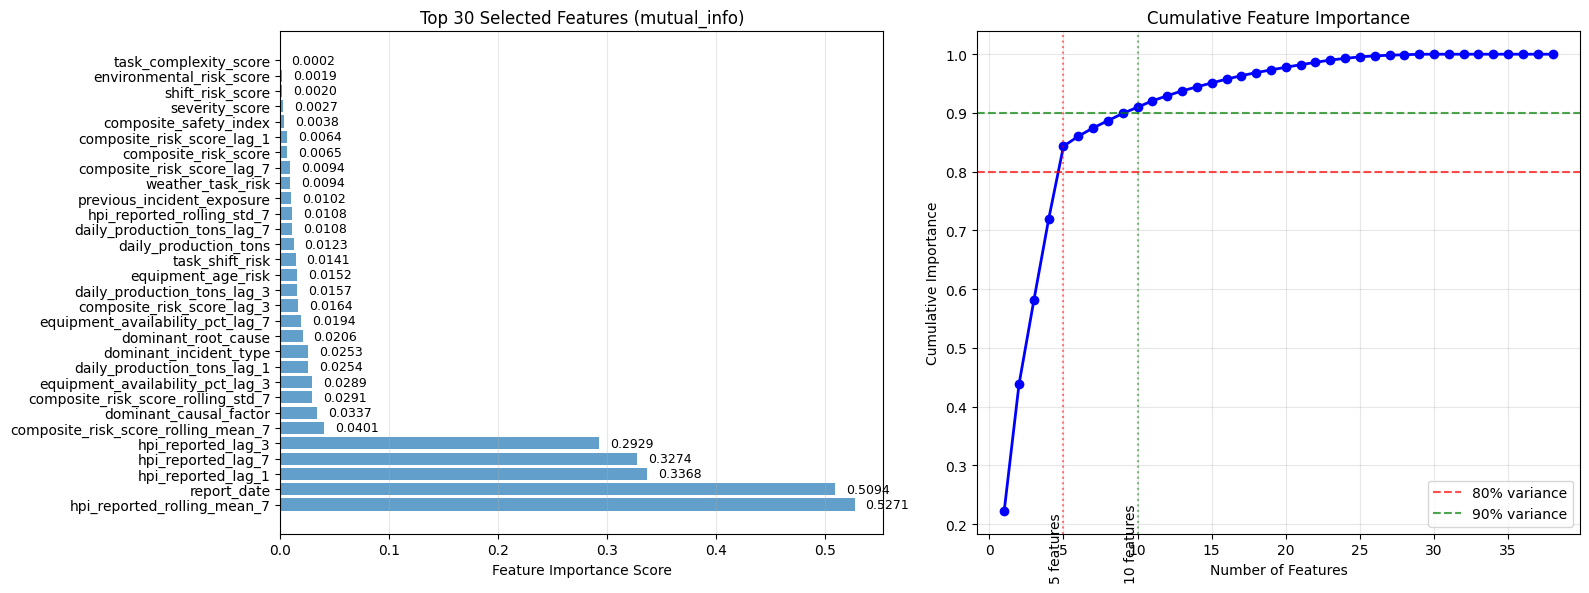

Selected 30 features: ['report_date', 'dominant_incident_type', 'dominant_causal_factor', 'dominant_root_cause', 'daily_production_tons', 'overtime_hours', 'environmental_risk_score', 'task_complexity_score', 'weather_risk_score', 'shift_risk_score']...

Creating sequences with 30 features...
Created 901 sequences
Sequence shape: (901, 7, 30)
Target shape: (901,)

Time Series Sequence Statistics:
  Total sequences: 901
  Sequence shape: (901, 7, 30)
  Target shape: (901,)
  Number of features: 30
  Time steps: 7

Class Balance:
  Class 0: 373 (41.4%)
  Class 1: 528 (58.6%)
  Balance ratio (1/0): 1.416

Data Split:
  Train: (612, 7, 30) (612 samples)
  Validation: (153, 7, 30) (153 samples)
  Test: (136, 7, 30) (136 samples)

PHASE 1: TRAINING INDIVIDUAL MODELS
TRAINING INDIVIDUAL MODELS

Training LSTM model...


2026-02-06 11:47:40.571221: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 7, 30)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 7, 128)    │     81,408 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 7, 128)    │        512 │ lstm[0][0]        │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 7, 128)    │          0 │ batch_normalizat… │
│ (Attention)         │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 7, 128)    │        256 │ attention[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dropout[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dropout_1[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │        528 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 16)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16)        │         64 │ dropout_2[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         17 │ batch_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 94,017 (367.25 KB)

...

  Step 2: Calculating log residuals...
  Step 3: Training RandomForest on residuals...

Training RandomForest model...
  ✗ Error training BiLSTM-RandomForest-Log: index 1 is out of bounds for axis 1 with size 1
    ✓ Trained BiLSTM-RandomForest-Log

  Training BiLSTM-RandomForest-Relative...

Training BiLSTM-RandomForest-Relative with relative residuals...
  Step 1: Training BiLSTM...

Training BiLSTM model...
Epoch 1/100


Traceback (most recent call last):
  File "/tmp/ipykernel_10195/2398519505.py", line 66, in train
    self.model2.train(X_train, residuals, X_val, y_val)
  File "/tmp/ipykernel_10195/589809997.py", line 617, in train
    self.predictions['train'] = self.model.predict_proba(X_train_flat)[:, 1]
                                ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^
IndexError: index 1 is out of bounds for axis 1 with size 1


20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.5408 - auc: 0.5835 - loss: 0.7888 - precision: 0.4344 - recall: 0.5816 - val_accuracy: 0.5752 - val_auc: 0.0000e+00 - val_loss: 0.6897 - val_precision: 1.0000 - val_recall: 0.5752 - learning_rate: 0.0010
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5735 - auc: 0.6251 - loss: 0.7227 - precision: 0.4618 - recall: 0.5565 - val_accuracy: 0.9935 - val_auc: 0.0000e+00 - val_loss: 0.6557 - val_precision: 1.0000 - val_recall: 0.9935 - learning_rate: 0.0010
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6601 - auc: 0.7105 - loss: 0.6315 - precision: 0.5556 - recall: 0.6485 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.6067 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6520 - auc: 0.7045 - loss: 0.6437 - precision: 0.5474 - recall: 0.6276 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.5534 -

  Step 2: Calculating relative residuals...
  Step 3: Training RandomForest on residuals...

Training RandomForest model...
  Step 4: Combining predictions...
  Optimal threshold found: inf

Evaluation for train dataset:
  MSE: 0.6110
  RMSE: 0.7817
  MAE: 0.6255
  R²: -1.5670
  Accuracy: 0.6095
  Precision: 0.0000
  Recall: 0.0000
  F1-Score: 0.0000
  AUC: 0.1309
  Threshold: inf
  Step 5: Generating validation predictions...

Evaluation for val dataset:
  MSE: 0.0006
  RMSE: 0.0245
  MAE: 0.0205
  R²: 0.0000
  ✓ Training completed for BiLSTM-RandomForest-Relative
  Optimal threshold found: inf

Evaluation for Train dataset:
  MSE: 0.6110
  RMSE: 0.7817
  MAE: 0.6255
  R²: -1.5670
  Accuracy: 0.6095
  Precision: 0.0000
  Recall: 0.0000
  F1-Score: 0.0000
  AUC: 0.1309
  Threshold: inf
    ✗ Error training BiLSTM-RandomForest-Relative: too many values to unpack (expected 3)

  Training BiLSTM-GradientBoosting-Absolute...

Training BiLSTM-GradientBoosting-Absolute with absolute residual

  Step 2: Calculating absolute residuals...
  Step 3: Training GradientBoosting on residuals...

Training GradientBoosting model...
  Step 4: Combining predictions...
  Optimal threshold found: 0.6475

Evaluation for train dataset:
  MSE: 0.0070
  RMSE: 0.0834
  MAE: 0.0404
  R²: 0.9708
  Accuracy: 0.9984
  Precision: 1.0000
  Recall: 0.9958
  F1-Score: 0.9979
  AUC: 1.0000
  Threshold: 0.6475
  Step 5: Generating validation predictions...

Evaluation for val dataset:
  MSE: 0.0004
  RMSE: 0.0191
  MAE: 0.0163
  R²: 0.0000
  ✓ Training completed for BiLSTM-GradientBoosting-Absolute
  Optimal threshold found: 0.6475

Evaluation for Train dataset:
  MSE: 0.0070
  RMSE: 0.0834
  MAE: 0.0404
  R²: 0.9708
  Accuracy: 0.9984
  Precision: 1.0000
  Recall: 0.9958
  F1-Score: 0.9979
  AUC: 1.0000
  Threshold: 0.6475
    ✗ Error training BiLSTM-GradientBoosting-Absolute: too many values to unpack (expected 3)

  Training BiLSTM-GradientBoosting-Squared...

Training BiLSTM-GradientBoosting-Square

In [ ]:
# Run the PhD-level enhanced pipeline
phd_results = main_pipeline_phd_enhanced(df, target_col='HPI_Reported')